# Pricing 0DTE put options and computing implied volatilities using neural networks



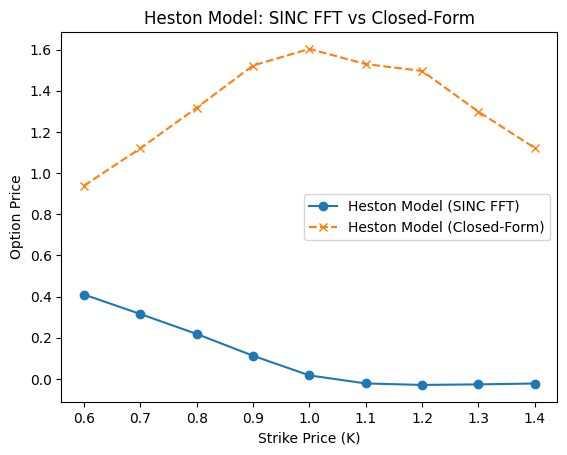

Strike Prices: [0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4]
SINC FFT Prices: [ 0.41016264  0.31545475  0.21860474  0.1127435   0.01730197 -0.02177361
 -0.02893055 -0.02630609 -0.02209005]
Closed-Form Prices: [0.9388181762439141, 1.1196911425311824, 1.3170696029696485, 1.5221833866523318, 1.602920968231894, 1.5293215769707993, 1.4958059997837827, 1.2976649475208275, 1.121665325409197]


In [30]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Characteristic function for the Heston closed-form model
def charfun_heston_closed(u, S, K, T, r, q, params, j):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]

    x = np.log(S)
    a = lambda_ * v_bar
    b = lambda_ + (1j * u * rho * eta if j == 1 else -1j * u * rho * eta)
    sigma = eta
    d = np.sqrt(b**2 - sigma**2 * (1j * u + u**2))
    g = (b - d) / (b + d)

    C = (r - q) * 1j * u * T + (a / sigma**2) * (
        (b - d) * T - 2 * np.log((1 - g * np.exp(-d * T)) / (1 - g))
    )
    D = ((b - d) / sigma**2) * (1 - np.exp(-d * T)) / (1 - g * np.exp(-d * T))
    phi = np.exp(C + D * v0 + 1j * u * x)
    
    return np.real(phi) if j == 1 else np.imag(phi)

# Integrand for the Heston formula
def heston_integrand(S, K, T, r, q, params, j):
    def integrand(u):
        phi = charfun_heston_closed(u - 1j, S, K, T, r, q, params, j)
        return np.real(np.exp(-1j * u * np.log(K)) * phi) / (u**2 + 1)
    return integrand

# Closed-form Heston model for option pricing
def heston_closed_form(S, K, T, r, q, params, CP):
    P1, _ = quad(lambda u: heston_integrand(S, K, T, r, q, params, 1)(u), 0, np.inf, epsabs=1e-10, epsrel=1e-10)
    P2, _ = quad(lambda u: heston_integrand(S, K, T, r, q, params, 2)(u), 0, np.inf, epsabs=1e-10, epsrel=1e-10)

    
    # Heston price components
    call = S * np.exp(-q * T) * P1 - K * np.exp(-r * T) * P2
    put = call - S * np.exp(-q * T) + K * np.exp(-r * T)
    
    return call if CP == 1 else put

# Heston model characteristic function
def charfun_heston(params, u, t):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]
    
    beta = lambda_ - rho * eta * 1j * u
    alpha = -0.5 * u**2 - 0.5 * 1j * u
    zeta = 0.5 * eta**2
    
    d = np.sqrt(beta**2 - 4 * alpha * zeta)
    
    rm = (beta - d) / eta**2
    rp = (beta + d) / eta**2
    
    g = rm / rp
    epsilon = 1e-10  # Prevent numerical instability
    C = rm * t - 2 / eta**2 * np.log((1 - g * np.exp(-d * t) + epsilon) / (1 - g + epsilon))
    D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t) + epsilon)
    
    phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    return np.real(phi)  # Use only the real part

# SINC operation function
def sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    N = 2 ** pow
    
    # Construct truncation range
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl
    
    # Fourier modes for CoN put
    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n
    
    # Compute characteristic function values
    f1l = np.real(np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn, t))
    f2l = np.real(np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn - 1j, t))
    
    # Zero-fill even frequencies
    q1l = np.zeros(N // 2)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N // 2)
    q2l[1::2] = f2l * Il
    
    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))
    f2u = np.flip(np.conj(f2l))
    
    # Zero-fill negative frequencies
    q1u = np.zeros(N // 2)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N // 2)
    q2u[::2] = f2u * Iu
    
    # Arrange for FFT algorithm
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])
    
    d1 = np.fft.fft(q1) + 0.5
    d2 = np.fft.fft(q2) + 0.5
    
    # Digital options computation
    d11 = d1[:N // 2]
    d12 = d1[N // 2:]
    d21 = d2[:N // 2]
    d22 = d2[N // 2:]
    
    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])
    
    m = np.arange(-N // 2, N // 2)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)
    
    # Price options
    conP = np.exp(-IR * t) * np.real(Km * dd1)
    aonP = np.exp(-DY * t) * np.real(S * dd2)
    
    # Interpolation
    conP_interp = interp1d(Km, conP, kind='linear', fill_value="extrapolate")
    aonP_interp = interp1d(Km, aonP, kind='linear', fill_value="extrapolate")
    
    conP = conP_interp(K)
    aonP = aonP_interp(K)
    
    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)
    
    return call if CP == 1 else put

def compare_heston_methods():
    CP = 1  # Call option
    S = 1
    T = 1.00
    K = S * np.arange(0.60, 1.41, 0.10)  # Strike prices
    r = 0.05  # Risk-free rate
    q = 0.02  # Dividend yield
    params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]  # Heston parameters

    # Select Xc based on time to maturity
    if T == 0.01:
        Xc = 1.3863
    elif T == 0.10:
        Xc = 2.0499
    elif T == 1.00:
        Xc = 12.1802
    elif T == 10:
        Xc = 32.8824
    Xm = 0
    
    pow = 18  # Precision for sinc method
    
    # Compute prices using SINC FFT
    sinc_prices = sinc_fast_ft(S, T, K, r, q, params, Xc, Xm, pow, CP)
    
    # Compute prices using closed-form Heston
    closed_prices = [heston_closed_form(S, k, T, r, q, params, CP) for k in K]
    
    # Plot results
    plt.plot(K, sinc_prices, label="Heston Model (SINC FFT)", marker='o')
    plt.plot(K, closed_prices, label="Heston Model (Closed-Form)", linestyle='--', marker='x')
    plt.xlabel("Strike Price (K)")
    plt.ylabel("Option Price")
    plt.title("Heston Model: SINC FFT vs Closed-Form")
    plt.legend()
    plt.show()
    
    # Print results for comparison
    print("Strike Prices:", K)
    print("SINC FFT Prices:", sinc_prices)
    print("Closed-Form Prices:", closed_prices)

# Compare the methods
compare_heston_methods()


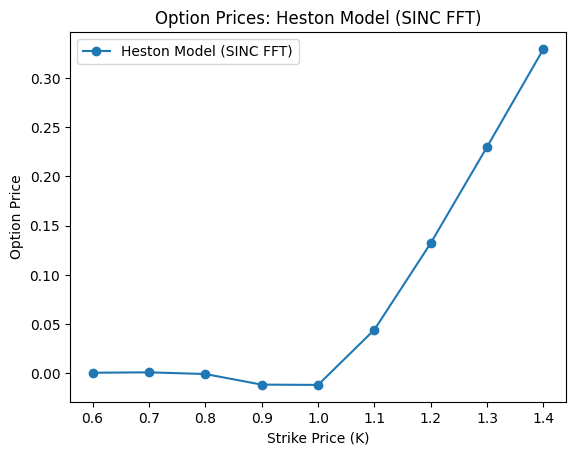

Strike Prices: [0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4]
Heston Model Prices: [ 0.00070163  0.00111667 -0.0006104  -0.01134869 -0.01166727  0.04438008
  0.13234608  0.23009349  0.32943248]


In [31]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Heston model characteristic function
def charfun_heston(params, u, t):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]
    
    beta = lambda_ - rho * eta * 1j * u
    alpha = -0.5 * u**2 - 0.5 * 1j * u
    zeta = 0.5 * eta**2
    
    d = np.sqrt(beta**2 - 4 * alpha * zeta)
    
    rm = (beta - d) / eta**2
    rp = (beta + d) / eta**2
    
    g = rm / rp
    epsilon = 1e-10  # Prevent numerical instability
    C = rm * t - 2 / eta**2 * np.log((1 - g * np.exp(-d * t) + epsilon) / (1 - g + epsilon))
    D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t) + epsilon)
    
    phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    return np.real(phi)  # Use only the real part

# SINC operation function
def sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    N = 2 ** pow
    
    # Construct truncation range
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl
    
    # Fourier modes for CoN put
    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n
    
    # Compute characteristic function values
    f1l = np.real(np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn, t))
    f2l = np.real(np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn - 1j, t))
    
    # Zero-fill even frequencies
    q1l = np.zeros(N // 2)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N // 2)
    q2l[1::2] = f2l * Il
    
    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))
    f2u = np.flip(np.conj(f2l))
    
    # Zero-fill negative frequencies
    q1u = np.zeros(N // 2)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N // 2)
    q2u[::2] = f2u * Iu
    
    # Arrange for FFT algorithm
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])
    
    d1 = np.fft.fft(q1) + 0.5
    d2 = np.fft.fft(q2) + 0.5
    
    # Digital options computation
    d11 = d1[:N // 2]
    d12 = d1[N // 2:]
    d21 = d2[:N // 2]
    d22 = d2[N // 2:]
    
    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])
    
    m = np.arange(-N // 2, N // 2)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)
    
    # Price options
    conP = np.exp(-IR * t) * np.real(Km * dd1)
    aonP = np.exp(-DY * t) * np.real(S * dd2)
    
    # Interpolation
    conP_interp = interp1d(Km, conP, kind='linear', fill_value="extrapolate")
    aonP_interp = interp1d(Km, aonP, kind='linear', fill_value="extrapolate")
    
    conP = conP_interp(K)
    aonP = aonP_interp(K)
    
    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)
    
    return call if CP == 1 else put

def main():
    CP = -1  # for Call options
    S = 1
    t = 1.00
    K = S * np.arange(0.60, 1.41, 0.10)  # Strike prices
    IR = 0.05  # Interest rate
    DY = 0.02  # Dividend yield
    params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]  # Heston parameters
    
    # Select Xc based on time to maturity
    if t == 0.01:
        Xc = 1.3863
    elif t == 0.10:
        Xc = 2.0499
    elif t == 1.00:
        Xc = 12.1802
    elif t == 10:
        Xc = 32.8824
    Xm = 0
    
    pow = 18  # FFT precision for sinc method
    heston_prices = sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP)
    
    # Plot results
    plt.plot(K, heston_prices, label="Heston Model (SINC FFT)", marker='o')
    plt.xlabel("Strike Price (K)")
    plt.ylabel("Option Price")
    plt.title("Option Prices: Heston Model (SINC FFT)")
    plt.legend()
    plt.show()
    
    # Print results for review
    print("Strike Prices:", K)
    print("Heston Model Prices:", heston_prices)

# Run the main function
main()


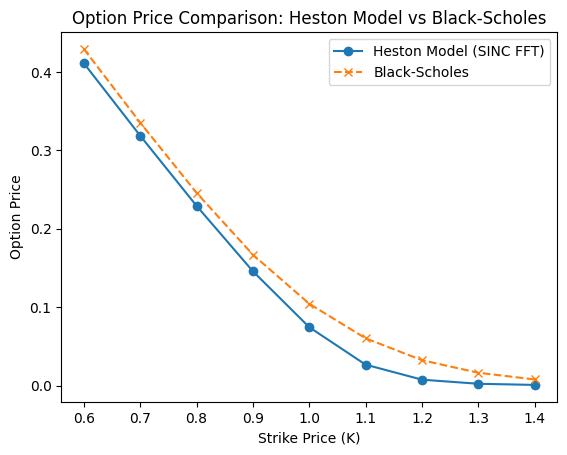

In [2]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.stats import norm
import matplotlib.pyplot as plt

# Heston model characteristic function
def charfun_heston(params, u, t):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]

    beta = lambda_ - rho * eta * 1j * u
    alpha = -0.5 * u**2 - 0.5 * 1j * u
    zeta = 0.5 * eta**2

    d = np.sqrt(beta**2 - 4 * alpha * zeta)
    
    rm = (beta - d) / eta**2
    rp = (beta + d) / eta**2
    
    g = rm / rp
    C = rm * t - 2 / eta**2 * np.log((1 - g * np.exp(-d * t)) / (1 - g))
    D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t))
    
    phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    return phi  # Use only the real part

# SINC operation function
def sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    N = 2 ** pow
    
    # Construct truncation range
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl
    
    # Fourier modes for CoN put
    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n
    
    # Compute characteristic function values
    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn, t)
    f2l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn - 1j, t)
    
    #print("charfun_heston wn:", charfun_heston(params, 2 * np.pi * wn, t))
    #print("charfun_heston wn-1:", charfun_heston(params, 2 * np.pi * wn - 1j, t))
    #print("Size: ", np.size(charfun_heston(params, 2 * np.pi * wn - 1j, t)))

    # Zero-fill even frequencies
    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N // 2, dtype=complex)
    q2l[1::2] = f2l * Il
    
    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))
    f2u = np.flip(np.conj(f2l))
    
    # Zero-fill negative frequencies
    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N // 2, dtype=complex)
    q2u[::2] = f2u * Iu
    
    # Arrange for FFT algorithm
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])
    
    d1 = np.fft.fft(q1) + 0.5
    d2 = np.fft.fft(q2) + 0.5
    
    # Digital options computation
    d11 = d1[:N // 2]
    d12 = d1[N // 2:]
    d21 = d2[:N // 2]
    d22 = d2[N // 2:]
    
    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])
    
    m = np.arange(-N // 2, N // 2)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)
    
    # Price options
    conP = np.exp(-IR * t) * np.real(Km * dd1)
    aonP = np.exp(-DY * t) * np.real(S * dd2)
    
    # Interpolation
    conP = np.interp(K, Km, conP)
    aonP = np.interp(K, Km, aonP)

    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)

    # Clamp negative prices
    return call if CP == 1 else put

# Black-Scholes formula
def black_scholes(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price


# Main function
def main():
    CP = 1  # for Call options
    S = 1
    t = 1.00
    K = S * np.arange(0.60, 1.41, 0.10)  # Strike prices
    IR = 0.05  # Interest rate
    DY = 0.02  # Dividend yield
    params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]  # Heston parameters
    
    # Select Xc based on time to maturity
    if t == 1.00:
        Xc = 12.1802  # Increased truncation range
    Xm = 0
    
    #pow = 20  # Increased FFT precision
    pow = 21  # Increase precision

    heston_prices = sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP)
    
    # Black-Scholes prices
    sigma_bs = np.sqrt(params[1])  # Approximate Black-Scholes volatility using v_bar
    bs_prices = [black_scholes(S, k, t, IR, sigma_bs, "call" if CP == 1 else "put") for k in K]
    
    # Plot results
    plt.plot(K, heston_prices, label="Heston Model (SINC FFT)", marker='o')
    plt.plot(K, bs_prices, label="Black-Scholes", linestyle='--', marker='x')
    plt.xlabel("Strike Price (K)")
    plt.ylabel("Option Price")
    plt.title("Option Price Comparison: Heston Model vs Black-Scholes")
    plt.legend()
    plt.show()


# Run the main function
main()


C:\Users\Dominik\AppData\Local\Temp\ipykernel_24416\2790830217.py:54: RuntimeWarning: divide by zero encountered in divide
  psit = (np.sin(k * np.pi * (d - a) / (b - a)) - np.sin(k * np.pi * (c - a) / (b - a))) * ((b - a) / (k * np.pi))
C:\Users\Dominik\AppData\Local\Temp\ipykernel_24416\2790830217.py:54: RuntimeWarning: invalid value encountered in multiply
  psit = (np.sin(k * np.pi * (d - a) / (b - a)) - np.sin(k * np.pi * (c - a) / (b - a))) * ((b - a) / (k * np.pi))


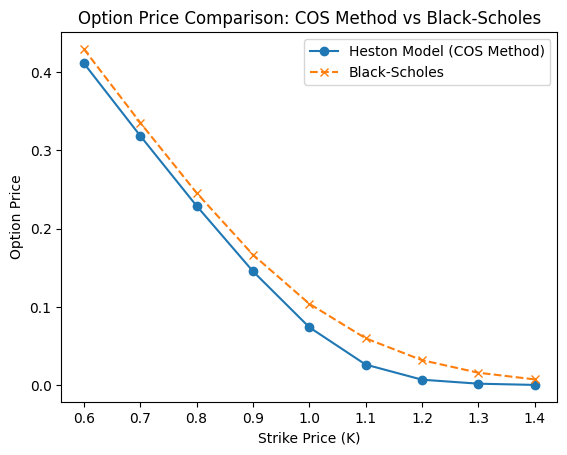

In [3]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.stats import norm
import matplotlib.pyplot as plt

# Heston model characteristic function
def charfun_heston(params, u, t):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]

    beta = lambda_ - rho * eta * 1j * u
    alpha = -0.5 * u**2 - 0.5 * 1j * u
    zeta = 0.5 * eta**2

    d = np.sqrt(beta**2 - 4 * alpha * zeta)
    
    rm = (beta - d) / eta**2
    rp = (beta + d) / eta**2
    
    g = rm / rp
    C = rm * t - 2 / eta**2 * np.log((1 - g * np.exp(-d * t)) / (1 - g))
    D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t))
    
    phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    return phi

# COS method
def COS_method(S, t, K, IR, DY, model, params, Xc, Xm, N, CP, type_):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    K1 = np.exp(-(IR - DY) * t) * K
    x = np.log(S / K1)

    a = -Xc + Xm
    b = Xc + Xm

    k = np.arange(0, N)
    c = a
    d = 0
    u = k * np.pi / (b - a)

    phi = charfun_heston(params, u, t)
    phi[0] = 1  # Ensure phi[0] = 1 to avoid division errors
    
    eto = np.exp(1j * np.pi * k[:, None] * (x - a) / (b - a))

    wgt = np.ones(N)
    wgt[0] = 0.5

    psih = d - c
    psit = (np.sin(k * np.pi * (d - a) / (b - a)) - np.sin(k * np.pi * (c - a) / (b - a))) * ((b - a) / (k * np.pi))
    psit[0] = psih  # Special case for k=0
    psi = psit

    Vk1 = 2 / (b - a) * K[:, None] * psi
    conP = np.real(np.sum(wgt * phi * eto.T * Vk1, axis=1)) * np.exp(-IR * t)

    add1 = np.cos(k * np.pi * (d - a) / (b - a)) * np.exp(d) - np.cos(k * np.pi * (c - a) / (b - a)) * np.exp(c)
    add2 = (k * np.pi / (b - a)) * (np.sin(k * np.pi * (d - a) / (b - a)) * np.exp(d) - np.sin(k * np.pi * (c - a) / (b - a)) * np.exp(c))
    fatt = 1 / (1 + (k * np.pi / (b - a))**2)
    chi = fatt * (add1 + add2)

    Vk2 = 2 / (b - a) * K1[:, None] * chi
    aonP = np.real(np.sum(wgt * phi * eto.T * Vk2, axis=1)) * np.exp(-DY * t)

    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)

    if CP * type_ == 1:
        return call
    elif CP * type_ == -1:
        return put
    else:
        raise ValueError("Invalid combination of CP and type.")

# Black-Scholes formula
def black_scholes(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price

# Main function
def main():
    CP = 1  # for Call options
    S = 1
    t = 1.00
    K = S * np.arange(0.60, 1.41, 0.10)  # Strike prices
    IR = 0.05  # Interest rate
    DY = 0.02  # Dividend yield
    params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]  # Heston parameters
    
    Xc = 12.1802 if t == 1.00 else 8.0
    Xm = 0
    N = 256  # Number of terms in COS expansion

    # COS method prices
    cos_prices = COS_method(S, t, K, IR, DY, "heston", params, Xc, Xm, N, CP, 1)

    # Black-Scholes prices
    sigma_bs = np.sqrt(params[1])  # Approximate Black-Scholes volatility using v_bar
    bs_prices = [black_scholes(S, k, t, IR, sigma_bs, "call" if CP == 1 else "put") for k in K]
    
    # Plot results
    plt.plot(K, cos_prices, label="Heston Model (COS Method)", marker='o')
    plt.plot(K, bs_prices, label="Black-Scholes", linestyle='--', marker='x')
    plt.xlabel("Strike Price (K)")
    plt.ylabel("Option Price")
    plt.title("Option Price Comparison: COS Method vs Black-Scholes")
    plt.legend()
    plt.show()

# Run the main function
main()


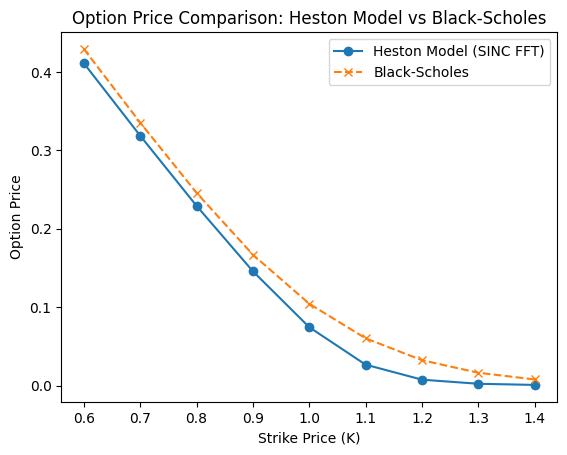

Strike Prices: [0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4]
Heston Model Prices: [0.41117065 0.31868418 0.22921543 0.14572578 0.07437211 0.02660511
 0.00746054 0.00224227 0.00076902]
Black-Scholes Prices: [0.4293723589126138, 0.3353805718734575, 0.24582029164024177, 0.16685860219932291, 0.10431799281677256, 0.060202763367546375, 0.032304282979526755, 0.016270345767953442, 0.007767649031033136]
Characteristic Function Values: [(1+0j), (0.9951399901744394-0.0076027416976874795j), (0.9810583868741682-0.013295261754332148j), (0.959084958654594-0.01564207783764249j), (0.930985375641009-0.01393909356995871j), (0.8985474054173772-0.008191699007254999j), (0.86330609679207+0.0010885973757392144j), (0.8264403882231963+0.013129168229394734j), (0.7887901239470131+0.02709212657654044j), (0.7509268090775948+0.042194855864274176j)]


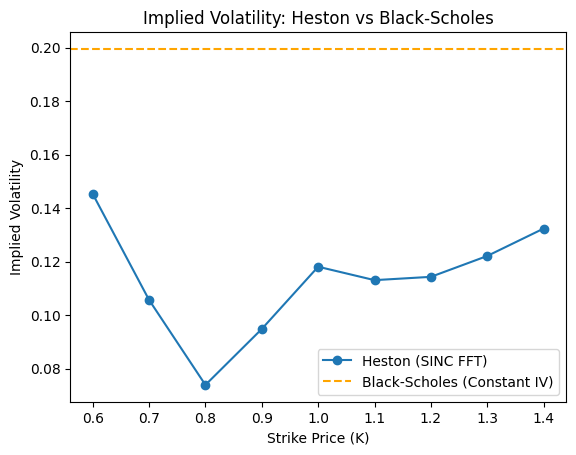

In [1]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.stats import norm
import matplotlib.pyplot as plt

# Heston model characteristic function
def charfun_heston(params, u, t):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]

    beta = lambda_ - rho * eta * 1j * u
    alpha = -0.5 * u**2 - 0.5 * 1j * u
    zeta = 0.5 * eta**2

    d = np.sqrt(beta**2 - 4 * alpha * zeta)
    
    rm = (beta - d) / eta**2
    rp = (beta + d) / eta**2
    
    g = rm / rp
    C = rm * t - 2 / eta**2 * np.log((1 - g * np.exp(-d * t)) / (1 - g))
    D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t))
    
    phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    return phi  # Use only the real part

# SINC operation function
def sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    N = 2 ** pow
    
    # Construct truncation range
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl
    
    # Fourier modes for CoN put
    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n
    
    # Compute characteristic function values
    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn, t)
    f2l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn - 1j, t)
    
    #print("charfun_heston wn:", charfun_heston(params, 2 * np.pi * wn, t))
    #print("charfun_heston wn-1:", charfun_heston(params, 2 * np.pi * wn - 1j, t))
    #print("Size: ", np.size(charfun_heston(params, 2 * np.pi * wn - 1j, t)))

    # Zero-fill even frequencies
    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N // 2, dtype=complex)
    q2l[1::2] = f2l * Il
    
    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))
    f2u = np.flip(np.conj(f2l))
    
    # Zero-fill negative frequencies
    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N // 2, dtype=complex)
    q2u[::2] = f2u * Iu
    
    # Arrange for FFT algorithm
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])
    
    d1 = np.fft.fft(q1) + 0.5
    d2 = np.fft.fft(q2) + 0.5
    
    # Digital options computation
    d11 = d1[:N // 2]
    d12 = d1[N // 2:]
    d21 = d2[:N // 2]
    d22 = d2[N // 2:]
    
    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])
    
    m = np.arange(-N // 2, N // 2)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)
    
    # Price options
    conP = np.exp(-IR * t) * np.real(Km * dd1)
    aonP = np.exp(-DY * t) * np.real(S * dd2)
    
    # Interpolation
    conP = np.interp(K, Km, conP)
    aonP = np.interp(K, Km, aonP)

    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)

    # Clamp negative prices
    return call if CP == 1 else put

# Black-Scholes formula
def black_scholes(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price

from scipy.optimize import minimize

# Function to calculate implied volatility
def implied_vol(price, S, K, T, r, option_type="call"):
    def objective(sigma):
        return (black_scholes(S, K, T, r, sigma, option_type) - price)**2
        
    result = minimize(objective, 0.2, bounds=[(1e-5, 3.0)])  # Initial guess and bounds
    return result.x[0] if result.success else np.nan

# Main function
def main():
    CP = 1  # for Call options
    S = 1
    t = 1.00
    K = S * np.arange(0.60, 1.41, 0.10)  # Strike prices
    IR = 0.05  # Interest rate
    DY = 0.02  # Dividend yield
    params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]  # Heston parameters
    
    # Select Xc based on time to maturity
    if t == 1.00:
        Xc = 12.1802  # Increased truncation range
    Xm = 0
    
    #pow = 20  # Increased FFT precision
    pow = 21  # Increase precision

    heston_prices = sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP)
    
    # Black-Scholes prices
    sigma_bs = np.sqrt(params[1])  # Approximate Black-Scholes volatility using v_bar
    bs_prices = [black_scholes(S, k, t, IR, sigma_bs, "call" if CP == 1 else "put") for k in K]
    
    # Plot results
    plt.plot(K, heston_prices, label="Heston Model (SINC FFT)", marker='o')
    plt.plot(K, bs_prices, label="Black-Scholes", linestyle='--', marker='x')
    plt.xlabel("Strike Price (K)")
    plt.ylabel("Option Price")
    plt.title("Option Price Comparison: Heston Model vs Black-Scholes")
    plt.legend()
    plt.show()
    
    # Print results for review
    print("Strike Prices:", K)
    print("Heston Model Prices:", heston_prices)
    print("Black-Scholes Prices:", bs_prices)

    # Test characteristic function
    u_test = np.linspace(0, 5, 10)
    phi_values = [charfun_heston(params, u, t) for u in u_test]
    print("Characteristic Function Values:", phi_values)


    

    # Calculate implied volatilities
    heston_ivs = [implied_vol(p, S, k, t, IR, "call") for p, k in zip(heston_prices, K)]
    bs_iv = sigma_bs  # Black-Scholes implied volatility is constant

    # Plot implied volatility
    plt.plot(K, heston_ivs, label="Heston (SINC FFT)", marker='o')
    plt.axhline(bs_iv, color="orange", linestyle="--", label="Black-Scholes (Constant IV)")
    plt.xlabel("Strike Price (K)")
    plt.ylabel("Implied Volatility")
    plt.title("Implied Volatility: Heston vs Black-Scholes")
    plt.legend()
    plt.show()


# Run the main function
main()


In [55]:
# Heston parameters
params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]  # [lambda, v_bar, eta, v0, rho]
u = 1.0  # Fourier frequency
t = 1.0  # Maturity

# Calculate the characteristic function for one frequency
phi = charfun_heston(params, u, t)
print("Characteristic Function Output:", phi)


Characteristic Function Output: (0.9845577378003488-0.012388253910435472j)


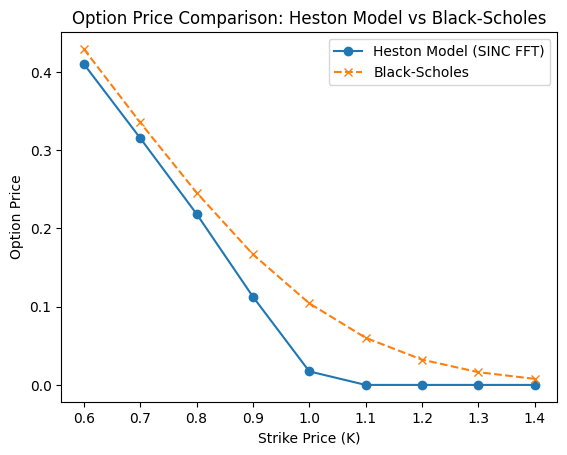

Strike Prices: [0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4]
Heston Model Prices: [0.41016264 0.31545475 0.21860474 0.1127435  0.01730197 0.
 0.         0.         0.        ]
Black-Scholes Prices: [0.4293723589126138, 0.3353805718734575, 0.24582029164024177, 0.16685860219932291, 0.10431799281677256, 0.060202763367546375, 0.032304282979526755, 0.016270345767953442, 0.007767649031033136]


In [32]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.stats import norm
import matplotlib.pyplot as plt

# Heston model characteristic function
def charfun_heston(params, u, t):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]
    
    beta = lambda_ - rho * eta * 1j * u
    alpha = -0.5 * u**2 - 0.5 * 1j * u
    zeta = 0.5 * eta**2
    
    d = np.sqrt(beta**2 - 4 * alpha * zeta)
    
    rm = (beta - d) / eta**2
    rp = (beta + d) / eta**2
    
    g = rm / rp
    epsilon = 1e-10  # Prevent numerical instability
    C = rm * t - 2 / eta**2 * np.log((1 - g * np.exp(-d * t) + epsilon) / (1 - g + epsilon))
    
    D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t) + epsilon)
    
    phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    return np.real(phi)  # Use only the real part

# SINC operation function
def sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    N = 2 ** pow
    
    # Construct truncation range
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl
    
    # Fourier modes for CoN put
    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n
    
    # Compute characteristic function values
    f1l = np.real(np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn, t))
    f2l = np.real(np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn - 1j, t))
    
    # Zero-fill even frequencies
    q1l = np.zeros(N // 2)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N // 2)
    q2l[1::2] = f2l * Il
    
    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))
    f2u = np.flip(np.conj(f2l))
    
    # Zero-fill negative frequencies
    q1u = np.zeros(N // 2)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N // 2)
    q2u[::2] = f2u * Iu
    
    # Arrange for FFT algorithm
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])
    
    d1 = np.fft.fft(q1) + 0.5
    d2 = np.fft.fft(q2) + 0.5
    
    # Digital options computation
    d11 = d1[:N // 2]
    d12 = d1[N // 2:]
    d21 = d2[:N // 2]
    d22 = d2[N // 2:]
    
    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])
    
    m = np.arange(-N // 2, N // 2)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)
    
    # Price options
    conP = np.exp(-IR * t) * np.real(Km * dd1)
    aonP = np.exp(-DY * t) * np.real(S * dd2)
    
    # Interpolation
    conP_interp = interp1d(Km, conP, kind='linear', fill_value="extrapolate")
    aonP_interp = interp1d(Km, aonP, kind='linear', fill_value="extrapolate")
    
    conP = conP_interp(K)
    aonP = aonP_interp(K)
    
    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)
    
    return call if CP == 1 else put

def black_scholes(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price

def main():
    CP = 1  # for Call options
    S = 1
    t = 1.00
    K = S * np.arange(0.60, 1.41, 0.10)  # Strike prices
    IR = 0.05  # Interest rate
    DY = 0.02  # Dividend yield
    params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]  # Heston parameters
    
    # Select Xc based on time to maturity
    if t == 0.01:
        Xc = 1.3863
    elif t == 0.10:
        Xc = 2.0499
    elif t == 1.00:
        Xc = 12.1802
    elif t == 10:
        Xc = 32.8824
    Xm = 0
    
    pow = 18  # FFT precision for sinc method
    heston_prices = sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP)
    
    # Black-Scholes prices
    sigma_bs = np.sqrt(params[1])  # Approximate Black-Scholes volatility using v_bar
    bs_prices = [black_scholes(S, k, t, IR, sigma_bs, "call" if CP == 1 else "put") for k in K]
    
    # Plot results
    plt.plot(K, heston_prices, label="Heston Model (SINC FFT)", marker='o')
    plt.plot(K, bs_prices, label="Black-Scholes", linestyle='--', marker='x')
    plt.xlabel("Strike Price (K)")
    plt.ylabel("Option Price")
    plt.title("Option Price Comparison: Heston Model vs Black-Scholes")
    plt.legend()
    plt.show()
    
    # Print results for review
    print("Strike Prices:", K)
    print("Heston Model Prices:", heston_prices)
    print("Black-Scholes Prices:", bs_prices)

# Run the main function
main()


C:\Users\Dominik\AppData\Local\Temp\ipykernel_17840\1216293370.py:53: ComplexWarning: Casting complex values to real discards the imaginary part
  q1l[1::2] = f1l * Il
C:\Users\Dominik\AppData\Local\Temp\ipykernel_17840\1216293370.py:55: ComplexWarning: Casting complex values to real discards the imaginary part
  q2l[1::2] = f2l * Il
C:\Users\Dominik\AppData\Local\Temp\ipykernel_17840\1216293370.py:63: ComplexWarning: Casting complex values to real discards the imaginary part
  q1u[::2] = f1u * Iu
C:\Users\Dominik\AppData\Local\Temp\ipykernel_17840\1216293370.py:65: ComplexWarning: Casting complex values to real discards the imaginary part
  q2u[::2] = f2u * Iu


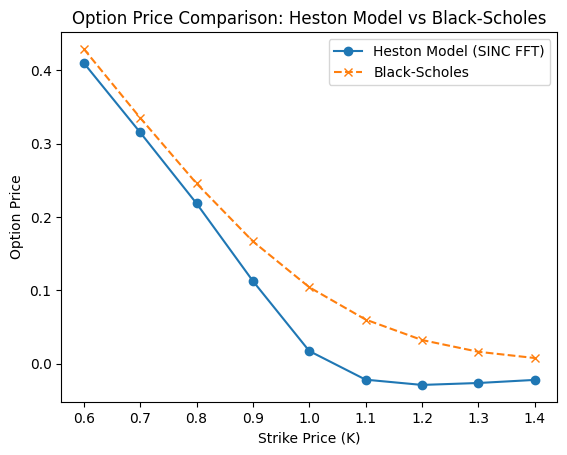

Strike Prices: [0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4]
Heston Model Prices: [ 0.41016264  0.31545475  0.21860474  0.1127435   0.01730197 -0.02177361
 -0.02893055 -0.02630609 -0.02209005]
Black-Scholes Prices: [0.4293723589126138, 0.3353805718734575, 0.24582029164024177, 0.16685860219932291, 0.10431799281677256, 0.060202763367546375, 0.032304282979526755, 0.016270345767953442, 0.007767649031033136]


In [26]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.stats import norm
import matplotlib.pyplot as plt

# Heston model characteristic function
def charfun_heston(params, u, t):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]
    
    beta = lambda_ - rho * eta * 1j * u
    alpha = -0.5 * u**2 - 0.5 * 1j * u
    zeta = 0.5 * eta**2
    
    d = np.sqrt(beta**2 - 4 * alpha * zeta)
    
    rm = (beta - d) / eta**2
    rp = (beta + d) / eta**2
    
    g = rm / rp
    epsilon = 1e-10  # Prevent numerical instability
    C = rm * t - 2 / eta**2 * np.log((1 - g * np.exp(-d * t) + epsilon) / (1 - g + epsilon))
    D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t) + epsilon)
    
    phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    return phi

# SINC operation function
def sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    N = 2 ** pow
    
    # Construct truncation range
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl
    
    # Fourier modes for CoN put
    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n
    
    # Compute characteristic function values
    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn, t)
    f2l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn - 1j, t)
    
    # Zero-fill even frequencies
    q1l = np.zeros(N // 2)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N // 2)
    q2l[1::2] = f2l * Il
    
    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))
    f2u = np.flip(np.conj(f2l))
    
    # Zero-fill negative frequencies
    q1u = np.zeros(N // 2)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N // 2)
    q2u[::2] = f2u * Iu
    
    # Arrange for FFT algorithm
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])
    
    d1 = np.fft.fft(q1) + 0.5
    d2 = np.fft.fft(q2) + 0.5
    
    # Digital options computation
    d11 = d1[:N // 2]
    d12 = d1[N // 2:]
    d21 = d2[:N // 2]
    d22 = d2[N // 2:]
    
    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])
    
    m = np.arange(-N // 2, N // 2)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)
    
    # Price options
    conP = np.exp(-IR * t) * np.real(Km * dd1)
    aonP = np.exp(-DY * t) * np.real(S * dd2)
    
    # Interpolation
    conP_interp = interp1d(Km, conP, kind='linear', fill_value="extrapolate")
    aonP_interp = interp1d(Km, aonP, kind='linear', fill_value="extrapolate")
    
    conP = conP_interp(K)
    aonP = aonP_interp(K)
    
    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)
    
    return call if CP == 1 else put

def black_scholes(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price

def main():
    CP = 1  # for Call options
    S = 1
    t = 1.00
    K = S * np.arange(0.60, 1.41, 0.10)  # Strike prices
    IR = 0.05  # Interest rate
    DY = 0.02  # Dividend yield
    params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]  # Heston parameters
    
    # Select Xc based on time to maturity
    if t == 0.01:
        Xc = 1.3863
    elif t == 0.10:
        Xc = 2.0499
    elif t == 1.00:
        Xc = 12.1802
    elif t == 10:
        Xc = 32.8824
    Xm = 0
    
    pow = 18  # FFT precision for sinc method
    heston_prices = sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP)
    
    # Black-Scholes prices
    sigma_bs = np.sqrt(params[1])  # Approximate Black-Scholes volatility using v_bar
    bs_prices = [black_scholes(S, k, t, IR, sigma_bs, "call" if CP == 1 else "put") for k in K]
    
    # Plot results
    plt.plot(K, heston_prices, label="Heston Model (SINC FFT)", marker='o')
    plt.plot(K, bs_prices, label="Black-Scholes", linestyle='--', marker='x')
    plt.xlabel("Strike Price (K)")
    plt.ylabel("Option Price")
    plt.title("Option Price Comparison: Heston Model vs Black-Scholes")
    plt.legend()
    plt.show()
    
    # Print results for review
    print("Strike Prices:", K)
    print("Heston Model Prices:", heston_prices)
    print("Black-Scholes Prices:", bs_prices)

# Run the main function
main()


In [4]:
import numpy as np

def sinc_disc_ft(S, t, K, IR, DY, model, params, xi, j, Xc, Xm, N, CP, option_type, charfun):
    """
    Compute prices using SINC method for plain vanilla, CoN, and AoN options.
    """
    K = np.asarray(K) if K.ndim > 0 else np.asarray([K])  # Ensure K is array-like
    
    # Truncation range
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl  # 2 * Xc

    # Sampled Fourier modes
    n = np.arange(1, N // 2, 2)
    wn = n / wid

    # Log-strike (including shift Xm)
    k = np.log(K / S) - (IR - DY) * t - Xm

    # Compute sin and cos components
    sn = np.sin(2 * np.pi * np.outer(k, wn))
    cs = np.cos(2 * np.pi * np.outer(k, wn))

    # Characteristic function evaluations
    f1 = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun(model, params, xi, j, 2 * np.pi * wn, t)
    f2 = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun(model, params, xi, j, 2 * np.pi * wn - 1j, t)

    # Compute sums
    ad1 = np.sum((sn * np.real(f1) - cs * np.imag(f1)) / n, axis=1)
    ad2 = np.sum((sn * np.real(f2) - cs * np.imag(f2)) / n, axis=1)

    # Prices for CoN and AoN
    conP = K * np.exp(-IR * t) * (0.5 + (2 / np.pi) * ad1)
    aonP = S * np.exp(-DY * t) * (0.5 + (2 / np.pi) * ad2)

    # Plain vanilla put and call prices
    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)

    # Digital options (CoN, AoN call prices)
    conC = K * np.exp(-IR * t) - conP
    aonC = S * np.exp(-DY * t) - aonP

    if CP * option_type == 1:
        return call
    elif CP * option_type == -1:
        return put
    elif CP * option_type == 2:
        return conC
    elif CP * option_type == -2:
        return conP
    elif CP * option_type == 3:
        return aonC
    elif CP * option_type == -3:
        return aonP


In [15]:
def cos_m_disc_ft(S, t, K, IR, DY, model, params, xi, j, Xc, Xm, N, CP, option_type, charfun):
    K = np.asarray(K) if np.ndim(K) > 0 else np.array([K])
    K1 = np.exp(-(IR - DY) * t) * K
    x = np.log(S / K1)

    # Bounds
    a = -Xc + Xm
    b = Xc + Xm

    # Fourier coefficients
    k = np.arange(N)
    u = k * np.pi / (b - a)

    # Characteristic function
    phi = charfun(model, params, xi, j, u, t)
    phi[0] = 1  # Special case for u=0

    # COS expansion
    eto = np.exp(1j * np.pi * np.outer(x - a, k) / (b - a))
    wgt = np.ones(N)
    wgt[0] = 0.5

    # Handle `psit` for k=0
    psit = np.zeros_like(k, dtype=np.float64)
    non_zero_k = k != 0
    psit[non_zero_k] = (np.sin(k[non_zero_k] * np.pi * (b - a) / (b - a)) -
                        np.sin(k[non_zero_k] * np.pi * (a - a) / (b - a))) / (k[non_zero_k] * np.pi)
    psit[0] = b - a

    Vk1 = 2 / (b - a) * K1[:, None] * psit
    conP = np.real(np.dot(eto, (wgt * phi).T) * Vk1).sum(axis=1) * np.exp(-IR * t)

    # AoN calculations
    add1 = np.cos(k * np.pi * (b - a) / (b - a)) * np.exp(b) - np.cos(k * np.pi * (a - a) / (b - a)) * np.exp(a)
    add2 = (k * np.pi / (b - a)) * (
        np.sin(k * np.pi * (b - a) / (b - a)) * np.exp(b) - np.sin(k * np.pi * (a - a) / (b - a)) * np.exp(a)
    )
    fatt = 1 / (1 + (k * np.pi / (b - a)) ** 2)
    chi = fatt * (add1 + add2)

    Vk2 = 2 / (b - a) * K1[:, None] * chi
    aonP = np.real(np.dot(eto, (wgt * phi).T) * Vk2).sum(axis=1) * np.exp(-DY * t)

    # Put, call, and digital prices
    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)
    conC = K * np.exp(-IR * t) - conP
    aonC = S * np.exp(-DY * t) - aonP

    if CP * option_type == 1:
        return call
    elif CP * option_type == -1:
        return put
    elif CP * option_type == 2:
        return conC
    elif CP * option_type == -2:
        return conP
    elif CP * option_type == 3:
        return aonC
    elif CP * option_type == -3:
        return aonP


In [6]:
def charfun(model, params, xi, n, u, t):
    """
    Compute the characteristic function (CF) for the specified model.
    
    Parameters:
        model: str
            The name of the model ('GBM', 'Heston', 'VG').
        params: list or np.ndarray
            Model-specific parameters.
        xi, n: placeholders (unused in this implementation).
        u: np.ndarray
            Fourier domain variables.
        t: float
            Time to maturity.
    
    Returns:
        phi: np.ndarray
            Characteristic function evaluated at u.
    """
    if model == 'GBM':
        sigma = params[0]
        phi = np.exp(-0.5 * 1j * u * t * sigma**2 - 0.5 * t * (u * sigma)**2)
    
    elif model == 'Heston':
        lambda_, v_bar, eta, v0, rho = params

        beta = lambda_ - rho * eta * 1j * u
        alpha = -0.5 * u**2 - 0.5 * 1j * u
        zeta = 0.5 * eta**2

        d = np.sqrt(beta**2 - 4 * alpha * zeta)

        rm = (beta - d) / eta**2
        rp = (beta + d) / eta**2

        g = rm / rp

        C = rm * t - (2 / eta**2) * np.log((1 - g * np.exp(-d * t)) / (1 - g))
        D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t))

        phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    elif model == 'VG':
        sigma, theta, nu = params

        fac1 = np.exp((1j * u * t) / nu * np.log(1 - nu * theta - 0.5 * (nu * sigma**2)))
        fac2 = (1. / (1 + 2 * nu * (0.5 * u * sigma)**2 - 1j * u * nu * theta))**(t / nu)

        phi = fac1 * fac2

    else:
        raise ValueError(f"Model '{model}' not recognized.")
    
    return phi


In [20]:
def main():
    # Model parameters
    model = "Heston"
    CP = -1  # Put option
    option_type = 1  # Plain vanilla options

    S = 1  # Spot price
    t = 1.00  # Maturity (change to 0.10, 0.01 for other tables)
    K = S * np.arange(0.60, 1.41, 0.10)  # Strikes from 0.60 to 1.40

    IR = 0  # Interest rate
    DY = 0  # Dividend yield

    # Heston model parameters
    lambda_ = 1.5768
    v_bar = 0.0398
    eta = 0.5751
    v0 = 0.0175
    rho = -0.5711
    params = [lambda_, v_bar, eta, v0, rho]

    # Truncation bounds for Fourier space
    if t == 0.01:
        Xc = 1.3863
    elif t == 0.10:
        Xc = 2.0499
    elif t == 1.00:
        Xc = 12.1802
    elif t == 10:
        Xc = 32.8824
    Xm = 0

    # Fourier grid sizes
    if t == 0.10:
        N_vec = [64, 128, 192, 256, 384, 512]
    elif t == 1:
        N_vec = [128, 192, 256, 384, 512, 768]
    
    Q = len(K)  # Number of strikes
    m = len(N_vec)  # Number of grid sizes

    # Initialize storage for results
    convtab = np.zeros((2 * Q, m))

    # Compute prices for each strike and Fourier mode
    for q in range(Q):
        for i, N in enumerate(N_vec):
            if option_type == 1:
                NS = 2 * N
            elif option_type in [2, 3]:
                NS = 4 * N

            # SINC method
            convtab[2 * q, i] = sinc_disc_ft(
                S, t, K[q], IR, DY, model, params, None, None, Xc, Xm, NS, CP, option_type, charfun
            ).item()
            # COS method
            convtab[2 * q + 1, i] = cos_m_disc_ft(
                S, t, K[q], IR, DY, model, params, None, None, Xc, Xm, N, CP, option_type, charfun
            ).item()

    # Compute high-precision benchmarks (N = 2^18)
    NC = 2**18
    if option_type == 1:
        NS = 2 * NC
    elif option_type in [2, 3]:
        NS = 4 * NC

    benchmarkS = sinc_disc_ft(S, t, K, IR, DY, model, params, None, None, Xc, Xm, NS, CP, option_type, charfun)
    benchmarkC = 0 #cos_m_disc_ft(S, t, K, IR, DY, model, params, None, None, Xc, Xm, NC, CP, option_type, charfun)

    # Determine the final benchmark as the fixed precision of benchmarkS
    diff_SINCvsCOS = np.abs(benchmarkS - benchmarkC)
    d = np.max(diff_SINCvsCOS)
    o = max(int(np.floor(np.log10(d))) + 1, -10)

    benchmark = np.round(benchmarkS * 10**(-o)) * 10**o  # Shape (9,)

    # Correctly repeat and tile benchmark to match convtab
    benchmark_repeated = np.repeat(benchmark, 2)  # Shape becomes (18,)
    benchtab = np.tile(benchmark_repeated[:, None], (1, m))  # Shape becomes (18, 6)

    # Compute relative errors
    abstab = np.abs(benchtab - convtab)
    reltab = abstab / benchtab

    # Adjust relative errors for presentation
    for a in range(2 * Q):
        for b in range(m):
            if np.isclose(convtab[a, b], benchtab[a, b]):
                reltab[a, b] = 0
            elif reltab[a, b] >= 1:
                reltab[a, b] = 1





    # Print or return results
    print("Relative Errors (SINC and COS methods):")
    print(reltab)
    print(f"benchmark shape: {benchmark.shape}")
    print(f"benchtab shape: {benchtab.shape}")
    print(f"convtab shape: {convtab.shape}")

main()

Relative Errors (SINC and COS methods):
[[1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]]
benchmark shape: (9,)
benchtab shape: (18, 6)
convtab shape: (18, 6)


C:\Users\Dominik\AppData\Local\Temp\ipykernel_17840\1099854336.py:85: RuntimeWarning: divide by zero encountered in divide
  reltab = abstab / benchtab


In [11]:
import numpy as np
from scipy.stats import norm

# Heston model characteristic function (from previous code)
def charfun_heston(params, u, t):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]
    
    beta = lambda_ - rho * eta * 1j * u
    alpha = -0.5 * u**2 - 0.5 * 1j * u
    zeta = 0.5 * eta**2
    
    d = np.sqrt(beta**2 - 4 * alpha * zeta)
    
    rm = (beta - d) / eta**2
    rp = (beta + d) / eta**2
    
    g = rm / rp
    
    C = rm * t - 2 / eta**2 * np.log((1 - g * np.exp(-d * t)) / (1 - g))
    D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t))
    
    phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    return phi

# SINC method for option pricing
def sinc_method(S, t, K, IR, DY, params, Xc, Xm, N, CP):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    N_half = N // 2
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl
    
    n = np.arange(1, N_half, 2)
    wn = n / wid
    Il = 2 / n

    # Characteristic function evaluations
    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn, t)
    f2l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn - 1j, t)

    q1l = np.zeros(N_half, dtype=complex)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N_half, dtype=complex)
    q2l[1::2] = f2l * Il
    
    Iu = -Il[::-1]
    f1u = f1l[::-1].conj()
    f2u = f2l[::-1].conj()
    
    q1u = np.zeros(N_half, dtype=complex)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N_half, dtype=complex)
    q2u[::2] = f2u * Iu
    
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])

    d1 = np.fft.fft(q1) + 0.5
    d2 = np.fft.fft(q2) + 0.5
    
    d11, d12 = d1[:N_half], d1[N_half:]
    d21, d22 = d2[:N_half], d2[N_half:]

    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])
    
    m = np.arange(-N_half, N_half)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)
    
    conP = np.exp(-IR * t) * np.real(Km * dd1)
    aonP = np.exp(-DY * t) * np.real(S * dd2)
    
    conP = np.interp(K, Km, conP)
    aonP = np.interp(K, Km, aonP)
    
    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)
    
    return call if CP == 1 else put

# Black-Scholes price for comparison
def black_scholes_price(S, K, t, IR, DY, sigma, CP):
    d1 = (np.log(S / K) + (IR - DY + 0.5 * sigma**2) * t) / (sigma * np.sqrt(t))
    d2 = d1 - sigma * np.sqrt(t)
    
    if CP == 1:  # Call option
        return S * np.exp(-DY * t) * norm.cdf(d1) - K * np.exp(-IR * t) * norm.cdf(d2)
    elif CP == -1:  # Put option
        return K * np.exp(-IR * t) * norm.cdf(-d2) - S * np.exp(-DY * t) * norm.cdf(-d1)

# Main function for testing specific strikes with SINC and COS methods
def main():
    S = 1
    t = 1.00
    IR = 0
    DY = 0
    CP = -1  # Put option
    params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]
    
    # Use specific strikes for testing
    K = S * np.array([0.60, 1.00, 1.40])

    if t == 0.01:
        Xc = 1.3863
    elif t == 0.10:
        Xc = 2.0499
    elif t == 1.00:
        Xc = 12.1802
    elif t == 10:
        Xc = 32.8824
    Xm = 0

    N_cos = 256  # Number of terms for COS method
    N_sinc = 256  # Number of terms for SINC method

    # Compute prices using COS and SINC methods
    prices_cos = cos_method(S, t, K, IR, DY, params, Xc, Xm, N_cos, CP, type_=1)
    prices_sinc = sinc_method(S, t, K, IR, DY, params, Xc, Xm, N_sinc, CP)

    # Optional: Black-Scholes comparison (assuming constant volatility, here we use sqrt(v_bar) as a proxy)
    bs_prices = [black_scholes_price(S, strike, t, IR, DY, np.sqrt(params[1]), CP) for strike in K]

    print("COS Method Option Prices:", prices_cos)
    print("SINC Method Option Prices:", prices_sinc)
    print("Black-Scholes Option Prices (for comparison):", bs_prices)

# Run the main function
main()


NameError: name 'cos_method' is not defined

In [25]:
import numpy as np
from scipy.interpolate import interp1d

# Heston model characteristic function
def charfun_heston(params, u, t):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]
    
    beta = lambda_ - rho * eta * 1j * u
    alpha = -0.5 * u**2 - 0.5 * 1j * u
    zeta = 0.5 * eta**2
    
    d = np.sqrt(beta**2 - 4 * alpha * zeta)
    
    rm = (beta - d) / eta**2
    rp = (beta + d) / eta**2
    
    g = rm / rp
    
    # Prevent instability in charfun_heston
    epsilon = 1e-10
    C = rm * t - 2 / eta**2 * np.log((1 - g * np.exp(-d * t) + epsilon) / (1 - g + epsilon))
    D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t) + epsilon)
    
    phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    return phi

# SINC operation function
def sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    N = 2 ** pow
    
    # Construct truncation range
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl
    
    # Fourier modes for CoN put
    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n
    
    # Compute characteristic function values
    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn, t)
    f2l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn - 1j, t)
    
    # Zero-fill even frequencies
    q1l = np.zeros(N // 2)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N // 2)
    q2l[1::2] = f2l * Il
    
    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))
    f2u = np.flip(np.conj(f2l))
    
    # Zero-fill negative frequencies
    q1u = np.zeros(N // 2)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N // 2)
    q2u[::2] = f2u * Iu
    
    # Arrange for FFT algorithm
    print("Constructing q1 and q2 arrays...")  # Debugging output
    try:
        q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
        q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])
    except Exception as e:
        print("Error constructing q1/q2:", e)
        raise

    print("q1 shape:", q1.shape, "q2 shape:", q2.shape)


    # Arrange for FFT algorithm
    #q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    #q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])
    
    d1 = np.fft.fft(q1) + 0.5
    d2 = np.fft.fft(q2) + 0.5
    
    # Digital options computation
    d11 = d1[:N // 2]
    d12 = d1[N // 2:]
    d21 = d2[:N // 2]
    d22 = d2[N // 2:]
    
    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])
    
    m = np.arange(-N // 2, N // 2)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)
    
    # Price options
    # Compute prices with interpolation
    

    conP = conP_interp(K)
    aonP = aonP_interp(K)

    conP_interp = interp1d(Km, np.real(conP), kind='linear', fill_value="extrapolate")
    aonP_interp = interp1d(Km, np.real(aonP), kind='linear', fill_value="extrapolate")

    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)
    
    return call if CP == 1 else put

from scipy.stats import norm

def black_scholes(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price

import matplotlib.pyplot as plt

def main():
    CP = 1  # for Call options
    S = 1
    t = 1.00
    K = S * np.arange(0.60, 1.41, 0.10)  # Strike prices
    IR = 0.05  # Interest rate
    DY = 0.02  # Dividend yield
    params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]  # Heston parameters
    
    # Select Xc based on time to maturity
    if t == 0.01:
        Xc = 1.3863
    elif t == 0.10:
        Xc = 2.0499
    elif t == 1.00:
        Xc = 12.1802
    elif t == 10:
        Xc = 32.8824
    Xm = 0
    
    pow = 18  # FFT precision for sinc method
    heston_prices = sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP)
    
    # Black-Scholes prices
    sigma_bs = np.sqrt(params[1])  # Approximate Black-Scholes volatility using v_bar
    bs_prices = [black_scholes(S, k, t, IR, sigma_bs, "call" if CP == 1 else "put") for k in K]
    
    # Plot results
    plt.plot(K, heston_prices, label="Heston Model (SINC FFT)", marker='o')
    plt.plot(K, bs_prices, label="Black-Scholes", linestyle='--', marker='x')
    plt.xlabel("Strike Price (K)")
    plt.ylabel("Option Price")
    plt.title("Option Price Comparison: Heston Model vs Black-Scholes")
    plt.legend()
    plt.show()
    
    # Print results for review
    print("Strike Prices:", K)
    print("Heston Model Prices:", heston_prices)
    print("Black-Scholes Prices:", bs_prices)

# Run the main function
main()


Constructing q1 and q2 arrays...
q1 shape: (262144,) q2 shape: (262144,)


C:\Users\Dominik\AppData\Local\Temp\ipykernel_17840\2502066650.py:53: ComplexWarning: Casting complex values to real discards the imaginary part
  q1l[1::2] = f1l * Il
C:\Users\Dominik\AppData\Local\Temp\ipykernel_17840\2502066650.py:55: ComplexWarning: Casting complex values to real discards the imaginary part
  q2l[1::2] = f2l * Il
C:\Users\Dominik\AppData\Local\Temp\ipykernel_17840\2502066650.py:63: ComplexWarning: Casting complex values to real discards the imaginary part
  q1u[::2] = f1u * Iu
C:\Users\Dominik\AppData\Local\Temp\ipykernel_17840\2502066650.py:65: ComplexWarning: Casting complex values to real discards the imaginary part
  q2u[::2] = f2u * Iu


UnboundLocalError: local variable 'conP_interp' referenced before assignment

C:\Users\Dominik\AppData\Local\Temp\ipykernel_17840\2504726272.py:50: ComplexWarning: Casting complex values to real discards the imaginary part
  q1l[1::2] = f1l * Il
C:\Users\Dominik\AppData\Local\Temp\ipykernel_17840\2504726272.py:52: ComplexWarning: Casting complex values to real discards the imaginary part
  q2l[1::2] = f2l * Il
C:\Users\Dominik\AppData\Local\Temp\ipykernel_17840\2504726272.py:60: ComplexWarning: Casting complex values to real discards the imaginary part
  q1u[::2] = f1u * Iu
C:\Users\Dominik\AppData\Local\Temp\ipykernel_17840\2504726272.py:62: ComplexWarning: Casting complex values to real discards the imaginary part
  q2u[::2] = f2u * Iu


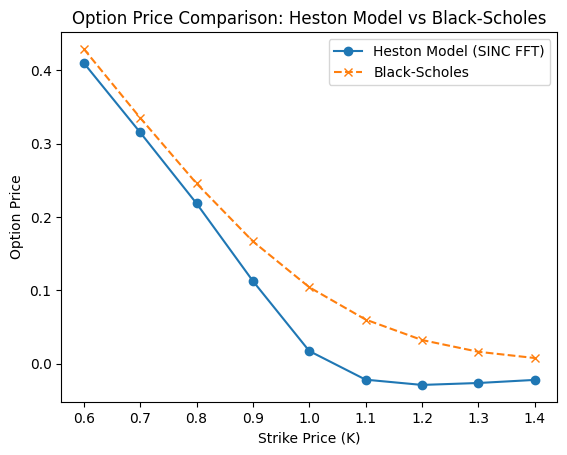

Strike Prices: [0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4]
Heston Model Prices: [ 0.41016264  0.31545475  0.21860474  0.1127435   0.01730197 -0.02177361
 -0.02893055 -0.02630609 -0.02209005]
Black-Scholes Prices: [0.4293723589126138, 0.3353805718734575, 0.24582029164024177, 0.16685860219932291, 0.10431799281677256, 0.060202763367546375, 0.032304282979526755, 0.016270345767953442, 0.007767649031033136]


In [23]:
import numpy as np

# Heston model characteristic function
def charfun_heston(params, u, t):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]
    
    beta = lambda_ - rho * eta * 1j * u
    alpha = -0.5 * u**2 - 0.5 * 1j * u
    zeta = 0.5 * eta**2
    
    d = np.sqrt(beta**2 - 4 * alpha * zeta)
    
    rm = (beta - d) / eta**2
    rp = (beta + d) / eta**2
    
    g = rm / rp
    
    C = rm * t - 2 / eta**2 * np.log((1 - g * np.exp(-d * t)) / (1 - g))
    D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t))
    
    phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    return phi

# SINC operation function
def sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    N = 2 ** pow
    
    # Construct truncation range
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl
    
    # Fourier modes for CoN put
    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n
    
    # Compute characteristic function values
    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn, t)
    f2l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn - 1j, t)
    
    # Zero-fill even frequencies
    q1l = np.zeros(N // 2)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N // 2)
    q2l[1::2] = f2l * Il
    
    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))
    f2u = np.flip(np.conj(f2l))
    
    # Zero-fill negative frequencies
    q1u = np.zeros(N // 2)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N // 2)
    q2u[::2] = f2u * Iu
    
    # Arrange for FFT algorithm
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])
    
    d1 = np.fft.fft(q1) + 0.5
    d2 = np.fft.fft(q2) + 0.5
    
    # Digital options computation
    d11 = d1[:N // 2]
    d12 = d1[N // 2:]
    d21 = d2[:N // 2]
    d22 = d2[N // 2:]
    
    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])
    
    m = np.arange(-N // 2, N // 2)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)
    
    # Price options
    conP = np.exp(-IR * t) * np.real(Km * dd1)
    aonP = np.exp(-DY * t) * np.real(S * dd2)
    
    conP = np.interp(K, Km, conP)
    aonP = np.interp(K, Km, aonP)
    
    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)
    
    return call if CP == 1 else put

from scipy.stats import norm

def black_scholes(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price

import matplotlib.pyplot as plt

def main():
    CP = 1  # for Call options
    S = 1
    t = 1.00
    K = S * np.arange(0.60, 1.41, 0.10)  # Strike prices
    IR = 0.05  # Interest rate
    DY = 0.02  # Dividend yield
    params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]  # Heston parameters
    
    # Select Xc based on time to maturity
    if t == 0.01:
        Xc = 1.3863
    elif t == 0.10:
        Xc = 2.0499
    elif t == 1.00:
        Xc = 12.1802
    elif t == 10:
        Xc = 32.8824
    Xm = 0
    
    pow = 18  # FFT precision for sinc method
    heston_prices = sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP)
    
    # Black-Scholes prices
    sigma_bs = np.sqrt(params[1])  # Approximate Black-Scholes volatility using v_bar
    bs_prices = [black_scholes(S, k, t, IR, sigma_bs, "call" if CP == 1 else "put") for k in K]
    
    # Plot results
    plt.plot(K, heston_prices, label="Heston Model (SINC FFT)", marker='o')
    plt.plot(K, bs_prices, label="Black-Scholes", linestyle='--', marker='x')
    plt.xlabel("Strike Price (K)")
    plt.ylabel("Option Price")
    plt.title("Option Price Comparison: Heston Model vs Black-Scholes")
    plt.legend()
    plt.show()
    
    # Print results for review
    print("Strike Prices:", K)
    print("Heston Model Prices:", heston_prices)
    print("Black-Scholes Prices:", bs_prices)

# Run the main function
main()

In [1]:
import numpy as np

# Heston model characteristic function
def charfun_heston(params, u, t):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]
    
    beta = lambda_ - rho * eta * 1j * u
    alpha = -0.5 * u**2 - 0.5 * 1j * u
    zeta = 0.5 * eta**2
    
    d = np.sqrt(beta**2 - 4 * alpha * zeta)
    
    rm = (beta - d) / eta**2
    rp = (beta + d) / eta**2
    
    g = rm / rp
    
    C = rm * t - 2 / eta**2 * np.log((1 - g * np.exp(-d * t)) / (1 - g))
    D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t))
    
    phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    return phi

# SINC operation function
def sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    N = 2 ** pow
    
    # Construct truncation range
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl
    
    # Fourier modes for CoN put
    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n
    
    # Compute characteristic function values
    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn, t)
    f2l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn - 1j, t)
    
    # Zero-fill even frequencies
    q1l = np.zeros(N // 2)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N // 2)
    q2l[1::2] = f2l * Il
    
    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))
    f2u = np.flip(np.conj(f2l))
    
    # Zero-fill negative frequencies
    q1u = np.zeros(N // 2)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N // 2)
    q2u[::2] = f2u * Iu
    
    # Arrange for FFT algorithm
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])
    
    d1 = np.fft.fft(q1) + 0.5
    d2 = np.fft.fft(q2) + 0.5
    
    # Digital options computation
    d11 = d1[:N // 2]
    d12 = d1[N // 2:]
    d21 = d2[:N // 2]
    d22 = d2[N // 2:]
    
    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])
    
    m = np.arange(-N // 2, N // 2)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)
    
    # Price options
    conP = np.exp(-IR * t) * np.real(Km * dd1)
    aonP = np.exp(-DY * t) * np.real(S * dd2)
    
    conP = np.interp(K, Km, conP)
    aonP = np.interp(K, Km, aonP)
    
    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)
    
    return call if CP == 1 else put

In [6]:
import numpy as np

def charfun_heston(params, u, t):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]
    
    beta = lambda_ - rho * eta * 1j * u
    alpha = -0.5 * u**2 - 0.5 * 1j * u
    zeta = 0.5 * eta**2
    
    d = np.sqrt(beta**2 - 4 * alpha * zeta)
    
    rm = (beta - d) / eta**2
    rp = (beta + d) / eta**2
    
    g = rm / rp
    
    C = rm * t - 2 / eta**2 * np.log((1 - g * np.exp(-d * t)) / (1 - g))
    D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t))
    
    phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    return phi

def cos_method(S, t, K, IR, DY, params, Xc, Xm, N, CP):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    K1 = np.exp(-(IR - DY) * t) * K
    x = np.log(S / K1)
    
    a = -Xc + Xm
    b = Xc + Xm
    k = np.arange(N)
    
    u = k * np.pi / (b - a)
    
    phi = charfun_heston(params, u, t)
    phi[0] = 1  # Set the first value of phi
    
    m = len(x)
    eto = np.zeros((m, N), dtype=complex)
    for count in range(m):
        eto[count, :] = np.exp(1j * np.pi * k * (x[count] - a) / (b - a))
    
    wgt = np.ones(N)
    wgt[0] = 0.5  # First weight is halved
    
    # Compute psi terms
    psih = b - a
    psit = (np.sin(k * np.pi * (b - a) / (b - a)) - np.sin(k * np.pi * (a - a) / (b - a))) * ((b - a) / (k * np.pi))
    psi = np.concatenate(([psih], psit[1:]))
    
    Vk1 = np.zeros((m, N), dtype=complex)
    for count in range(m):
        Vk1[count, :] = 2 / (b - a) * K[count] * psi
    
    conP = np.zeros(m)
    for count in range(m):
        conP[count] = np.real(np.dot(wgt * phi * eto[count, :], Vk1[count, :]))
    conP *= np.exp(-IR * t)
    
    # Chi term calculations
    add1 = np.cos(k * np.pi * (b - a) / (b - a)) * np.exp(b) - np.cos(k * np.pi * (a - a) / (b - a)) * np.exp(a)
    add2 = ((k * np.pi) / (b - a)) * (np.sin(k * np.pi * (b - a) / (b - a)) * np.exp(b) - np.sin(k * np.pi * (a - a) / (b - a)) * np.exp(a))
    fatt = 1.0 / (1 + ((k * np.pi) / (b - a))**2)
    chi = fatt * (add1 + add2)
    
    Vk2 = np.zeros((m, N), dtype=complex)
    for count in range(m):
        Vk2[count, :] = 2 / (b - a) * K1[count] * chi
    
    aonP = np.zeros(m)
    for count in range(m):
        aonP[count] = np.real(np.dot(wgt * phi * eto[count, :], Vk2[count, :]))
    aonP *= np.exp(-DY * t)
    
    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)
    
    conC = K * np.exp(-IR * t) - conP
    aonC = S * np.exp(-DY * t) - aonP
    
    return call if CP == 1 else put


In [7]:
# Assuming sinc_fast_ft and benchmark calculation function are implemented

# Main function
def main():
    CP = -1  # for Put options
    S = 1
    t = 1.00
    K = S * np.arange(0.60, 1.41, 0.10)
    IR = 0
    DY = 0
    params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]

    if t == 0.01:
        Xc = 1.3863
    elif t == 0.10:
        Xc = 2.0499
    elif t == 1.00:
        Xc = 12.1802
    elif t == 10:
        Xc = 32.8824
    Xm = 0

    # Grid sizes for different levels of accuracy
    N_vec = [128, 192, 256, 384, 512, 768] 
    #if t == 1 else [64, 128, 192, 256, 384, 512]
    m = len(N_vec)
    Q = len(K)

    # Initialize convergence table
    convtab = np.zeros((2 * Q, m))

    # Compute SINC and COS prices at various resolutions
    for q in range(Q):
        for i, NC in enumerate(N_vec):
            NS = 2 * NC
            # Compute SINC-based price
            convtab[q * 2, i] = sinc_fast_ft(S, t, K[q], IR, DY, params, Xc, Xm, int(np.log2(NS)), CP)
            # Compute COS-based price
            convtab[q * 2 + 1, i] = cos_method(S, t, K[q], IR, DY, params, Xc, Xm, int(np.log2(NC)), CP)

    # Compute high-resolution benchmark prices using SINC method
    NS = 2 ** 18
    benchmarkS = sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, int(np.log2(NS)), CP)

    # Calculate relative error table
    reltab = np.zeros_like(convtab)
    for q in range(Q):
        for i in range(m):
            if benchmarkS[q] != 0:  # Avoid division by zero
                reltab[q * 2, i] = abs(convtab[q * 2, i] - benchmarkS[q]) / abs(benchmarkS[q])
                reltab[q * 2 + 1, i] = abs(convtab[q * 2 + 1, i] - benchmarkS[q]) / abs(benchmarkS[q])

    # Optional rounding to match paper's format
    reltab = np.round(reltab, decimals=6)

    # Display relative error table in a formatted way
    print("\nRelative Error Table (reltab):")
    for q in range(Q):
        print(f"Strike Price {K[q]:.2f}")
        print("SINC method:", reltab[q * 2])
        print("COS method: ", reltab[q * 2 + 1])
        print("-" * 30)

# Run the main function
main()


Relative Error Table (reltab):
Strike Price 0.60
SINC method: [8.6117e-02 8.6117e-02 1.4000e-05 1.4000e-05 5.0000e-05 5.0000e-05]
COS method:  [1460539.422158 1460539.422158 4240882.029428 4240882.029428
  638639.140656  638639.140656]
------------------------------
Strike Price 0.70
SINC method: [0.01569  0.01569  0.035499 0.035499 0.000279 0.000279]
COS method:  [1775581.174098 1775581.174098 3470875.066322 3470875.066322
 1087671.151996 1087671.151996]
------------------------------
Strike Price 0.80
SINC method: [0.322705 0.322705 0.101312 0.101312 0.026261 0.026261]
COS method:  [1296884.398688 1296884.398688 1918880.880329 1918880.880329
  900597.243912  900597.243912]
------------------------------
Strike Price 0.90
SINC method: [0.007088 0.007088 0.018218 0.018218 0.009565 0.009565]
COS method:  [225310.938915 225310.938915 266776.165138 266776.165138 166776.324888
 166776.324888]
------------------------------
Strike Price 1.00
SINC method: [1. 1. 1. 1. 0. 0.]
COS method:  [7

C:\Users\Dominik\AppData\Local\Temp\ipykernel_12940\2915894097.py:50: ComplexWarning: Casting complex values to real discards the imaginary part
  q1l[1::2] = f1l * Il
C:\Users\Dominik\AppData\Local\Temp\ipykernel_12940\2915894097.py:52: ComplexWarning: Casting complex values to real discards the imaginary part
  q2l[1::2] = f2l * Il
C:\Users\Dominik\AppData\Local\Temp\ipykernel_12940\2915894097.py:60: ComplexWarning: Casting complex values to real discards the imaginary part
  q1u[::2] = f1u * Iu
C:\Users\Dominik\AppData\Local\Temp\ipykernel_12940\2915894097.py:62: ComplexWarning: Casting complex values to real discards the imaginary part
  q2u[::2] = f2u * Iu
C:\Users\Dominik\AppData\Local\Temp\ipykernel_12940\1618077847.py:52: RuntimeWarning: divide by zero encountered in divide
  psit = (np.sin(k * np.pi * (b - a) / (b - a)) - np.sin(k * np.pi * (a - a) / (b - a))) * ((b - a) / (k * np.pi))
C:\Users\Dominik\AppData\Local\Temp\ipykernel_12940\1618077847.py:52: RuntimeWarning: invali

In [48]:
def charfun_heston(params, u, t):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]
    
    beta = lambda_ - rho * eta * 1j * u
    alpha = -0.5 * u**2 - 0.5 * 1j * u
    zeta = 0.5 * eta**2
    
    d = np.sqrt(beta**2 - 4 * alpha * zeta)
    
    rm = (beta - d) / eta**2
    rp = (beta + d) / eta**2
    
    g = rm / rp
    
    C = rm * t - 2 / eta**2 * np.log((1 - g * np.exp(-d * t)) / (1 - g))
    D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t))
    
    phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    return phi

In [44]:
def calculate_compensator(mu_j, sigma_j, sigma_t, tau):
    """
    Calculates the compensator term mu_bar_j for the jump component of the characteristic function.
    
    Parameters:
    - mu_j: Mean jump size (log scale)
    - sigma_j: Volatility of jumps
    - sigma_t: Current volatility of the asset
    - tau: Small time to maturity

    Returns:
    - mu_bar_j: The compensator for the mean jump size.
    """
    mu_bar_j = np.exp(mu_j / (sigma_t * np.sqrt(tau)) + (sigma_j**2 / (2 * sigma_t**2 * tau))) - 1
    return mu_bar_j

def discrete_component(u, tau, sigma_t, lambda_t, mu_j, sigma_j, mu_bar_j):
    """
    Calculates the discrete (jump) component of the characteristic function for the model.
    """
    jump_mean_term = 1j * u * mu_j / (sigma_t * np.sqrt(tau))
    jump_variance_term = - u**2 * sigma_j**2 / (2 * sigma_t**2 * tau)
    C_logXd = np.exp(tau * lambda_t * (np.exp(jump_mean_term + jump_variance_term) - 1 - 1j * u * mu_bar_j))
    return C_logXd

def continuous_component(u, tau, sigma_t, mu_tilde, rho_t, alpha_q, beta_tilde, delta_tilde, eta_t):
    """
    Calculates the continuous (diffusive) component of the characteristic function for the model.
    """
    drift_term = 1j * u * (mu_tilde * tau) / (sigma_t * np.sqrt(tau))
    gaussian_term = -0.5 * u**2
    third_moment_adjustment = -1j * u**3 * (beta_tilde * rho_t) / (2 * sigma_t) * np.sqrt(tau)
    second_moment_adjustment = - u**2 * ((alpha_q + delta_tilde) / (2 * sigma_t) + beta_tilde**2 / (4 * sigma_t**2)) * tau
    fourth_moment_adjustment = (1 / 24) * (beta_tilde**2 / sigma_t**2) * u**2 * (4 * u**2 - rho_t**2 * u**2 * (3 * u**2 - 8)) * tau
    sixth_moment_adjustment = (eta_t / (6 * sigma_t)) * u**4 * tau
    adjustments = 1 + third_moment_adjustment + second_moment_adjustment + fourth_moment_adjustment + sixth_moment_adjustment
    C_logXc = np.exp(drift_term + gaussian_term) * adjustments
    return C_logXc

def charfun(u, tau, sigma_t, lambda_t, mu_j, sigma_j, mu_tilde, rho_t, alpha_q, beta_tilde, delta_tilde, eta_t):
    """
    Combines the discrete and continuous components to produce the full characteristic function for the model.
    
    Parameters:
    - u: Fourier variable
    - tau: Small time to maturity
    - sigma_t, lambda_t, mu_j, sigma_j: Jump component parameters
    - mu_tilde, rho_t, alpha_q, beta_tilde, delta_tilde, eta_t: Continuous component parameters

    Returns:
    - The complete characteristic function for the model.
    """
    # Calculate compensator for the discrete component
    mu_bar_j = calculate_compensator(mu_j, sigma_j, sigma_t, tau)
    
    # Calculate discrete and continuous components
    C_logXd = discrete_component(u, tau, sigma_t, lambda_t, mu_j, sigma_j, mu_bar_j)
    C_logXc = continuous_component(u, tau, sigma_t, mu_tilde, rho_t, alpha_q, beta_tilde, delta_tilde, eta_t)
    
    # Full characteristic function as product of continuous and discrete components
    phi = C_logXc * C_logXd
    return phi


In [45]:
import numpy as np
from scipy.fft import fft
from scipy.interpolate import interp1d

def SINC_fastFT(S, t, K, IR, DY, model, params, xi, j, Xc, Xm, pow, CP):
    """
    SINC method for FFT pricing of European plain vanilla call/put options.
    
    Parameters:
    - S: Spot price of the underlying asset
    - t: Time to maturity
    - K: Array of strike prices
    - IR: Interest rate
    - DY: Dividend yield
    - model: Model for characteristic function
    - params: Model parameters for the characteristic function
    - xi, j: Other specific parameters for characteristic function if needed
    - Xc, Xm: Truncation center and offset for the Fourier range
    - pow: Power of 2 for FFT size (N = 2^pow)
    - CP: Option type (1 for call, -1 for put)

    Returns:
    - Array of option prices (call or put depending on CP)
    """
    # Ensure K is a row vector
    if K.ndim == 1:
        K = K.reshape(1, -1)
    
    # Number of Fourier modes for FFT
    N = 2**pow
    
    # Construct truncation range and Fourier modes
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl
    n = np.arange(1, N//2, 2)
    wn = n / wid
    
    # Weights for positive and negative frequencies
    Il = 2 / n
    Iu = -Il[::-1]

    # Evaluate CF at sampled Fourier modes for CoN and AoN options
    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun(model, params, xi, j, 2 * np.pi * wn, t)
    f2l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun(model, params, xi, j, 2 * np.pi * wn - 1j, t)

    # Set even frequencies to zero
    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N // 2, dtype=complex)
    q2l[1::2] = f2l * Il
    
    # Negative frequency components
    f1u = np.conj(f1l[::-1])
    f2u = np.conj(f2l[::-1])
    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N // 2, dtype=complex)
    q2u[::2] = f2u * Iu
    
    # Rearrange for FFT algorithm
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])
    
    # Perform FFT for CoN and AoN
    d1 = fft(q1) + 0.5
    d2 = fft(q2) + 0.5
    
    # Extract digital option components
    d11, d12 = d1[:N//2], d1[N//2:]
    d21, d22 = d2[:N//2], d2[N//2:]
    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])
    
    # Define strike grid and compute buckets
    m = np.arange(-N//2, N//2)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)
    
    # Calculate CoN and AoN put prices over the buckets
    conP = np.exp(-IR * t) * np.real(Km * dd1)
    aonP = np.exp(-DY * t) * np.real(S * dd2)
    
    # Interpolate on the desired strikes
    conP_interp = interp1d(Km, conP, kind='linear', fill_value="extrapolate")
    aonP_interp = interp1d(Km, aonP, kind='linear', fill_value="extrapolate")
    conP = conP_interp(K)
    aonP = aonP_interp(K)
    
    # Put price as a linear combination of digital options
    put = conP - aonP  # Based on put pricing formula
    
    # Call price from put-call parity
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)
    
    # Output call or put price based on CP flag
    return call if CP == 1 else put


In [47]:
import numpy as np

# Assume all the helper functions from above (charfun, SINC_fastFT, calculate_compensator, etc.) are already defined

# 1. Set parameters for the test
S = 100          # Spot price of the underlying asset
K = np.array([90, 100, 110])  # Array of strike prices for testing
t = 0.001        # Time to maturity, very close to 0 for 0DTE options
IR = 0.01        # Risk-free interest rate
DY = 0.0         # Dividend yield
Xc = 10          # Truncation center
Xm = 5           # Offset
pow = 12         # Power for FFT size, so N = 2^pow
CP = 1           # 1 for call, -1 for put

# 2. Set model parameters for our characteristic function model
# Example parameters based on the continuous and discrete components
sigma_t = 0.2         # Current volatility
lambda_t = 0.1        # Jump intensity
mu_j = -0.05          # Mean jump size
sigma_j = 0.1         # Jump size volatility
mu_tilde = IR - 0.5 * sigma_t**2  # Adjusted drift term
rho_t = -0.5          # Correlation between price and variance
alpha_q = 0.05        # Risk-neutral drift adjustment for volatility
beta_tilde = 0.2      # Term for volatility skew adjustment
delta_tilde = 0.02    # Additional variance adjustment
eta_t = 0.1           # Higher moment adjustment

# Bundle parameters for easy passing
params = (sigma_t, lambda_t, mu_j, sigma_j, mu_tilde, rho_t, alpha_q, beta_tilde, delta_tilde, eta_t)

# Define a wrapper function for charfun that fits the SINC_fastFT input structure
def test_charfun(model, params, xi, j, u, t):
    # Unpack all parameters needed by charfun
    sigma_t, lambda_t, mu_j, sigma_j, mu_tilde, rho_t, alpha_q, beta_tilde, delta_tilde, eta_t = params
    
    # Call the charfun with all required parameters
    return charfun(u, t, sigma_t, lambda_t, mu_j, sigma_j, mu_tilde, rho_t, alpha_q, beta_tilde, delta_tilde, eta_t)

# 3. Use `test_charfun` in place of `charfun` in the SINC_fastFT function call
call_prices = SINC_fastFT(S, t, K, IR, DY, 'custom', params, None, None, Xc, Xm, pow, CP=1)
put_prices = SINC_fastFT(S, t, K, IR, DY, 'custom', params, None, None, Xc, Xm, pow, CP=-1)

# 4. Display results
print("Strike Prices:", K)
print("Call Prices for 0DTE Options:", call_prices)
print("Put Prices for 0DTE Options:", put_prices)



TypeError: charfun() missing 6 required positional arguments: 'mu_tilde', 'rho_t', 'alpha_q', 'beta_tilde', 'delta_tilde', and 'eta_t'

In [42]:
import numpy as np

def discrete_component(u, tau, sigma_t, lambda_t, mu_j, sigma_j, mu_bar_j):
    """
    Calculates the discrete (jump) component of the characteristic function for 0DTE options.

    Parameters:
    - u: Fourier variable
    - tau: Small time to maturity
    - sigma_t: Current volatility of the asset
    - lambda_t: Jump intensity (expected number of jumps per unit time)
    - mu_j: Mean jump size (log scale)
    - sigma_j: Volatility of jumps
    - mu_bar_j: Adjusted mean jump size (log scale)

    Returns:
    - The discrete component of the characteristic function value for the log-price of the asset.
    """
    
    # Calculate the exponent terms
    jump_mean_term = 1j * u * mu_j / (sigma_t * np.sqrt(tau))
    jump_variance_term = - u**2 * sigma_j**2 / (2 * sigma_t**2 * tau)
    
    # Combine terms to compute the discrete component
    C_logXd = np.exp(tau * lambda_t * (np.exp(jump_mean_term + jump_variance_term) - 1 - 1j * u * mu_bar_j))
    
    return C_logXd


In [43]:
def calculate_compensator(mu_j, sigma_j, sigma_t, tau):
    """
    Calculates the compensator term mu_bar_j for the jump component of the characteristic function.
    
    Parameters:
    - mu_j: Mean jump size (log scale)
    - sigma_j: Volatility of jumps
    - sigma_t: Current volatility of the asset
    - tau: Small time to maturity

    Returns:
    - mu_bar_j: The compensator for the mean jump size.
    """
    
    # Calculate the compensator mu_bar_j
    mu_bar_j = np.exp(mu_j / (sigma_t * np.sqrt(tau)) + (sigma_j**2 / (2 * sigma_t**2 * tau))) - 1
    
    return mu_bar_j

In [ ]:
import numpy as np

def continuous_component(u, tau, sigma_t, mu_tilde, rho_t, alpha_q, beta_tilde, delta_tilde, eta_t):
    """
    Calculates the continuous (diffusive) component of the characteristic function for 0DTE options.

    Parameters:
    - u: Fourier variable
    - tau: Small time to maturity
    - sigma_t: Current volatility of the asset
    - mu_tilde: Adjusted drift term in the continuous component
    - rho_t: Correlation between asset price and variance
    - alpha_q: Risk-neutral drift adjustment for volatility process
    - beta_tilde: Term for volatility skew adjustment
    - delta_tilde: Additional variance adjustment
    - eta_t: Higher moment adjustment factor for variance

    Returns:
    - The continuous component of the characteristic function value for the log-price of the asset.
    """
    
    # Drift term and Gaussian base component
    drift_term = 1j * u * (mu_tilde * tau) / (sigma_t * np.sqrt(tau))
    gaussian_term = -0.5 * u**2

    # Third moment adjustment (skewness adjustment)
    third_moment_adjustment = -1j * u**3 * (beta_tilde * rho_t) / (2 * sigma_t) * np.sqrt(tau)

    # Second, fourth, and sixth moment adjustments (kurtosis and higher-order adjustments)
    second_moment_adjustment = - u**2 * ((alpha_q + delta_tilde) / (2 * sigma_t) + beta_tilde**2 / (4 * sigma_t**2)) * tau
    fourth_moment_adjustment = (1 / 24) * (beta_tilde**2 / sigma_t**2) * u**2 * (4 * u**2 - rho_t**2 * u**2 * (3 * u**2 - 8)) * tau
    sixth_moment_adjustment = (eta_t / (6 * sigma_t)) * u**4 * tau

    # Combine adjustments
    adjustments = 1 + third_moment_adjustment + second_moment_adjustment + fourth_moment_adjustment + sixth_moment_adjustment

    # Final continuous component
    C_logXc = np.exp(drift_term + gaussian_term) * adjustments
    
    return C_logXc


In [41]:
import numpy as np

# Parameters calculated outside the characteristic function
def calculate_characteristic_params(sigma_t, tau, lambda_t, mu_j, sigma_j, mu_tilde, rho_t, 
                                    alpha_q, beta_tilde, delta_tilde, eta_t, mu_bar_j):
    """
    Calculates pre-computed terms for the characteristic function to be used in Fourier pricing.
    """
    # Drift term
    drift_term_1 = 1j * mu_tilde * tau / (sigma_t * np.sqrt(tau)) 
    drift_term_2 = - 0.5

    # Jump component
    jump_mean = np.exp(1j * mu_j / (sigma_t * np.sqrt(tau))) - 1
    jump_variance = - (sigma_j**2) / (2 * sigma_t**2 * tau)
    jump_component = lambda_t * tau * (np.exp(jump_mean + jump_variance) - 1 - 1j * mu_bar_j)

    # Continuous component: skew and kurtosis adjustments
    skew_adjustment = -1j * (beta_tilde * rho_t) / (2 * sigma_t) * np.sqrt(tau)

    # Splitting second_fourth_sixth_adjustments into separate terms for clarity
    second_moment_adjustment = - (alpha_q + delta_tilde) / (2 * sigma_t) * tau
    fourth_moment_adjustment = - (beta_tilde**2 / (4 * sigma_t**2)) * tau
    kurtosis_adjustment = (1 / 24) * (beta_tilde**2 / sigma_t**2) * (4 - rho_t**2 * (3 - 8)) * tau
    sixth_moment_adjustment = eta_t / (6 * sigma_t) * tau

    return drift_term_1, drift_term_2, jump_component, skew_adjustment, second_moment_adjustment, fourth_moment_adjustment, kurtosis_adjustment, sixth_moment_adjustment

# Characteristic function
def characteristic_function(u, drift_term_1, drift_term_2, jump_component, skew_adjustment, 
                            second_moment_adjustment, fourth_moment_adjustment, 
                            kurtosis_adjustment, sixth_moment_adjustment):
    """
    Complete characteristic function for 0DTE options using precomputed parameters.
    """
    
    # Jump Component
    C_logXd = np.exp(jump_component)
    
    # Continuous Component with Adjustments
    C_logXc = np.exp(drift_term_1 * u + drift_term_2 * u**2) * (1 + u**3 * skew_adjustment 
                    + u**2 * (second_moment_adjustment + fourth_moment_adjustment + kurtosis_adjustment + sixth_moment_adjustment))
    
    # Complete Characteristic Function (Product of Continuous and Discrete Components)
    characteristic_function_value = C_logXc * C_logXd
    return characteristic_function_value


In [ ]:
import numpy as np

def characteristic_function(u, tau, sigma_t, lambda_t, mu_j, sigma_j, mu_bar_j, 
                           mu_tilde, rho_t, alpha_q, beta_tilde, delta_tilde, eta_t):
    """
    Complete characteristic function for 0DTE options with baseline specification.
    
    Parameters:
    - u: Fourier variable
    - tau: Small time to maturity
    - sigma_t: Current volatility of the asset
    - lambda_t: Jump intensity (expected number of jumps per unit time)
    - mu_j: Mean jump size (log scale)
    - sigma_j: Volatility of jumps
    - mu_bar_j: Adjusted mean jump size (log scale)
    - mu_tilde: Adjusted drift term in continuous component
    - rho_t: Correlation between asset price and variance
    - alpha_q: Risk-neutral drift adjustment
    - beta_tilde: Term for volatility skew adjustment
    - delta_tilde: Additional variance adjustment
    - eta_t: Higher moment adjustment factor for variance

    Returns:
    - The complete characteristic function value for log-price of the asset.
    """

    # Discrete Component for Jumps
    jump_mean = np.exp(1j * u * (mu_j / (sigma_t * np.sqrt(tau)))) - 1
    jump_variance = - u**2 * (sigma_j**2 / (2 * sigma_t**2 * tau))
    C_logXd = np.exp(tau * lambda_t * (np.exp(jump_mean + jump_variance) - 1 - 1j * u * mu_bar_j))

    # Continuous Component with Higher-Order Moment Adjustments
    skew_adjustment = -1j * u**3 * (beta_tilde * rho_t) / (2 * sigma_t) * np.sqrt(tau)
    second_fourth_sixth_adjustments = (
        - u**2 * ((alpha_q + delta_tilde) / (2 * sigma_t) + beta_tilde**2 / (4 * sigma_t**2)) * tau
        + (1 / 24) * (beta_tilde**2 / sigma_t**2) * u**2 * (4 * u**2 - rho_t**2 * u**2 * (3 * u**2 - 8)) * tau
        + (eta_t / (6 * sigma_t)) * u**4 * tau
    )

    # Complete Continuous Component
    drift_term = 1j * u * (mu_tilde * tau) / (sigma_t * np.sqrt(tau)) - 0.5 * u**2
    C_logXc = np.exp(drift_term) * (1 + skew_adjustment + second_fourth_sixth_adjustments)

    # Final Characteristic Function (Product of Continuous and Discrete Components)
    characteristic_function_value = C_logXc * C_logXd
    return characteristic_function_value


In [ ]:
import numpy as np

def characteristic_function(u, tau, sigma_t, lambda_t, mu_j, sigma_j, mu_bar_j, 
                           mu_tilde, rho_t, alpha_q, beta_tilde, delta_tilde, eta_t):
    """
    Complete characteristic function for 0DTE options with baseline specification.
    
    Parameters:
    - u: Fourier variable
    - tau: Small time to maturity
    - sigma_t: Current volatility of the asset
    - lambda_t: Jump intensity (expected number of jumps per unit time)
    - mu_j: Mean jump size (log scale)
    - sigma_j: Volatility of jumps
    - mu_bar_j: Adjusted mean jump size (log scale)
    - mu_tilde: Adjusted drift term in continuous component
    - rho_t: Correlation between asset price and variance
    - alpha_q: Risk-neutral drift adjustment
    - beta_tilde: Term for volatility skew adjustment
    - delta_tilde: Additional variance adjustment
    - eta_t: Higher moment adjustment factor for variance

    Returns:
    - The complete characteristic function value for log-price of the asset.
    """

    # Discrete Component for Jumps
    jump_mean = np.exp(1j * u * (mu_j / (sigma_t * np.sqrt(tau))))
    jump_variance = - u**2 * (sigma_j**2 / (2 * sigma_t**2 * tau))

    # Compensator term for risk-neutral measure (from the paper)
    mu_bar_j = np.exp(mu_j / (sigma_t * np.sqrt(tau)) + sigma_j**2 / (2 * sigma_t**2 * tau)) - 1

    # Full discrete component characteristic function
    C_logXd = np.exp(tau * lambda_t * (jump_mean + jump_variance - 1 - 1j * u * mu_bar_j))

    # Continuous Component with Higher-Order Moment Adjustments
    skew_adjustment = -1j * u**3 * (beta_tilde * rho_t) / (2 * sigma_t) * np.sqrt(tau)
    second_fourth_sixth_adjustments = (
        - u**2 * ((alpha_q + delta_tilde) / (2 * sigma_t) + beta_tilde**2 / (4 * sigma_t**2)) * tau
        + (1 / 24) * (beta_tilde**2 / sigma_t**2) * u**2 * (4 * u**2 - rho_t**2 * u**2 * (3 * u**2 - 8)) * tau
        + (eta_t / (6 * sigma_t)) * u**4 * tau
    )

    # Complete Continuous Component
    drift_term = 1j * u * (mu_tilde * tau) / (sigma_t * np.sqrt(tau)) - 0.5 * u**2
    C_logXc = np.exp(drift_term) * (1 + skew_adjustment + second_fourth_sixth_adjustments)

    # Final Characteristic Function (Product of Continuous and Discrete Components)
    characteristic_function_value = C_logXc * C_logXd
    return characteristic_function_value


In [37]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from scipy.stats import norm
from scipy.integrate import quad
import matplotlib.pyplot as plt
from scipy.stats import qmc


In [31]:
class ODTE_ANN(nn.Module):
    def __init__(self):
        super(ODTE_ANN, self).__init__()
        # Neural network layers
        self.fc1 = nn.Linear(4, 400)
        self.fc2 = nn.Linear(400, 400)
        self.fc3 = nn.Linear(400, 400)
        self.fc4 = nn.Linear(400, 1)
        
        # Xavier initialization
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.xavier_uniform_(self.fc3.weight)
        nn.init.xavier_uniform_(self.fc4.weight)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)
    
    def train_model(self, args, device, train_loader, optimizer, epoch):
        self.train()
        train_loss = 0
        for batch_idx, data in enumerate(train_loader):
            inputs, targets = data[:,:-1].to(device), data[:,-1].to(device)
            optimizer.zero_grad()
            output = self(inputs)
            loss = F.mse_loss(output, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        return train_loss

    def test_model(self, device, test_loader):
        self.eval()
        test_loss = 0
        with torch.no_grad():
            for data in test_loader:
                inputs, targets = data[:,:-1].to(device), data[:,-1].to(device)
                output = self(inputs)
                test_loss += F.mse_loss(output, targets)
        return test_loss


In [32]:
def bs_moneyness_call(moneyness, tau, r, sigma):
    d1 = (np.log(moneyness) + (r + 0.5 * sigma ** 2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    value_moneyness = moneyness * norm.cdf(d1) - np.exp(-r * tau) * norm.cdf(d2)
    return value_moneyness

def bs_LHS_data_generator(n=10**4, l_bounds=[.4, .2, .02, .01], u_bounds=[1.6, 1.1, .1, 1]):
    sampler = qmc.LatinHypercube(d=4)
    sample = sampler.random(n)
    sample = qmc.scale(sample, l_bounds, u_bounds)
    bs_prices = bs_moneyness_call(sample[:, 0], sample[:, 1], sample[:, 2], sample[:, 3]).reshape((-1, 1))
    bs_dataset = np.concatenate((sample, bs_prices), axis=1)
    return torch.FloatTensor(bs_dataset)


cuda


In [40]:
# Parameters
S_t = 100
K = 105
r = 0.05
sigma = 0.2
tau = 0.02

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print(device)

# Baseline Pricing
price_baseline = sinc_pricing(K, S_t, r, sigma, tau)
print(f"Baseline Price: {price_baseline}")

# Second Specification Pricing (with volatility jumps)
lambda_sigma = 0.1
rho_J = 0.3
s_sigma = 0.05
price_second = sinc_pricing(K, S_t, r, sigma, tau, lambda_sigma, rho_J, s_sigma, is_second=True)
print(f"Second Spec Price: {price_second}")

# Initialize the Neural Network Model
model = ODTE_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Load and split dataset
bs_dataset = bs_LHS_data_generator(n=10**4)
train_size = int(0.9 * bs_dataset.shape[0])
test_size = bs_dataset.shape[0] - train_size
train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=1024)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1024)

# Train the model
for epoch in range(1, 201):
    train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
    test_loss = model.test_model(device, test_loader)
    print(f'Epoch {epoch}: Train Loss: {train_loss}, Test Loss: {test_loss}')


cuda
Baseline Price: nan
Second Spec Price: nan


C:\Users\Dominik\AppData\Local\Temp\ipykernel_9164\1882450711.py:14: RuntimeWarning: divide by zero encountered in divide
  integrand = np.exp(-1j * k_values * np.log(K)) * cf_values / (1j * k_values)
C:\Users\Dominik\AppData\Local\Temp\ipykernel_9164\1882450711.py:14: RuntimeWarning: invalid value encountered in divide
  integrand = np.exp(-1j * k_values * np.log(K)) * cf_values / (1j * k_values)
C:\Users\Dominik\AppData\Local\Temp\ipykernel_9164\1882450711.py:17: RuntimeWarning: invalid value encountered in scalar multiply
  price = (h / (2 * np.pi)) * np.sum(integrand)


RuntimeError: CUDA error: unknown error
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [25]:
import numpy as np
from scipy.integrate import quad
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from scipy.stats import norm
from scipy import integrate
import matplotlib.pyplot as plt
from scipy.stats import qmc
from torch.optim.lr_scheduler import StepLR, LinearLR, OneCycleLR, LambdaLR

def characteristic_function(u, tau, S0, r, sigma, lambda_jump, mu_jump, sigma_jump, 
                            rho, vol_of_vol, lambda_vol_jump, sigma_vol_jump):
    """
    Complete characteristic function for 0DTE option pricing with jumps in both price and volatility.
    u: Fourier variable
    tau: time to maturity (0DTE means tau is very small)
    S0: initial stock price
    r: risk-free rate
    sigma: initial volatility
    lambda_jump: intensity of price jumps
    mu_jump: mean of price jumps
    sigma_jump: volatility of price jumps
    rho: correlation between price and volatility
    vol_of_vol: volatility of volatility (vol-vol)
    lambda_vol_jump: intensity of volatility jumps
    sigma_vol_jump: volatility of volatility jumps
    """
    # Adjusted drift to account for jumps in price
    drift_adj = r - 0.5 * sigma**2 - lambda_jump * (np.exp(mu_jump + 0.5 * sigma_jump**2) - 1)

    # Continuous part of the characteristic function
    continuous_part = np.exp(1j * u * (np.log(S0) + drift_adj * tau) - 0.5 * u**2 * sigma**2 * tau)
    
    # Jump component for prices
    price_jump_part = np.exp(tau * lambda_jump * (np.exp(1j * u * mu_jump - 0.5 * u**2 * sigma_jump**2) - 1))
    
    # Jump component for volatility
    vol_jump_part = np.exp(tau * lambda_vol_jump * (np.exp(-0.5 * u**2 * sigma_vol_jump**2) - 1))

    # Skewness and kurtosis from leverage and volatility of volatility
    skew_kurt_part = np.exp(1j * u * rho * vol_of_vol * np.sqrt(tau) - 0.5 * (u**2 * vol_of_vol**2 * tau))
    
    # Complete characteristic function combining all components
    total_char_func = continuous_part * price_jump_part * vol_jump_part * skew_kurt_part
    
    return total_char_func



In [20]:
def zeroDTE_option_price(S0, K, tau, r, sigma, lambda_jump, mu_jump, sigma_jump, 
                      rho, vol_of_vol, lambda_vol_jump, sigma_vol_jump):
    """
    Compute the 0DTE option price using Fourier inversion.
    S0: initial stock price
    K: strike price
    tau: time to maturity (very small for 0DTE)
    r: risk-free rate
    sigma: volatility
    Other parameters correspond to jumps and volatility jumps.
    """
    # Strike price in terms of log-moneyness
    log_moneyness = np.log(S0 / K)

    # Integrand function for Fourier inversion
    def integrand(u):
        cf = characteristic_function(u - 1j, tau, S0, r, sigma, lambda_jump, mu_jump, sigma_jump, 
                                     rho, vol_of_vol, lambda_vol_jump, sigma_vol_jump)
        return np.real(np.exp(-1j * u * log_moneyness) * cf / (1j * u))

    # Integration bounds
    integral = quad(integrand, 0, np.inf, limit=200)[0]
    
    # Final price using Fourier inversion formula
    price = S0 * np.exp(-r * tau) * (0.5 + integral / np.pi)
    return price


In [21]:
def generate_0DTE_data(n=10**6, l_bounds=[0.8, 0.001, 0.01, 0.01], u_bounds=[1.2, 0.01, 0.03, 0.5]):
    """
    Generate samples of 0DTE option prices using Latin hypercube sampling.
    Returns a torch tensor of dimension (n, 5) containing the inputs and option prices.
    n: number of samples
    l_bounds: lower bounds for the inputs
    u_bounds: upper bounds for the inputs
    """
    sampler = qmc.LatinHypercube(d=4)
    sample = sampler.random(n)
    sample = qmc.scale(sample, l_bounds, u_bounds)

    S0, K, tau, sigma = sample[:, 0], sample[:, 0] * np.random.uniform(0.9, 1.1, size=n), sample[:, 1], sample[:, 3]
    
    # Jumps and volatility of volatility parameters (randomly sampled)
    lambda_jump = np.random.uniform(0.01, 0.5, n)
    mu_jump = np.random.uniform(-0.1, 0.1, n)
    sigma_jump = np.random.uniform(0.1, 0.3, n)
    rho = np.random.uniform(-0.5, 0, n)
    vol_of_vol = np.random.uniform(0.1, 0.4, n)
    lambda_vol_jump = np.random.uniform(0.01, 0.2, n)
    sigma_vol_jump = np.random.uniform(0.05, 0.15, n)
    
    prices = np.array([zeroDTE_option_price(S0[i], K[i], tau[i], 0.01, sigma[i], 
                                         lambda_jump[i], mu_jump[i], sigma_jump[i], 
                                         rho[i], vol_of_vol[i], lambda_vol_jump[i], sigma_vol_jump[i])
                       for i in range(n)])
    
    bs_dataset = np.column_stack((S0/K, tau, 0.01, sigma, prices / K))
    return torch.FloatTensor(bs_dataset)


In [23]:
# Black-Scholes ANN Model (baseline)
class BS_ANN(nn.Module):
    def __init__(self):
        """
        Initializes a 5-layer neural network model for option pricing.
        Input: [S/K, time to maturity, risk-free rate, volatility]
        Output: [Option price]
        """
        super(BS_ANN, self).__init__()
        self.fc1 = nn.Linear(4, 400)
        self.fc2 = nn.Linear(400, 400)
        self.fc3 = nn.Linear(400, 400)
        self.fc4 = nn.Linear(400, 400)
        self.fc5 = nn.Linear(400, 1)
        
        # Xavier uniform initialization
        torch.nn.init.xavier_uniform_(self.fc1.weight)
        torch.nn.init.xavier_uniform_(self.fc2.weight)
        torch.nn.init.xavier_uniform_(self.fc3.weight)
        torch.nn.init.xavier_uniform_(self.fc4.weight)
        torch.nn.init.xavier_uniform_(self.fc5.weight)

    def forward(self, x):
        """
        Forward pass through the neural network.
        ReLU activation is used for hidden layers and linear for output.
        """
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        return self.fc5(x).flatten()

# Training function for the ANN
def train_model(model, args, device, train_loader, optimizer, epoch):
    """
    Training loop for one epoch.
    model: the neural network to train.
    args: training parameters.
    device: CUDA or CPU.
    train_loader: training data loader.
    optimizer: optimization algorithm.
    epoch: current epoch number.
    """
    model.train()
    train_loss = 0

    for batch_idx, data in enumerate(train_loader):
        data, target = data[:, :-1].to(device), data[:, -1].to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.mse_loss(output, target)
        train_loss += loss.item() * data.shape[0]
        loss.backward()
        optimizer.step()

        if batch_idx % args["log_interval"] == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)] Loss: {loss.item():.6f}')

    train_loss /= len(train_loader.dataset)
    print(f'\nTrain set: Average loss: {train_loss:.4f}')
    return train_loss

# Testing function for the ANN
def test_model(model, device, test_loader):
    """
    Test the model on test_loader dataset.
    device: CUDA or CPU.
    test_loader: testing data loader.
    """
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for data in test_loader:
            data, target = data[:, :-1].to(device), data[:, -1].to(device)
            output = model(data)
            test_loss += F.mse_loss(output, target, reduction='sum').item()

    test_loss /= len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}')
    return test_loss

In [26]:
# Use your existing BS_ANN architecture

# Hyperparameters and device configuration
args = {
    "batch_size": 1024,
    "test_batch_size": 1024,
    "epochs": 200,
    "lr": 1e-3,  # Initial learning rate
    "gamma": 0.9,  # Learning rate decay factor
    "no_cuda": False,
    "log_interval": 10,
    "save_model": False
}

# Set up the device (GPU/CPU)
use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# Data generation
bs_dataset = generate_0DTE_data(n=10**4)

# Splitting and loading data
train_size, test_size = int(bs_dataset.shape[0] * 0.9), int(bs_dataset.shape[0] * 0.1)
train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=args["test_batch_size"])

# Model training
model = BS_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"])
scheduler = LambdaLR(optimizer, lr_lambda=lambda epoch: 10**(-9 + epoch * 10 / (args["epochs"] - 1)))

train_losses = []
test_losses = []
lrs = []

# Training loop
for epoch in range(1, args["epochs"] + 1):
    print(f"Current Learning Rate: {scheduler.get_last_lr()[0]}")
    lrs.append(scheduler.get_last_lr()[0])
    train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
    test_loss = model.test_model(device, test_loader)
    scheduler.step()
    train_losses.append(train_loss)
    test_losses.append(test_loss)

# Optionally save the model
if args["save_model"]:
    torch.save(model.state_dict(), "0DTE_ANN_model.pt")


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 10000 and the array at index 2 has size 1

In [7]:
# Required imports


# Define the Black-Scholes price function (baseline)
def bs_moneyness_call(moneyness, tau, r, sigma):
    """
    Black-Scholes price for European call option in terms of moneyness.

    Parameters:
    moneyness: S/K, ratio of spot price to strike price
    tau: Time to maturity
    r: Risk-free interest rate
    sigma: Volatility of underlying asset

    Returns:
    The price of a call option.
    """
    d1 = (np.log(moneyness) + (r + 0.5 * sigma ** 2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    value_moneyness = moneyness * norm.cdf(d1) - np.exp(-r * tau) * norm.cdf(d2)

    return value_moneyness

# Data generation function using Latin Hypercube Sampling
def bs_LHS_data_generator(n=10**6, l_bounds=[.4, .2, .02, .01], u_bounds=[1.6, 1.1, .1, 1]):
    """
    Generates samples of call prices using Latin hypercube sampling.

    Parameters:
    n: number of samples.
    l_bounds: lower bounds for the inputs.
    u_bounds: upper bounds for the inputs.

    Returns:
    A torch float tensor of shape (n, 5) containing input samples and corresponding option prices.
    """
    sampler = qmc.LatinHypercube(d=4)
    sample = sampler.random(n)
    sample = qmc.scale(sample, l_bounds, u_bounds)
    bs_prices = bs_moneyness_call(sample[:, 0], sample[:, 1], sample[:, 2], sample[:, 3]).reshape((-1, 1))
    bs_dataset = np.concatenate((sample, bs_prices), axis=1)

    print("------ INPUT ------")
    print(f"S/K.......... [{min(bs_dataset[:,0]):.2f} {max(bs_dataset[:,0]):.2f}]")
    print(f"Tau.......... [{min(bs_dataset[:,1]):.2f} {max(bs_dataset[:,1]):.2f}]")
    print(f"r............ [{min(bs_dataset[:,2]):.2f} {max(bs_dataset[:,2]):.2f}]")
    print(f"Sigma........ [{min(bs_dataset[:,3]):.2f} {max(bs_dataset[:,3]):.2f}]")
    print("------ OUTPUT ------")
    print(f"V/K.......... [{min(bs_dataset[:,4]):.2f} {max(bs_dataset[:,4]):.2f}]")

    return torch.FloatTensor(bs_dataset)

# Black-Scholes ANN Model (baseline)
class BS_ANN(nn.Module):
    def __init__(self):
        """
        Initializes a 5-layer neural network model for option pricing.
        Input: [S/K, time to maturity, risk-free rate, volatility]
        Output: [Option price]
        """
        super(BS_ANN, self).__init__()
        self.fc1 = nn.Linear(4, 400)
        self.fc2 = nn.Linear(400, 400)
        self.fc3 = nn.Linear(400, 400)
        self.fc4 = nn.Linear(400, 400)
        self.fc5 = nn.Linear(400, 1)
        
        # Xavier uniform initialization
        torch.nn.init.xavier_uniform_(self.fc1.weight)
        torch.nn.init.xavier_uniform_(self.fc2.weight)
        torch.nn.init.xavier_uniform_(self.fc3.weight)
        torch.nn.init.xavier_uniform_(self.fc4.weight)
        torch.nn.init.xavier_uniform_(self.fc5.weight)

    def forward(self, x):
        """
        Forward pass through the neural network.
        ReLU activation is used for hidden layers and linear for output.
        """
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        return self.fc5(x).flatten()

# Training function for the ANN
def train_model(model, args, device, train_loader, optimizer, epoch):
    """
    Training loop for one epoch.
    model: the neural network to train.
    args: training parameters.
    device: CUDA or CPU.
    train_loader: training data loader.
    optimizer: optimization algorithm.
    epoch: current epoch number.
    """
    model.train()
    train_loss = 0

    for batch_idx, data in enumerate(train_loader):
        data, target = data[:, :-1].to(device), data[:, -1].to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.mse_loss(output, target)
        train_loss += loss.item() * data.shape[0]
        loss.backward()
        optimizer.step()

        if batch_idx % args["log_interval"] == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)] Loss: {loss.item():.6f}')

    train_loss /= len(train_loader.dataset)
    print(f'\nTrain set: Average loss: {train_loss:.4f}')
    return train_loss

# Testing function for the ANN
def test_model(model, device, test_loader):
    """
    Test the model on test_loader dataset.
    device: CUDA or CPU.
    test_loader: testing data loader.
    """
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for data in test_loader:
            data, target = data[:, :-1].to(device), data[:, -1].to(device)
            output = model(data)
            test_loss += F.mse_loss(output, target, reduction='sum').item()

    test_loss /= len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}')
    return test_loss

# Characteristic function (used for SINC method)
def characteristic_function_baseline(u, tau, r, sigma):
    """
    Characteristic function for the Black-Scholes model.
    
    Parameters:
    u: Fourier variable
    tau: Time to maturity
    r: Risk-free rate
    sigma: Volatility
    
    Returns:
    The characteristic function value.
    """
    return np.exp((1j * u * (r - 0.5 * sigma ** 2) * tau) - 0.5 * u**2 * sigma**2 * tau)

# SINC method for option pricing
def sinc_method_option_price(K, tau, r, sigma):
    """
    Uses the SINC method for Fourier inversion to price options.
    
    Parameters:
    K: Strike price
    tau: Time to maturity
    r: Risk-free rate
    sigma: Volatility
    
    Returns:
    Option price via SINC method.
    """
    def characteristic_function(u):
        return characteristic_function_baseline(u, tau, r, sigma)

    # Fourier inversion via SINC method
    cf_values = characteristic_function(K)
    sinc_kernel = np.sinc(K)
    integrand_values = np.real(np.dot(cf_values, sinc_kernel))  # Real part for pricing
    return integrand_values

# Hyperparameters and device configuration
args = {
    "batch_size": 1024,
    "test_batch_size": 1024,
    "epochs": 200,
    "lr": 1e-3,  # Initial learning rate
    "gamma": 0.9,  # Learning rate decay factor
    "no_cuda": False,
    "log_interval": 10,
    "save_model": False
}

# Set up the device (GPU/CPU)
use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

# Load dataset
bs_dataset = bs_LHS_data_generator(n=10**4)
train_size = int(0.9 * bs_dataset.shape[0])
test_size = bs_dataset.shape[0] - train_size
train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=args["batch_size"])
test_loader = DataLoader(test_dataset, batch_size=args["test_batch_size"])

# Initialize model and optimizer
model = BS_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"])

# Learning rate scheduler to decay the learning rate
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=args["gamma"])

# Lists to store losses and learning rates
train_losses = []
test_losses = []
lrs = []

# Training loop over epochs
for epoch in range(1, args["epochs"] + 1):
    # Print and store the current learning rate
    print(f"Epoch {epoch}: Current Learning rate {scheduler.get_last_lr()[0]}")
    lrs.append(scheduler.get_last_lr()[0])
    
    # Train the model
    train_loss = train_model(model, args, device, train_loader, optimizer, epoch)
    test_loss = test_model(model, device, test_loader)
    
    # Step the learning rate scheduler
    scheduler.step()
    
    # Store losses
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    
    # Optionally save model at intervals
    if args["save_model"] and epoch % 100 == 0:
        torch.save(model.state_dict(), f"BS_ANN_Epoch_{epoch}.pt")


------ INPUT ------
S/K.......... [0.40 1.60]
Tau.......... [0.20 1.10]
r............ [0.02 0.10]
Sigma........ [0.01 1.00]
------ OUTPUT ------
V/K.......... [0.00 0.88]
Epoch 1: Current Learning rate 0.001
Train Epoch: 1 [0/9000 (0%)] Loss: 0.052128

Train set: Average loss: 0.0961

Test set: Average loss: 0.0418
Epoch 2: Current Learning rate 0.001
Train Epoch: 2 [0/9000 (0%)] Loss: 0.043486

Train set: Average loss: 0.0314

Test set: Average loss: 0.0159
Epoch 3: Current Learning rate 0.001
Train Epoch: 3 [0/9000 (0%)] Loss: 0.015642

Train set: Average loss: 0.0077

Test set: Average loss: 0.0036
Epoch 4: Current Learning rate 0.001
Train Epoch: 4 [0/9000 (0%)] Loss: 0.003783

Train set: Average loss: 0.0028

Test set: Average loss: 0.0019
Epoch 5: Current Learning rate 0.001
Train Epoch: 5 [0/9000 (0%)] Loss: 0.002067

Train set: Average loss: 0.0015

Test set: Average loss: 0.0010
Epoch 6: Current Learning rate 0.001
Train Epoch: 6 [0/9000 (0%)] Loss: 0.001082

Train set: Averag

In [3]:
train_losses = []
test_losses = []
lrs = []
# Training loop over epochs
for epoch in range(1, args["epochs"] + 1):
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  lrs.append(scheduler.get_last_lr())
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
  if args["save_model"] & (epoch % 10**3) ==0:
    torch.save(model.state_dict(), "BS_ANN"+str(epoch)+".pt")

NameError: name 'scheduler' is not defined

In [12]:
type(args["epochs"])

int

ValueError: x and y must have same first dimension, but have shapes (50,) and (200,)

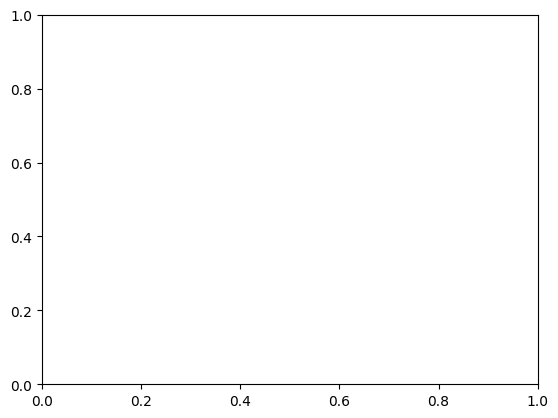

In [13]:
# Plotting log(MSE) against the learning rate (log scale)
#plt.plot(np.log10(lrs), np.log(train_losses), label="Training Loss")
plt.plot(np.linspace(0, args["epochs"]), np.log(train_losses), label="Training Loss")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("log(MSE)")
plt.title("Training Loss vs. Learning Rate")
plt.grid(True)
plt.legend()
plt.show()

**EXECUTER CETTE CELLULE PUIS REDEMARRER L'ENVIRNEMENT ET REEXECUTER** 

In [45]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from scipy.integrate import quad
from numpy.fft import fftshift
from scipy.stats import norm
from scipy import stats
from scipy.stats import qmc


### 1. Characteristic Function for the Baseline Model
def characteristic_function_baseline(u, params, tau, S0, r):
    """
    Compute the characteristic function for the baseline specification 
    of the model, handling price jumps and volatility jumps.
    
    params: dict containing the model parameters (vol, jumps, etc.)
    tau: Time to maturity.
    S0: Spot price of the underlying asset.
    r: Risk-free rate.
    """
    vol, mu_j, sigma_j = params['vol'], params['mu_j'], params['sigma_j']

    # Characteristic function terms - Price and volatility jumps.
    drift = (r - 0.5 * vol ** 2) * tau
    price_jump_component = np.exp(1j * u * drift - 0.5 * u**2 * vol ** 2 * tau)

    # Handling jumps
    jump_mean = mu_j * tau
    jump_var = sigma_j ** 2 * tau

    # Jump component for small tenors
    jump_characteristic = np.exp(1j * u * jump_mean - 0.5 * u**2 * jump_var)

    return price_jump_component * jump_characteristic


### 2. SINC Fourier Pricing Method
def sinc_pricing(moneyness, tau, r, cf, strikes, params):
    """
    Pricing of options using the Fourier method with the SINC method.

    moneyness: array of moneyness (S/K)
    tau: Time to maturity
    r: Risk-free rate
    cf: Characteristic function
    strikes: Strike prices of the options
    params: Additional model parameters for volatility, jumps, etc.
    """
    N = 256  # Fourier grid points
    L = 10   # Scaling parameter for SINC method

    # Range of k_m values for Fourier integration
    k_m = np.linspace(-L, L, N)

    # Initialize price array
    option_prices = np.zeros(len(strikes))

    # Iterate over strikes
    for i, K in enumerate(strikes):
        integrand_values = []

        # Compute characteristic function at all k_m values at once (vectorized)
        cf_values = np.array([cf(k - 1j, params, tau, moneyness, r) for k in k_m])

        # Expand dimensions to match broadcasting shape of K and k_m
        cf_values = np.expand_dims(cf_values, axis=1)  # shape: (N, 1) if needed
        K = np.expand_dims(K, axis=0)  # shape: (1, ) to broadcast

        # Iterate over each k_m value
        for k_idx, k in enumerate(k_m):
            cf_value = cf_values[k_idx]

            # Compute integrand for each k_m value and corresponding K
            integrand = np.exp(-1j * k * np.log(K)) * cf_value / (1j * k)

            # Collect real part of the integrand for integration
            integrand_values.append(integrand.real)

        # Convert to numpy array for proper summation
        integrand_values = np.array(integrand_values)

        # Fix dimensions if needed for summation
        integrand_values = integrand_values.reshape(-1)

        # Use np.trapz for integration
        sinc_sum = np.trapz(integrand_values, k_m)

        # Store the option price (discounted by the risk-free rate)
        option_prices[i] = np.exp(-r * tau) * sinc_sum

    return option_prices




### 3. Data Generator for ANN using LHS and SINC Method
def bs_LHS_data_generator(n = 10**6, l_bounds = [.4, .2, .02, .01], u_bounds = [1.6, 1.1, .1, 1]):
    """
    Generates samples of call prices using Latin hypercube sampling for the ANN.
    Returns a torch float tensor of dimension (n,5) containing the inputs samples and the value of the call.
    """
    sampler = qmc.LatinHypercube(d = 4)
    sample = sampler.random(n)
    sample = qmc.scale(sample, l_bounds, u_bounds)

    # Generate prices with the new baseline model
    strikes = sample[:, 0]
    taus = sample[:, 1]
    bs_prices = sinc_pricing(strikes, taus, sample[:, 2], characteristic_function_baseline, strikes, {'vol': 0.2, 'mu_j': -0.05, 'sigma_j': 0.1}).reshape((-1, 1))
    
    bs_dataset = np.concatenate((sample, bs_prices), axis=1)

    print("------ INPUT ------")
    print("S/K.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,0]),max(bs_dataset[:,0])))
    print("Tau.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,1]),max(bs_dataset[:,1])))
    print("r............ [{:.2f} {:.2f}]".format(min(bs_dataset[:,2]),max(bs_dataset[:,2])))
    print("Sigma........ [{:.2f} {:.2f}]".format(min(bs_dataset[:,3]),max(bs_dataset[:,3])))
    print("------ OUTPUT ------")
    print("V/K.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,4]),max(bs_dataset[:,4])))

    return torch.FloatTensor(bs_dataset)


### 4. BS-ANN Architecture
class BS_ANN(nn.Module):
    def __init__(self):
        """
        Initialize BS-ANN network with four hidden layers. 
        Weight are initialized using Glorot_uniform also known as Xavier_uniform.
        """
        super(BS_ANN, self).__init__()
        # 4 layers
        self.fc1 = nn.Linear(4, 400)
        self.fc2 = nn.Linear(400, 400)
        self.fc3 = nn.Linear(400, 400)
        self.fc4 = nn.Linear(400, 400)
        self.fc5 = nn.Linear(400, 1)
        # Initialize the layer's weights
        torch.nn.init.xavier_uniform_(self.fc1.weight)
        torch.nn.init.xavier_uniform_(self.fc2.weight)
        torch.nn.init.xavier_uniform_(self.fc3.weight)
        torch.nn.init.xavier_uniform_(self.fc4.weight)
        torch.nn.init.xavier_uniform_(self.fc5.weight)

    def forward(self, x):
        """
        Forward pass of the network. 
        Relu activations are used and a linear activation in the final layer.
        """
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)
        return x.flatten()

    def train_model(self, args, device, train_loader, optimizer, epoch):
        """
        Training over train_loader batches for one epoch.
        Returns average training loss.
        """
        self.train()
        train_loss = 0
        for batch_idx, data in enumerate(train_loader):
            data, target = data[:, :-1].to(device), data[:, -1].to(device)
            optimizer.zero_grad()
            output = self(data)
            loss = F.mse_loss(output, target)
            train_loss += loss.item() * data.shape[0]
            loss.backward()
            optimizer.step()
            if batch_idx % args["log_interval"] == 0:
                print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')
        train_loss /= len(train_loader.dataset)
        return train_loss

    def test_model(self, device, test_loader):
        """
        Testing over test_loader batches for one epoch. 
        Returns average test loss.
        """
        self.eval()
        test_loss = 0
        with torch.no_grad():
            for data in test_loader:
                data, target = data[:, :-1].to(device), data[:, -1].to(device)
                output = self(data)
                test_loss += F.mse_loss(output, target, reduction='sum').item()

        test_loss /= len(test_loader.dataset)
        print(f'\nTest set: Average loss: {test_loss:.4f}')
        return test_loss


### 5. Training the Model
def train_bs_ann():
    # Setting training parameters
    args = {
        "batch_size": 1024,
        "test_batch_size": 1024,
        "epochs": 200,
        "lr": 1,
        "gamma": 1,
        "no_cuda": False,
        "log_interval": 100,
        "dry_run": False,
        "save_model": False
    }

    use_cuda = not args["no_cuda"] and torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")

    # Generate the dataset using LHS sampling and the baseline model
    bs_dataset = bs_LHS_data_generator(n=10**4)
    train_size, test_size = int(bs_dataset.shape[0] * 0.9), int(bs_dataset.shape[0] * 0.1)
    train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, test_size])

    train_loader = torch.utils.data.DataLoader(train_dataset, args["batch_size"])
    test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])

    # Model training
    model = BS_ANN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=args["lr"])
    scheduler = LambdaLR(optimizer, lr_lambda=lambda epoch: 10**(-9 + epoch*10/(args["epochs"] - 1)))

    train_losses = []
    test_losses = []
    lrs = []
    # Training loop over epochs
    for epoch in range(1, args["epochs"] + 1):
        print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
        lrs.append(scheduler.get_last_lr())
        train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
        test_loss = model.test_model(device, test_loader)
        scheduler.step()
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        if args["save_model"] & (epoch % 10**3) ==0:
            torch.save(model.state_dict(), "BS_ANN"+str(epoch)+".pt")


In [46]:
train_bs_ann()

ValueError: operands could not be broadcast together with shapes (255,) (2559999,) 

In [34]:
import numpy as np
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from scipy.integrate import quad
from numpy.fft import fftshift
from scipy.stats import norm

In [12]:
# Basic imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Updating scipy to use module QMC for Latin hypercube sampling
#!pip install scipy==1.7
from scipy.stats import qmc

# Pytorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR, LinearLR, OneCycleLR, LambdaLR

In [48]:
def characteristic_function_baseline(u, params, tau, S0, r):
    """
    Compute the characteristic function for the baseline specification 
    of the model, handling price jumps and volatility jumps.
    
    params: dict containing the model parameters, like vol, jumps, etc.
    tau: Time to maturity.
    S0: Spot price of the underlying asset.
    r: Risk-free rate.
    """
    vol, mu_j, sigma_j = params['vol'], params['mu_j'], params['sigma_j']

    # Characteristic function terms - Price and volatility jumps.
    drift = (r - 0.5 * vol ** 2) * tau
    price_jump_component = np.exp(1j * u * drift - 0.5 * u**2 * vol ** 2 * tau)

    # Handling jumps
    jump_mean = mu_j * tau
    jump_var = sigma_j ** 2 * tau

    # Jump component for small tenors
    jump_characteristic = np.exp(1j * u * jump_mean - 0.5 * u**2 * jump_var)

    return price_jump_component * jump_characteristic

In [57]:
import numpy as np

def sinc_pricing(moneyness, tau, r, cf, strikes, params):
    """
    Pricing of options using the Fourier method with the SINC method.

    moneyness: array of moneyness (S/K)
    tau: Time to maturity
    r: Risk-free rate
    cf: Characteristic function
    strikes: Strike prices of the options
    params: Additional model parameters for volatility, jumps, etc.
    """
    N = 256  # Number of Fourier grid points
    L = 10   # Scaling parameter for SINC method

    # Range of k_m values for Fourier integration
    k_m = np.linspace(-L, L, N)

    # Initialize price array
    option_prices = np.zeros(len(strikes))

    # Iterate over strikes
    for i, K in enumerate(strikes):
        integrand_values = []

        # Compute characteristic function at all k_m values at once (vectorized)
        cf_values = np.array([cf(k - 1j, params, tau, moneyness, r) for k in k_m])

        # Adjust cf_values shape to (N, 1000000) by removing the second dimension
        cf_values = cf_values.reshape(N, -1)  # Shape: (256, 1000000)

        # Print out the shapes of the arrays
        print(f"Shape of cf_values: {cf_values.shape}")

        # Ensure K is expanded correctly
        K_array = np.full(cf_values.shape[0], K)  # shape: (256,)

        # Print shape of K
        print(f"Shape of K: {K_array.shape}")

        # Iterate over each k_m value
        for k_idx, k in enumerate(k_m):
            cf_value = cf_values[k_idx]

            # Compute integrand for each k_m value and corresponding K
            integrand = np.exp(-1j * k * np.log(K_array)) * cf_value / (1j * k)

            # Collect real part of the integrand for integration
            integrand_values.append(integrand.real)

        # Convert to numpy array for proper summation
        integrand_values = np.array(integrand_values)

        # Print the shape of integrand_values
        print(f"Shape of integrand_values: {integrand_values.shape}")

        # Use np.trapz for integration
        sinc_sum = np.trapz(integrand_values, k_m)

        # Store the option price (discounted by the risk-free rate)
        option_prices[i] = np.exp(-r * tau) * sinc_sum

    return option_prices


In [61]:
strikes = np.array([0.5, 0.6, 0.7])  # Example strikes
moneyness = 0.6  # Example moneyness
tau = 0.1  # Example time to maturity
r = 0.05  # Example risk-free rate
params = {}  # Your parameters for the characteristic function

option_prices = sinc_pricing(moneyness, tau, r, cf, strikes, params)
print(f"Calculated Option Prices: {option_prices}")


NameError: name 'cf' is not defined

In [59]:
def bs_LHS_data_generator(n = 10**6, l_bounds = [.4, .2, .02, .01], u_bounds = [1.6, 1.1, .1, 1]):
    """
    Generates samples of call prices using Latin hypercube sampling for the ANN.
    Returns a torch float tensor of dimension (n,5) containig the inputs samples and the value of the call.
    """
    sampler = qmc.LatinHypercube(d = 4)
    sample = sampler.random(n)
    sample = qmc.scale(sample, l_bounds, u_bounds)

    # Generate prices with the new baseline model
    strikes = sample[:, 0]
    taus = sample[:, 1]
    bs_prices = sinc_pricing(strikes, taus, sample[:, 2], characteristic_function_baseline, strikes, {'vol': 0.2, 'mu_j': -0.05, 'sigma_j': 0.1}).reshape((-1, 1))
    
    bs_dataset = np.concatenate((sample, bs_prices), axis=1)

    print("------ INPUT ------")
    print("S/K.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,0]),max(bs_dataset[:,0])))
    print("Tau.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,1]),max(bs_dataset[:,1])))
    print("r............ [{:.2f} {:.2f}]".format(min(bs_dataset[:,2]),max(bs_dataset[:,2])))
    print("Sigma........ [{:.2f} {:.2f}]".format(min(bs_dataset[:,3]),max(bs_dataset[:,3])))
    print("------ OUTPUT ------")
    print("V/K.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,4]),max(bs_dataset[:,4])))

    return torch.FloatTensor(bs_dataset)

bs_dataset = bs_LHS_data_generator()

Shape of cf_values: (256, 1000000)
Shape of K: (256,)


ValueError: operands could not be broadcast together with shapes (256,) (1000000,) 

In [38]:
class BS_ANN(nn.Module):
    def __init__(self):
        """
        Initialize BS-ANN network with four hidden layers. 
        Weight are initialized using Glorot_uniform also known as Xavier_uniform.
        """
        super(BS_ANN, self).__init__()
        # 4 layers
        self.fc1 = nn.Linear(4, 400)
        self.fc2 = nn.Linear(400, 400)
        self.fc3 = nn.Linear(400, 400)
        self.fc4 = nn.Linear(400, 400)
        self.fc5 = nn.Linear(400, 1)
        # Initialize the layer's weights
        torch.nn.init.xavier_uniform_(self.fc1.weight)
        torch.nn.init.xavier_uniform_(self.fc2.weight)
        torch.nn.init.xavier_uniform_(self.fc3.weight)
        torch.nn.init.xavier_uniform_(self.fc4.weight)
        torch.nn.init.xavier_uniform_(self.fc5.weight)

    def forward(self, x):
        """
        Forward pass of the network. 
        Relu activations are used and a linear activation in the final layer.
        """
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)
        return x.flatten()

    def train_model(self, args, device, train_loader, optimizer, epoch):
        """
        Training over train_loader batches for one epoch.
        Returns average training loss.
        """
        self.train()
        train_loss = 0
        for batch_idx, data in enumerate(train_loader):
            data, target = data[:, :-1].to(device), data[:, -1].to(device)
            optimizer.zero_grad()
            output = self(data)
            loss = F.mse_loss(output, target)
            train_loss += loss.item() * data.shape[0]
            loss.backward()
            optimizer.step()
            if batch_idx % args["log_interval"] == 0:
                print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')
        train_loss /= len(train_loader.dataset)
        return train_loss

    def test_model(self, device, test_loader):
        """
        Testing over test_loader batches for one epoch. 
        Returns average test loss.
        """
        self.eval()
        test_loss = 0
        with torch.no_grad():
            for data in test_loader:
                data, target = data[:, :-1].to(device), data[:, -1].to(device)
                output = self(data)
                test_loss += F.mse_loss(output, target, reduction='sum').item()

        test_loss /= len(test_loader.dataset)
        print(f'\nTest set: Average loss: {test_loss:.4f}')
        return test_loss

In [39]:
def train_bs_ann():
    # Setting training parameters
    args = {
        "batch_size": 1024,
        "test_batch_size": 1024,
        "epochs": 200,
        "lr": 1,
        "gamma": 1,
        "no_cuda": False,
        "log_interval": 100,
        "dry_run": False,
        "save_model": False
    }

    use_cuda = not args["no_cuda"] and torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")

    # Generate the dataset using LHS sampling and the baseline model
    bs_dataset = bs_LHS_data_generator(n=10**4)
    train_size, test_size = int(bs_dataset.shape[0] * 0.9), int(bs_dataset.shape[0] * 0.1)
    train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, test_size])

    train_loader = torch.utils.data.DataLoader(train_dataset, args["batch_size"])
    test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])

    # Model training
    model = BS_ANN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=args["lr"])
    scheduler = LambdaLR(optimizer, lr_lambda=lambda epoch: 10**(-9 + epoch*10/(args["epochs"] - 1)))

    train_losses, test_losses

In [44]:
train_bs_ann()

ValueError: operands could not be broadcast together with shapes (255,) (2559999,) 

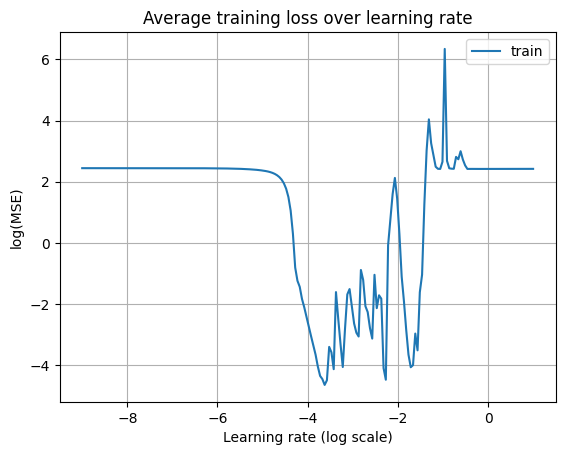

In [13]:
# Plotting the log MSE as a funtion of the learning rate
plt.plot(np.log10(lrs), np.log(train_losses), label = "train")
plt.xlabel("Learning rate (log scale)")
plt.ylabel("log(MSE)")
plt.title("Average training loss over learning rate" )
plt.grid()
plt.legend()

In [11]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print(device)

cuda


# 1) Black Scholes pricing network: BS-ANN

### Closed-form formula

In [12]:
def bs_price_call(S, K, T, t, r, sigma):
  """
  Black-Scholes call option value price related to PDE (2). Returns option's price.
  S: spot price
  K: strike price
  T: time to maturity
  t: spot time
  r: interest rate
  sigma: volatility of underlying asset
  """

  # Boundary condition of Black-Sholes PDE (2)
  if T == t:
    return np.maximum(0, S - K)  
  # Solution of the PDE (2) on the open interval [t, T)
  else : 
    d1 = ( np.log(S / K) + (r + 0.5 * sigma ** 2) * (T-t) ) / (sigma * np.sqrt(T-t))
    d2 = d1 - sigma*np.sqrt(T-t)
    value = S * norm.cdf(d1) - K * np.exp(-r * (T-t)) * norm.cdf(d2) 
  
  return value

def bs_moneyness_call(moneyness, tau, r, sigma):
  """
  Same function as bs_price_call but in terms of moneyness. Returns V/K and 
  has S/K instead of two seperate paremeters S and K.
  moneyness: S/K
  Tau: time to maturity minus spot time
  r: interest rate
  sigma: volatility of underlying asset
  """

  d1 = ( np.log(moneyness) + (r + 0.5 * sigma ** 2) * (tau) ) / (sigma * np.sqrt(tau))
  d2 = d1 - sigma*np.sqrt(tau)
  value_moneyness = moneyness * norm.cdf(d1) - np.exp(-r * (tau)) * norm.cdf(d2) 
  
  return value_moneyness

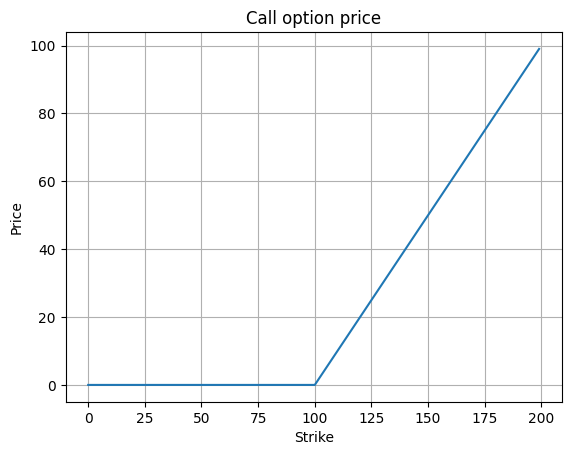

In [13]:
# Checking the call prices with respect to strikes
r, T, t, sigma, K, S = .02, 1, 1, .2, 100, np.arange(200)
plt.plot(S, bs_price_call(S, K, T, t, r, sigma))
plt.xlabel("Strike")
plt.ylabel("Price")
plt.title("Call option price" )
plt.grid()

### Data generation

In [14]:
def bs_LHS_data_generator(n = 10**6, l_bounds = [.4, .2, .02, .01], u_bounds = [1.6, 1.1, .1, 1]):
  """
  Generates samples of call prices using Latin hypercube sampling.
  Returns a torch float tensor of dimension (n,5) containig the inputs samples and the value of the call.
  The inputs are: Moneyness (S/K), time to maturity (tau), Risk free rate (r), Volatility (sigma).
  n: number of samples.
  l_bounds: lower bound for the inputs.  
  u_bounds: upper bound for the inputs.

  """
  sampler = qmc.LatinHypercube(d = 4)
  sample = sampler.random(n)
  sample = qmc.scale(sample, l_bounds, u_bounds)
  bs_prices = bs_moneyness_call(sample[:, 0], sample[:, 1], sample[:, 2], sample[:, 3]).reshape((-1, 1))
  bs_dataset = np.concatenate((sample, bs_prices),axis=1)

  print("------ INPUT ------")
  print("S/K.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,0]),max(bs_dataset[:,0])))
  print("Tau.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,1]),max(bs_dataset[:,1])))
  print("r............ [{:.2f} {:.2f}]".format(min(bs_dataset[:,2]),max(bs_dataset[:,2])))
  print("Sigma........ [{:.2f} {:.2f}]".format(min(bs_dataset[:,3]),max(bs_dataset[:,3])))
  print("------ OUTPUT ------")
  print("V/K.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,4]),max(bs_dataset[:,4])))


  return torch.FloatTensor(bs_dataset)

# Testing the function
bs_dataset = bs_LHS_data_generator()

------ INPUT ------
S/K.......... [0.40 1.60]
Tau.......... [0.20 1.10]
r............ [0.02 0.10]
Sigma........ [0.01 1.00]
------ OUTPUT ------
V/K.......... [0.00 0.90]


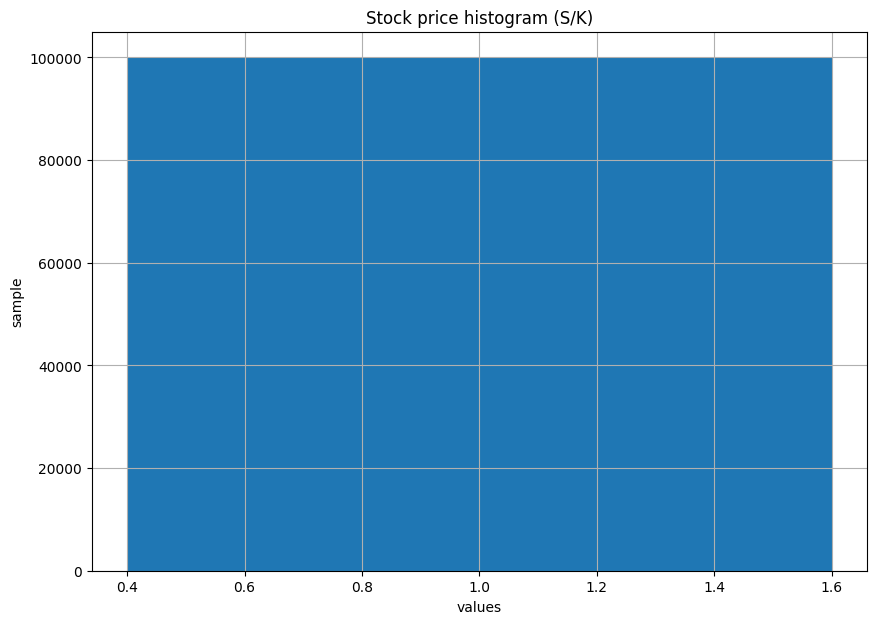

In [15]:
# Checking the LHS distribution of the input
plt.figure(figsize=(10,7))
h = plt.hist(bs_dataset[:,0], bins= 10)
plt.xlabel("values")
plt.ylabel("sample")
plt.title("Stock price histogram (S/K)" )
plt.grid()

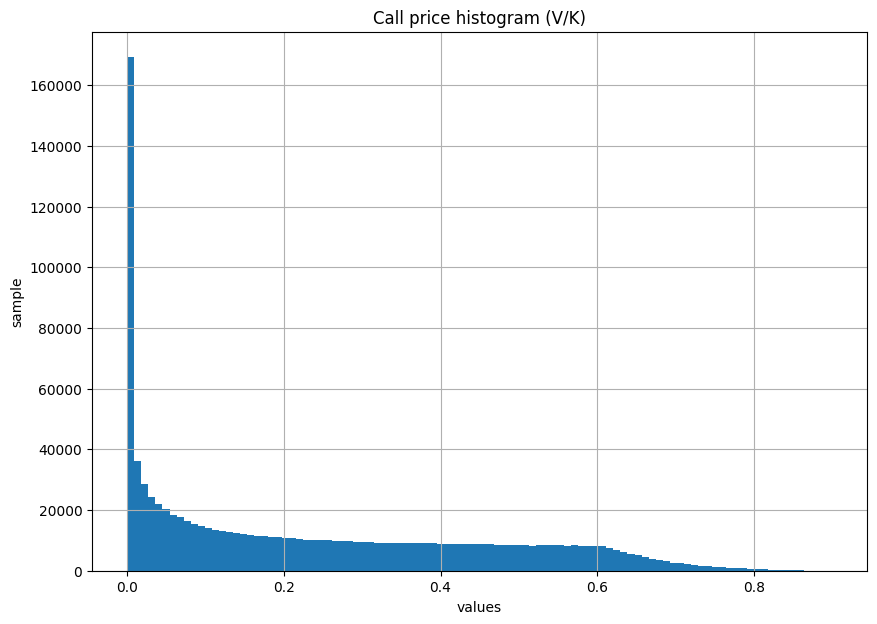

In [16]:
# Checking the output distribution (V/K).
plt.figure(figsize=(10,7))
h = plt.hist(bs_dataset[:,-1],bins=100)
plt.xlabel("values")
plt.ylabel("sample")
plt.title("Call price histogram (V/K)" )
plt.grid()

**Remark:** The majority of option prices are below 0.01

### Defining class BS-ANN

### Search of optimal Learning rate interval

**Remark:** it seems like the best interval is from $10^{-4}$ to $10^{-6}$

Training WIDE 1.2428339981502956 VS in the article 8.04e-09


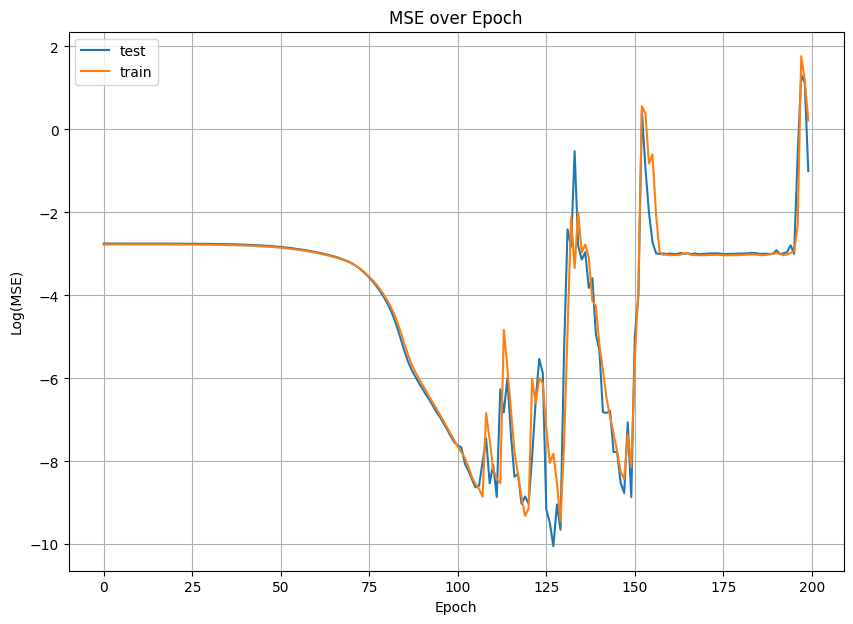

In [20]:
# ADDED CODE BOX
# Plotting the Log(MSE) with respect to the epoch
plt.figure(figsize=(10,7))
plt.plot( np.log(test_losses), label = "test")
plt.plot( np.log(train_losses), label = "train")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Log(MSE)")
plt.title("MSE over Epoch" )
plt.grid()
print("Training WIDE {} VS in the article 8.04e-09".format(train_losses[-1]) )

### Training BS-ANN with DecayLR from $10^{-4}$ to $10^{-6}$ Wide dataset

In [11]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 3*10**3,
         "lr": 1e-4,
         "gamma": .1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}



use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])


# Loading Train / Test Data
bs_dataset = bs_LHS_data_generator(n = 10**5)
train_size, test_size = int(bs_dataset.shape[0]*0.9), int(bs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_dataset,args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])



print(device)
model = BS_ANN().to(device)
# Adam is found to be the best optimizer in the article
optimizer = optim.Adam(model.parameters(), lr = args["lr"]) 
# Deacreses the Learning rate by .1 every 1000 epoch
scheduler = StepLR(optimizer, step_size=10**3, gamma=args["gamma"]) 

train_losses = []
test_losses = []
# Training loop
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "BS_ANN.pt")
    

------ INPUT ------
S/K.......... [0.40 1.60]
Tau.......... [0.20 1.10]
r............ [0.02 0.10]
Sigma........ [0.01 1.00]
------ OUTPUT ------
V/K.......... [0.00 0.89]
cuda
Train Epoch: 1 [0/90000 (0%)]	log Loss: -1.878099

Train set: Average log loss: -3.9773


Test set: Average loss: -6.4762

Current Learning rate 0.0001
Train Epoch: 2 [0/90000 (0%)]	log Loss: -6.488426

Train set: Average log loss: -7.1410


Test set: Average loss: -7.7887

Current Learning rate 0.0001
Train Epoch: 3 [0/90000 (0%)]	log Loss: -7.836579

Train set: Average log loss: -8.2131


Test set: Average loss: -8.6201

Current Learning rate 0.0001
Train Epoch: 4 [0/90000 (0%)]	log Loss: -8.637086

Train set: Average log loss: -8.9441


Test set: Average loss: -9.3021

Current Learning rate 0.0001
Train Epoch: 5 [0/90000 (0%)]	log Loss: -9.280575

Train set: Average log loss: -9.6135


Test set: Average loss: -9.9635

Current Learning rate 0.0001
Train Epoch: 6 [0/90000 (0%)]	log Loss: -9.906272

Train set: Av

Training WIDE 2.3003252494251886e-08 VS in the article 8.04e-09


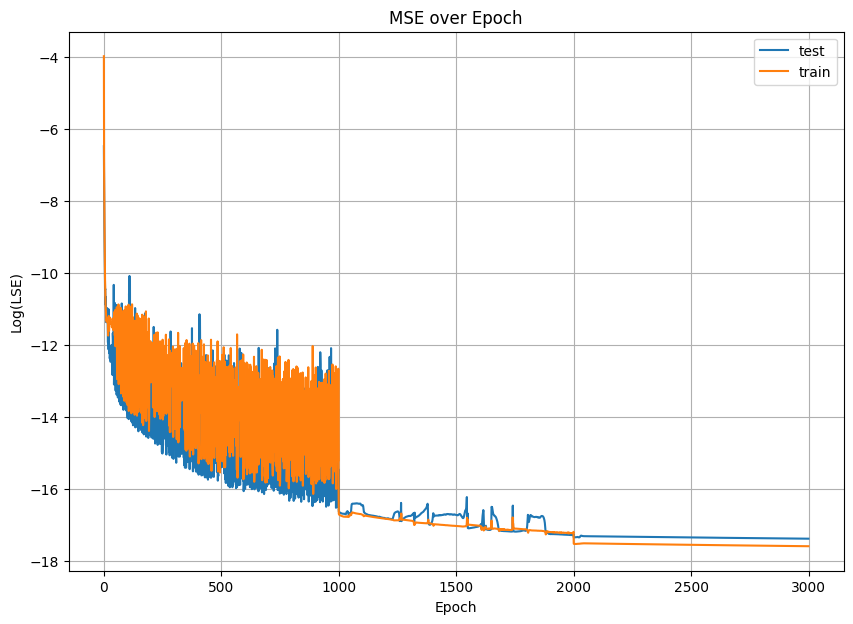

In [12]:
# Plotting the Log(MSE) with respect to the epoch
plt.figure(figsize=(10,7))
plt.plot( np.log(test_losses), label = "test")
plt.plot( np.log(train_losses), label = "train")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Log(MSE)")
plt.title("MSE over Epoch" )
plt.grid()
print("Training WIDE {} VS in the article 8.04e-09".format(train_losses[-1]) )

In [8]:
# Loading model from saved parameters
loaded_BS_ANN = BS_ANN().to(device)
PATH = "ANN_weights/BS_ANN.pt"
loaded_BS_ANN.load_state_dict(torch.load(PATH))
loaded_BS_ANN.eval()


BS_ANN(
  (fc1): Linear(in_features=4, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=400, bias=True)
  (fc5): Linear(in_features=400, out_features=1, bias=True)
)

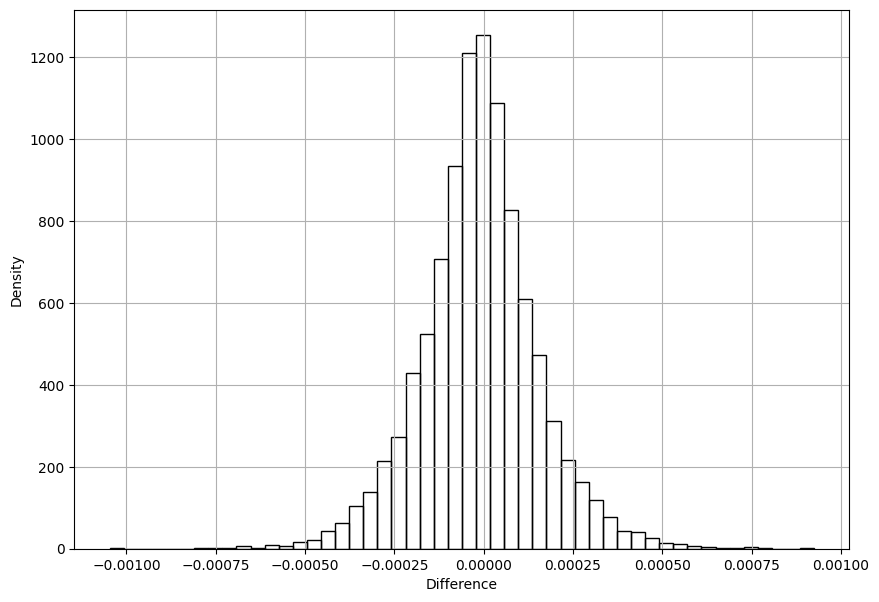

MAX  0.00092506036
MIN  -0.0010469928


In [14]:
# Plotting erros histogram
errors = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    errors.append((target-output).data.cpu().numpy())
  errors = np.concatenate(errors)
plt.figure(figsize=(10,7))
plt.hist(errors, 50, fill=False)
plt.grid()
plt.xlabel("Difference")
plt.ylabel("Density")
plt.show()
print("MAX ",errors.max())
print("MIN ",errors.min())


In [15]:
# Printing train and test MSE, MAE, MAPE and R2
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Train scores----------------
MSE 2.652397e-08
MAE 1.207284e-04
MAPE 1.947651e-01
R2 9.999994e-01
-----------Test scores----------------
MSE 2.647280e-08
MAE 1.212164e-04
MAPE 1.242439e-01
R2 9.999995e-01


In [16]:
np.sqrt(2.597518e-08)

0.00016116817303673826

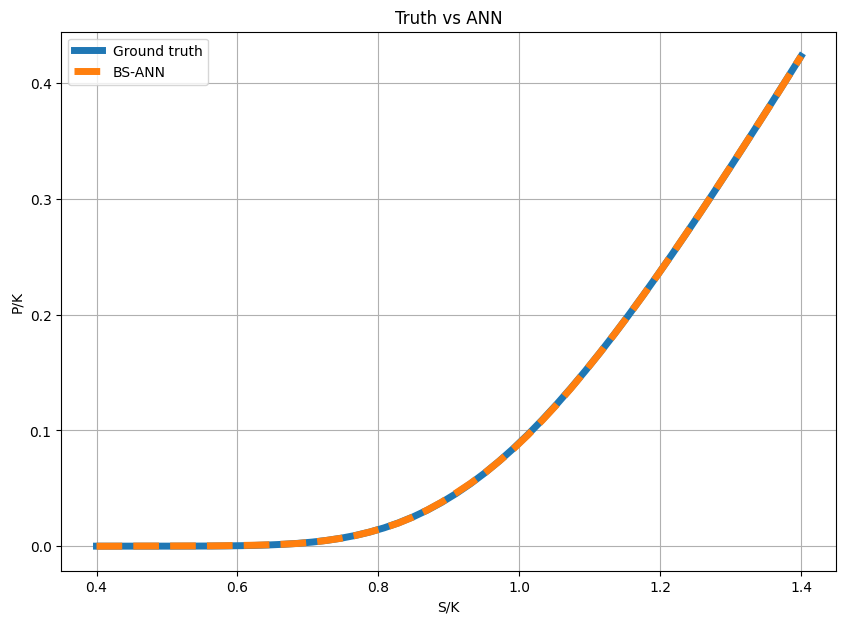

In [18]:
# Replace this with a matrix
moneyness = np.linspace(0.4,1.4)
tau, r, sigma = 1, .02, .2
prices = bs_moneyness_call(moneyness, tau, r, sigma)

plot_dateset = np.ones((50,4))
plot_dateset[:,0] = moneyness
plot_dateset[:,1] = plot_dateset[:,1]*tau
plot_dateset[:,2] = plot_dateset[:,2]*r
plot_dateset[:,3] = plot_dateset[:,3]*sigma


plt.figure(figsize=(10,7))
plt.plot(moneyness, prices, label="Ground truth", linewidth=5 )


plot_dateset = torch.from_numpy(plot_dateset).type(torch.FloatTensor).to(device)
output = loaded_BS_ANN(plot_dateset)
plt.plot(moneyness, output.data.cpu().numpy(), "--", label="BS-ANN", linewidth=5)

plt.legend()
plt.xlabel("S/K (moneyness)")
plt.ylabel("P/K")
plt.title("Truth vs ANN" )
plt.grid()

### Training BS-ANN with DecayLR from $10^{-4}$ to $10^{-6}$ Narrow dataset 

In [19]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 3*10**3,
         "lr": 1e-4,
         "gamma": .1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}



use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])


# Loading Train / Test Data
l_bounds = [.5, .3, .03, .02]
u_bounds = [1.5, .95, .08, .9]
bs_dataset = bs_LHS_data_generator(n = 10**5,l_bounds=l_bounds, u_bounds=u_bounds)
train_size, test_size = int(bs_dataset.shape[0]*0.9), int(bs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_dataset,args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])



print(device)
model = BS_ANN().to(device)
# Adam is found to be the best optimizer in the article
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) 
# Deacreses the Learning rate by .1 every 1000 epoch
scheduler = StepLR(optimizer, step_size=10**3, gamma=args["gamma"]) 

train_losses = []
test_losses = []
# Training loop
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "BS_ANN_narrow.pt")
    

------ INPUT ------
S/K.......... [0.50 1.50]
Tau.......... [0.30 0.95]
r............ [0.03 0.08]
Sigma........ [0.02 0.90]
------ OUTPUT ------
V/K.......... [0.00 0.73]
cuda
Train Epoch: 1 [0/90000 (0%)]	log Loss: -2.623463

Train set: Average log loss: -4.5871


Test set: Average loss: -6.9200

Current Learning rate 0.0001
Train Epoch: 2 [0/90000 (0%)]	log Loss: -6.930228

Train set: Average log loss: -7.5880


Test set: Average loss: -8.3521

Current Learning rate 0.0001
Train Epoch: 3 [0/90000 (0%)]	log Loss: -8.407589

Train set: Average log loss: -8.8279


Test set: Average loss: -9.3110

Current Learning rate 0.0001
Train Epoch: 4 [0/90000 (0%)]	log Loss: -9.395084

Train set: Average log loss: -9.6382


Test set: Average loss: -9.8990

Current Learning rate 0.0001
Train Epoch: 5 [0/90000 (0%)]	log Loss: -9.922584

Train set: Average log loss: -10.1613


Test set: Average loss: -10.3838

Current Learning rate 0.0001
Train Epoch: 6 [0/90000 (0%)]	log Loss: -10.427864

Train set:

In [20]:
# Loading model from saved parameters
loaded_BS_ANN = BS_ANN().to(device)
PATH = "ANN_weights/BS_ANN_narrow.pt"
loaded_BS_ANN.load_state_dict(torch.load(PATH))
loaded_BS_ANN.eval()


BS_ANN(
  (fc1): Linear(in_features=4, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=400, bias=True)
  (fc5): Linear(in_features=400, out_features=1, bias=True)
)

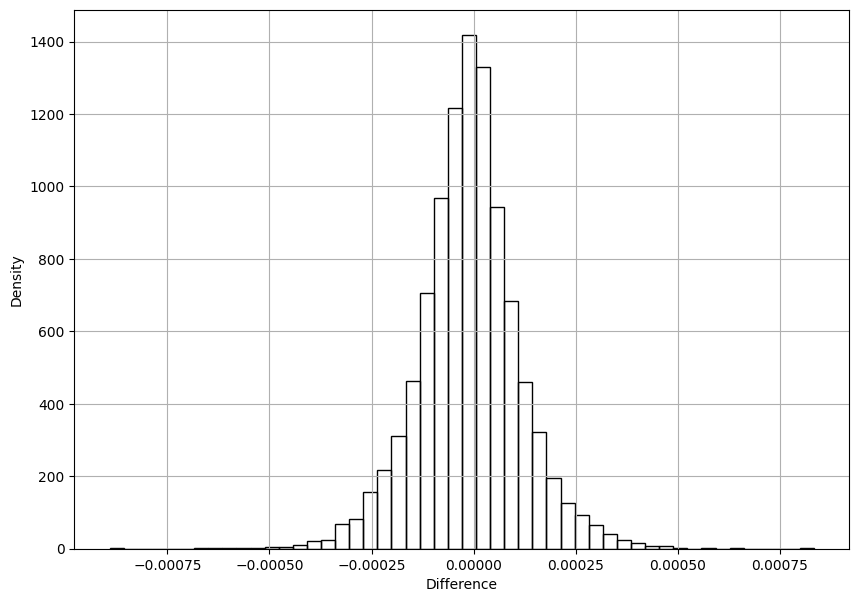

MAX  0.0008338839
MIN  -0.0008913651


In [21]:
# Plotting erros histogram
errors = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    errors.append((target-output).data.cpu().numpy())
  errors = np.concatenate(errors)
plt.figure(figsize=(10,7))
plt.hist(errors,50,fill=False)
plt.grid()
plt.xlabel("Difference")
plt.ylabel("Density")
plt.show()
print("MAX ",errors.max())
print("MIN ",errors.min())


In [22]:
# Printing train and test MSE, MAE, MAPE and R2
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Train scores----------------
MSE 1.578677e-08
MAE 9.406319e-05
MAPE 9.084946e-02
R2 9.999995e-01
-----------Test scores----------------
MSE 1.529350e-08
MAE 9.230250e-05
MAPE 9.723768e-02
R2 9.999995e-01


In [23]:
np.sqrt(1.554532e-08)

0.00012468087263088913

# 2) Implied volatility network: IV-ANN

### Defining class IV-ANN 

In [25]:
class IV_ANN(BS_ANN):
    # The authors of the paper seem to use
    # the same architecture both for BS-ANN and the IV-ANN
    # thus the class inherets from BS_ANN
  pass

### Data Generation with log transformation

Log transformation 

$\tilde{V}=V_{t}-\max \left(S_{t}-K e^{-r \tau}, 0\right)$

$\left\{\log (\tilde{V} / K), S_{0} / K, r, \tau\right\}$

In [26]:
def IV_LHS_data_generator(n = 10**6, l_bounds = [.5, .05, .0, .05], u_bounds = [1.4, 1, .1, 1], log_scale = True):
  """
  Generates samples of call prices using Latin hypercube sampling.
  Returns a torch float tensor of dimension (n,5) containig the inputs samples and the volatility as the target.
  Performs a log transormation of V/K.
  The inputs are: Moneyness (S/K), time to maturity (tau), Risk free rate (r), Volatility (sigma).
  n: number of samples.
  l_bounds: lower bound for the inputs.  
  u_bounds: upper bound for the inputs.
  log_scale: performs log transformation if True.

  """
  sampler = qmc.LatinHypercube(d=4)
  sample = sampler.random(n)
  sample = qmc.scale(sample, l_bounds, u_bounds)
  bs_prices = bs_moneyness_call(sample[:,0], sample[:,1], sample[:,2], sample[:,3]).reshape((-1,1))


  bs_dataset = np.concatenate((sample[:,:-1], bs_prices, sample[:,3].reshape((n,1))),axis=1)
  # log transformation as in section 4.3
  if log_scale : 
    bs_dataset[:,3] = bs_dataset[:,3] - np.maximum(bs_dataset[:,0]-np.exp(-bs_dataset[:,1]*bs_dataset[:,2]),0)
    indecies = np.argwhere(bs_dataset[:,3]< 1e-7)
    bs_dataset = np.delete(bs_dataset, indecies,0)
    bs_dataset[:,3] = np.log(bs_dataset[:,3])

  print("------ INPUT ------")
  print("S/K.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,0]),max(bs_dataset[:,0])))
  print("Tau.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,1]),max(bs_dataset[:,1])))
  print("r............ [{:.2f} {:.2f}]".format(min(bs_dataset[:,2]),max(bs_dataset[:,2])))
  if log_scale : 
    print("log(V/K)..... [{:.2f} {:.2f}]".format(min(bs_dataset[:,3]),max(bs_dataset[:,3])))
  else : 
    print("V/K.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,3]),max(bs_dataset[:,3])))
  print("------ OUTPUT ------")
  print("Sigma........ [{:.2f} {:.2f}]".format(min(bs_dataset[:,4]),max(bs_dataset[:,4])))
  return torch.FloatTensor(bs_dataset)

bs_dataset = IV_LHS_data_generator(log_scale = True)

------ INPUT ------
S/K.......... [0.50 1.40]
Tau.......... [0.05 1.00]
r............ [0.00 0.10]
log(V/K)..... [-16.12 -0.99]
------ OUTPUT ------
Sigma........ [0.05 1.00]


### Training IV-ANN with log transofmation

In [27]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 3*10**3,
         "lr": 1e-4,
         "gamma": .1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}



use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])

# Loading Train / Test Data
bs_dataset = IV_LHS_data_generator(n = 10**5, log_scale = True)
train_size, test_size = int(bs_dataset.shape[0]*0.9), int(bs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, bs_dataset.shape[0]-train_size])

train_loader = torch.utils.data.DataLoader(train_dataset,args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])


# Model training
print(device)
model = IV_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) # Adam is found to be the best optimizer in the article
scheduler = StepLR(optimizer, step_size=10**3, gamma=args["gamma"]) # Deacreses the Learning rate by .1 every 1000 epoch

train_losses = []
test_losses = []
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "IV_SCALED_ANN.pt")
    

------ INPUT ------
S/K.......... [0.50 1.40]
Tau.......... [0.05 1.00]
r............ [0.00 0.10]
log(V/K)..... [-16.12 -0.99]
------ OUTPUT ------
Sigma........ [0.05 1.00]
cuda
Train Epoch: 1 [0/85187 (0%)]	log Loss: -0.671939

Train set: Average log loss: -2.8045


Test set: Average loss: -3.6490

Current Learning rate 0.0001
Train Epoch: 2 [0/85187 (0%)]	log Loss: -3.637234

Train set: Average log loss: -3.8461


Test set: Average loss: -4.0413

Current Learning rate 0.0001
Train Epoch: 3 [0/85187 (0%)]	log Loss: -4.062339

Train set: Average log loss: -4.2294


Test set: Average loss: -4.4881

Current Learning rate 0.0001
Train Epoch: 4 [0/85187 (0%)]	log Loss: -4.476239

Train set: Average log loss: -4.8251


Test set: Average loss: -5.2713

Current Learning rate 0.0001
Train Epoch: 5 [0/85187 (0%)]	log Loss: -5.229585

Train set: Average log loss: -5.6174


Test set: Average loss: -5.9795

Current Learning rate 0.0001
Train Epoch: 6 [0/85187 (0%)]	log Loss: -5.890696

Train set:

In [29]:
# Loading model from saved weights
device = torch.device("cuda")
loaded_IV_ANN = IV_ANN().to(device)
PATH = "ANN_weights/IV_SCALED_ANN.pt"
loaded_IV_ANN.load_state_dict(torch.load(PATH))
loaded_IV_ANN.eval()


IV_ANN(
  (fc1): Linear(in_features=4, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=400, bias=True)
  (fc5): Linear(in_features=400, out_features=1, bias=True)
)

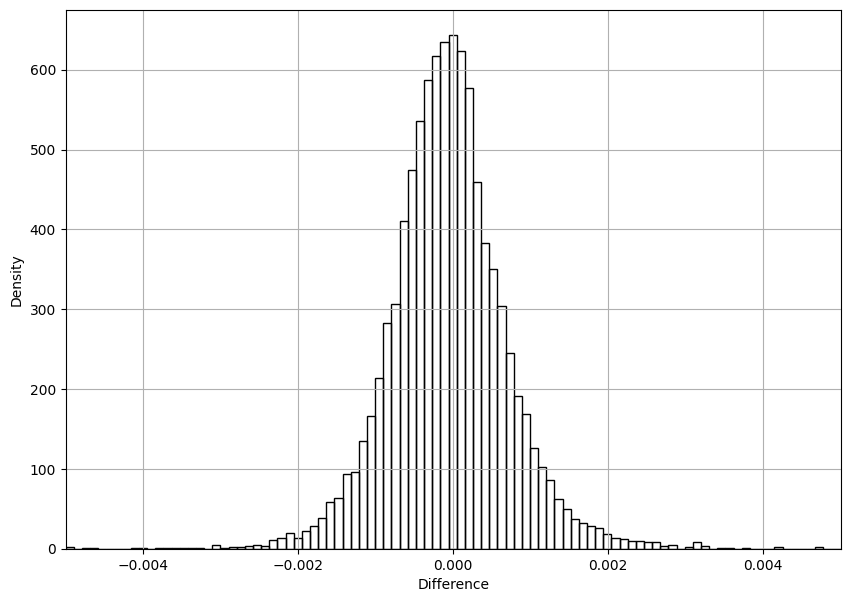

MAX  0.005511403
MIN  -0.0050005317


In [30]:
# Plotting erros histogram
errors = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN(data)
    errors.append((target-output).data.cpu().numpy())
  errors = np.concatenate(errors)
plt.figure(figsize=(10,7))
plt.hist(errors,100,fill=False)
plt.grid()
plt.xlabel("Difference")
plt.ylabel("Density")
plt.xlim([-0.005, 0.005])
plt.show()
print("MAX ",errors.max())
print("MIN ",errors.min())


In [31]:
# Printing train and test MSE, MAE, MAPE and R2
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Train scores----------------
MSE 6.137644e-07
MAE 5.638418e-04
MAPE 1.528163e-03
R2 9.999912e-01
-----------Test scores----------------
MSE 5.863549e-07
MAE 5.648760e-04
MAPE 1.545854e-03
R2 9.999915e-01


### Training IV-ANN without log transofmation

In [32]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 3*10**3,
         "lr": 1e-4,
         "gamma": .1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}



use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])


# Train / Test Data
bs_dataset = IV_LHS_data_generator(n = 10**5, log_scale = False)
train_size, test_size = int(bs_dataset.shape[0]*0.9), int(bs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, bs_dataset.shape[0]-train_size])

train_loader = torch.utils.data.DataLoader(train_dataset,args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])


# Model training
print(device)
model = BS_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) # Adam is found to be the best optimizer in the article
scheduler = StepLR(optimizer, step_size=10**3, gamma=args["gamma"]) # Deacreses the Learning rate by .1 every 1000 epoch

train_losses = []
test_losses = []
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "IV_UNSCALED_ANN.pt")
    

------ INPUT ------
S/K.......... [0.50 1.40]
Tau.......... [0.05 1.00]
r............ [0.00 0.10]
V/K.......... [0.00 0.69]
------ OUTPUT ------
Sigma........ [0.05 1.00]
cuda
Train Epoch: 1 [0/90000 (0%)]	log Loss: -0.959341

Train set: Average log loss: -2.4540


Test set: Average loss: -2.6480

Current Learning rate 0.0001
Train Epoch: 2 [0/90000 (0%)]	log Loss: -2.619602

Train set: Average log loss: -2.7389


Test set: Average loss: -2.9221

Current Learning rate 0.0001
Train Epoch: 3 [0/90000 (0%)]	log Loss: -2.905974

Train set: Average log loss: -3.2516


Test set: Average loss: -3.6121

Current Learning rate 0.0001
Train Epoch: 4 [0/90000 (0%)]	log Loss: -3.637082

Train set: Average log loss: -3.8467


Test set: Average loss: -4.0643

Current Learning rate 0.0001
Train Epoch: 5 [0/90000 (0%)]	log Loss: -4.068975

Train set: Average log loss: -4.2036


Test set: Average loss: -4.3170

Current Learning rate 0.0001
Train Epoch: 6 [0/90000 (0%)]	log Loss: -4.306699

Train set: Av

In [33]:
# Loading model
device = torch.device("cuda")
loaded_IV_ANN_UN = IV_ANN().to(device)
PATH = "ANN_weights/IV_UNSCALED_ANN.pt"
loaded_IV_ANN_UN.load_state_dict(torch.load(PATH))
loaded_IV_ANN_UN.eval()


IV_ANN(
  (fc1): Linear(in_features=4, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=400, bias=True)
  (fc5): Linear(in_features=400, out_features=1, bias=True)
)

MAX  0.23030132
MIN  -0.44819307


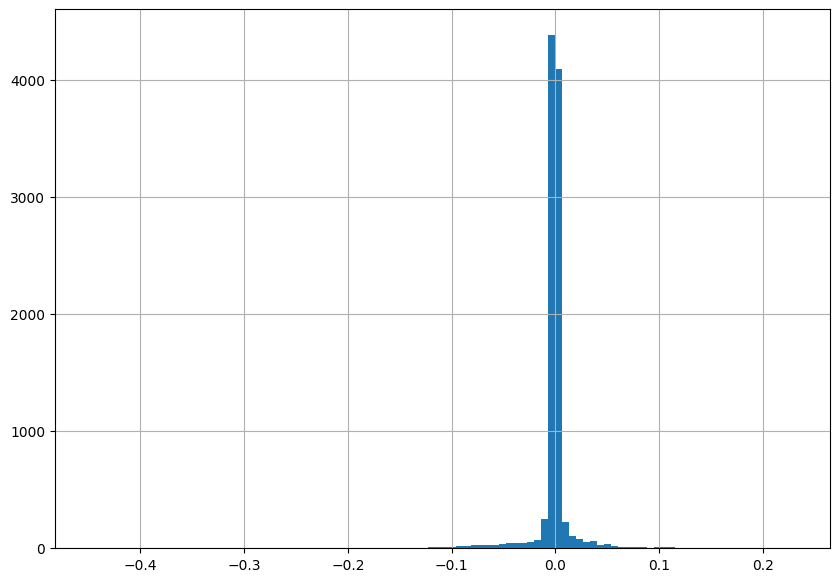

In [34]:
# Plotting erros histogram
errors = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN_UN(data)
    errors.append((target-output).data.cpu().numpy())
  errors = np.concatenate(errors)
plt.figure(figsize=(10,7))
h = plt.hist(errors,100)
plt.grid()
print("MAX ",errors.max())
print("MIN ",errors.min())


In [35]:
# Printing train and test MSE, MAE, MAPE and R2
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN_UN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN_UN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Train scores----------------
MSE 6.599748e-04
MAE 8.277198e-03
MAPE 3.761932e-02
R2 9.910348e-01
-----------Test scores----------------
MSE 6.838114e-04
MAE 8.216325e-03
MAPE 3.740349e-02
R2 9.906515e-01


# 3) COS Method

#### Vanilla call coefficients

$\begin{aligned} \chi_{k}(c, d):=& \frac{1}{1+\left(\frac{k \pi}{b-a}\right)^{2}}\left[\cos \left(k \pi \frac{d-a}{b-a}\right) e^{d}-\cos \left(k \pi \frac{c-a}{b-a}\right) e^{c}\right.\\ &\left.+\frac{k \pi}{b-a} \sin \left(k \pi \frac{d-a}{b-a}\right) e^{d}-\frac{k \pi}{b-a} \sin \left(k \pi \frac{c-a}{b-a}\right) e^{c}\right] \end{aligned}$

$\psi_{k}(c, d):= \begin{cases}{\left[\sin \left(k \pi \frac{d-a}{b-a}\right)-\sin \left(k \pi \frac{c-a}{b-a}\right)\right] \frac{b-a}{k \pi},} & k \neq 0, \\ (d-c), & k=0 .\end{cases}$

$V_{k}^{\text {call }}=\frac{2}{b-a} K\left(\chi_{k}(0, b)-\psi_{k}(0, b)\right)$

In [36]:
def call_cosine_coef(a, b, c, d, K, N):
  """
  Coefficient V_k for plain vanilla options. 
  Section 3.1, equations (22) and (23).
  a, b, c, d: truncation range parameters.
  K: Strike.
  N: summing lenght.
  Returns V_k coefficient for call option.
  """
  k = np.arange(N).reshape(1,-1)
  bma    = b - a
  uu     = k * np.pi / bma
  chi_k = 1 / (1 + uu **2 ) * \
  ( np.cos(uu * ( d - a))* np.exp(d) - np.cos(uu * (c - a))* np.exp(c) + uu * np.sin(uu * (d - a)) * np.exp(d)- uu * np.sin(uu*(c-a))* np.exp(c) )
  psi_k = uu
  psi_k[:,1:] = 1 / uu[:,1:] * ( np.sin(uu[:,1:] * ( d - a )) - np.sin( uu[:,1:] * ( c - a) ) )
  psi_k[:,0] = (d - c).flatten() #d - c 
  return 2/bma*K*(chi_k-psi_k)

In [37]:
def call_cosine_coef_moy(a, b, c, d, N):
  """
  Moyeness version.
  Coefficient V_k for plain vanilla options. 
  Section 3.1, equations (22) and (23).
  a, b, c, d: truncation range parameters.
  N: summing lenght.
  Returns V_k coefficient for call option devided by K.
  """
  k = np.arange(N).reshape(1,-1)
  bma    = b - a
  uu     = k * np.pi / bma
  chi_k = 1 / (1 + uu **2 ) * \
  ( np.cos(uu * ( d - a))* np.exp(d) - np.cos(uu * (c - a))* np.exp(c) + uu * np.sin(uu * (d - a)) * np.exp(d)- uu * np.sin(uu*(c-a))* np.exp(c) )
  psi_k = uu
  psi_k[:,1:] = 1 / uu[:,1:] * ( np.sin(uu[:,1:] * ( d - a )) - np.sin( uu[:,1:] * ( c - a) ) )
  psi_k[:,0] = (d - c).flatten() #d - c 
  return 2/bma*(chi_k-psi_k)

#### Charateristic function for Heston model

$\begin{aligned} \varphi_{h e s}\left(\omega ; u_{0}\right)=& \exp \left(i \omega \mu \Delta t+\frac{u_{0}}{\eta^{2}}\left(\frac{1-e^{-D \Delta t}}{1-G e^{-D \Delta t}}\right)(\lambda-i \rho \eta \omega-D)\right) \\ & \cdot \exp \left(\frac{\lambda \bar{u}}{\eta^{2}}\left(\Delta t(\lambda-i \rho \eta \omega-D)-2 \log \left(\frac{1-G e^{-D \Delta t}}{1-G}\right)\right)\right) \end{aligned}$

$D=\sqrt{(\lambda-i \rho \eta \omega)^{2}+\left(\omega^{2}+i \omega\right) \eta^{2}} \quad$ and $\quad G=\frac{\lambda-i \rho \eta \omega-D}{\lambda-i \rho \eta \omega+D} $

In [38]:
def phi_Heston(a ,b ,N ,r, tau, kappa, gamma, vbar, v0, rho):
  """
  Characteristic function of the log-asset price following the Heston model.
  Section 3.3, equation (33).
  a, b: truncation range parameters.
  N: summing lenght.
  r: risk free rate.
  tau: time to maturity.
  kappa: reversion speed .
  gamma: Vol of vol.
  vbar: Long average variance.
  v0: Initial variance.
  rho: Correlation.
  Returns Charateristic function vector.
  """
  k = np.arange(N).reshape(1,-1)
  u = np.pi*k/(b-a)
  i = complex(0.0,1.0)
  D = np.sqrt((kappa-gamma*rho*i*u)**2+(u**2+i*u)*gamma**2)
  G = (kappa-gamma*rho*i*u-D)/(kappa-gamma*rho*i*u+D)
  C = v0* (1-np.exp(-D*tau)) / (gamma**2*(1-G*np.exp(-D*tau)))*(kappa-gamma*rho*i*u-D)
  A = r*i*u*tau + kappa*vbar/(gamma**2)*(tau*(kappa-gamma*rho*i*u-D) -2*np.log( (1-G*np.exp(-D*tau))/(1-G) )   ) 
  phi = np.exp( A + C )
  return phi


#### Heston cumulants

$c_{1}=\mu T+\left(1-e^{-\lambda T}\right) \frac{\bar{u}-u_{0}}{2 \lambda}-\frac{1}{2} \bar{u} T$

$\begin{aligned} c_{2}=& \frac{1}{8 \lambda^{3}}\left(\eta T \lambda e^{-\lambda T}\left(u_{0}-\bar{u}\right)(8 \lambda \rho-4 \eta)\right.\\ &+\lambda \rho \eta\left(1-e^{-\lambda T}\right)\left(16 \bar{u}-8 u_{0}\right) \\ &+2 \bar{u} \lambda T\left(-4 \lambda \rho \eta+\eta^{2}+4 \lambda^{2}\right) \\ &+\eta^{2}\left(\left(\bar{u}-2 u_{0}\right) e^{-2 \lambda T}+\bar{u}\left(6 e^{-\lambda T}-7\right)+2 u_{0}\right) \\ &\left.+8 \lambda^{2}\left(u_{0}-\bar{u}\right)\left(1-e^{-\lambda T}\right)\right) \end{aligned}$

In [39]:
def Heston_cumulants( r, tau, kappa, gamma, vbar, v0, rho ):
  """
  Computes Heston cumulants as defined in the appendix A for the Heston model.
  r: risk free rate.
  tau: time to maturity.
  kappa: reversion speed .
  gamma: Vol of vol.
  vbar: Long average variance.
  v0: Initial variance.
  rho: Correlation.
  Returns cumulants c1 and c2.
  """
  c1 = r * tau + (1 - np.exp(- kappa * tau)) * (vbar - v0) / (2 * kappa) - 0.5 * vbar * tau
  
  c2 = 0.125 / kappa ** 3 * (gamma * tau * np.exp(- kappa * tau) * (v0 - vbar) * (8 * kappa * rho - 4 * gamma) + \
     kappa * rho * gamma * (1 - np.exp(- kappa * tau)) * (16 * vbar - 8 * v0) + \
     2 * vbar * kappa * tau * (- 4 * kappa * rho * gamma + gamma ** 2 + 4 * kappa ** 2) + \
     gamma ** 2 * ((vbar - 2 * v0) * np.exp(-2 * kappa * tau) + vbar * (6 * np.exp(- kappa * tau) - 7) + 2 * v0) + \
     8 * kappa ** 2 * (v0 - vbar) * (1 - np.exp(-kappa * tau)))
  return c1, c2

#### Truncation range

$[a, b]:=\left[c_{1}-L \sqrt{c_{2}+\sqrt{c_{4}}}, \quad c_{1}+L \sqrt{c_{2}+\sqrt{c_{4}}}\right]$

In [40]:
def Truncation_range(c1, c2, c4, L):
  """
  Computes the truncation range given the cumulants c1, c2, c4 and the truncation lenght L.
  c1, c2, c4: Model cumulants.
  L: truncation lenght.
  Returns tuncation interval sup b and inf a.
  """
  a = c1 - L * np.sqrt( np.abs( c2 ) + np.sqrt( np.abs(c4) ) )
  b = c1 + L * np.sqrt( np.abs( c2 ) + np.sqrt( np.abs(c4) ) ) 
  return a, b

#### Exponential coefficient

$e^{i k \pi \frac{\mathbf{x}-a}{b-a}}$

In [41]:
def exponential_coef(a, b, N, S0, K):
  """
  Computes the exponential coefficient used in the final pricing sum.
  a, b: truncation range.
  N: sum lenght.
  S0: asset initial price.
  K: strike.
  Returns the exponential coefficient vector.
  """
  i = complex(0.0,1.0)
  k = np.arange(N).reshape(1,-1)
  return np.exp(i*k*np.pi*(np.log(S0/K)-a)/(b-a))

In [42]:
def exponential_coef_moy(a, b, N, moyeness):
  """
  Moyeness version.
  Computes the exponential coefficient used in the final pricing sum.
  a, b: truncation range.
  N: sum lenght.
  moyeness: S/K.
  Returns the exponential coefficient vector devided by K.
  """
  i = complex(0.0,1.0)
  k = np.arange(N).reshape(1,-1)
  return np.exp(i*k*np.pi*(np.log(moyeness)-a)/(b-a))

#### Vanilla call price

$v\left(\mathbf{x}, t_{0}, u_{0}\right) \approx \mathbf{K} e^{-r \Delta t} \cdot \operatorname{Re}\left\{\sum_{k=0}^{N-1} \varphi_{h e s}\left(\frac{k \pi}{b-a} ; u_{0}\right) U_{k} \cdot e^{i k \pi \frac{\mathbf{x}-a}{b-a}}\right\}$

In [43]:
def call_option_Heston(N, L, r, tau, kappa, gamma, vbar, v0, rho, K, S0 ):
  """
  Computes call option price using COS method.
  N: sum lenght.
  L: truncation lenght.
  r: risk free rate.
  tau: time to maturity.
  kappa: reversion speed .
  gamma: Vol of vol.
  vbar: Long average variance.
  v0: Initial variance.
  rho: Correlation.
  S0: asset initial price.
  K: strike.
  Returns option price.
  """
  c1, c2 = Heston_cumulants( r, tau, kappa, gamma, vbar, v0, rho )
  c4 = 0
  a, b = Truncation_range(c1, c2, c4, L)
  c= 0
  d = b
  V_k = call_cosine_coef(a, b, c, d, K, N)
  phi_k = phi_Heston(a, b, N, r, tau, kappa, gamma, vbar, v0, rho)
  product_k = V_k * phi_k * exponential_coef(a, b, N, S0, K)
  product_k[:,0] = .5 * product_k[:,0]
  return np.exp(-r*tau)*(np.real(  np.sum( product_k,1 )  )).reshape(-1,1)

In [44]:
# cheking the function
N = 500
L= 12
r= .1
tau= 1.4
rho = -0.95
kappa= 1.4
vbar = .1
gamma = .1
v0 = 0.5
K = 100
S0 = 100
# Feller's condition
print(2*kappa*vbar>gamma**2)
call_option_Heston(N = 1500, L= 12, r= r, tau= tau, kappa= kappa, gamma = gamma, vbar = vbar, v0 = v0, rho = rho, K = K, S0 = S0)

True


array([[29.79261082]])

In [45]:
def call_option_Heston_moy(N, L, r, tau, kappa, gamma, vbar, v0, rho, moyeness ):
  """
  Moyeness version.
  Computes call option price using COS method.
  N: sum lenght.
  L: truncation lenght.
  r: risk free rate.
  tau: time to maturity.
  kappa: reversion speed .
  gamma: Vol of vol.
  vbar: Long average variance.
  v0: Initial variance.
  rho: Correlation.
  moyeness: S/K.
  Returns option price.
  """
  c1, c2 = Heston_cumulants( r, tau, kappa, gamma, vbar, v0, rho )
  c4 = 0
  a, b = Truncation_range(c1, c2, c4, L)
  c= 0
  d = b
  V_k = call_cosine_coef_moy(a, b, c, d, N)
  phi_k = phi_Heston(a, b, N, r, tau, kappa, gamma, vbar, v0, rho)
  product_k = V_k * phi_k * exponential_coef_moy(a, b, N, moyeness)
  product_k[:,0] = .5 * product_k[:,0]
  return np.exp(-r*tau)*(np.real(  np.sum( product_k,1 )  )).reshape(-1,1)

In [44]:
# cheking the function
N = 500
L= 12
r= .1
tau= 1.4
rho = -0.95
kappa= 1.4
vbar = .1
gamma = .1
v0 = 0.5
K = 100
S0 = 100
# Feller's condition
print(2*kappa*vbar>gamma**2)
call_option_Heston_moy(N = 1500, L= 12, r= r, tau= tau, kappa= kappa, gamma = gamma, vbar = vbar, v0 = v0, rho = rho, moyeness = 1)

True


array([[0.29792611]])

# 4) Heston pricing network: Heston-ANN

### Generating Data

In [46]:
eps = 1e-2 # is used to generate open intervals
def Heston_LHS_data_generator(n = 10**6, l_bounds = [.6+eps, .1+eps, .0+eps, -0.95+eps, .4+eps, .0+eps, .0+eps, .05+eps], u_bounds = [1.4-eps, 1.4-eps, .1-eps, 0.0-eps, 2.0-eps, .5-eps, .5-eps, .5-eps]):
  """
  Generates samples of call prices using Latin hypercube sampling.
  Returns a torch float tensor of dimension (n,9) containig the inputs samples and the value of the call.
  The inputs are: Moyeness (S/K), time to maturity (tau), Risk free rate (r), Correlation (rho), reversion speed (kappa), Long average variance (vbar), Vol of vol (gamma), Initial variance (v0).
  n: number of samples.
  l_bounds: lower bound for the inputs.  
  u_bounds: upper bound for the inputs.
  """
  sampler = qmc.LatinHypercube(d=8) #, seed = 0
  sample = sampler.random(n)
  sample = qmc.scale(sample, l_bounds, u_bounds)
  indecies = np.argwhere(2*sample[:,4]*sample[:,5]<= sample[:,6]**2)
  sample = np.delete(sample, indecies,0)
  # print(sample.shape)
  # print(2*kappa*vbar>gamma**2)
  hs_prices = call_option_Heston_moy(N = 160, L= 12, r= sample[:,2].reshape((-1,1)), tau= sample[:,1].reshape((-1,1)), kappa= sample[:,4].reshape((-1,1)),\
                                     gamma = sample[:,6].reshape((-1,1)), vbar = sample[:,5].reshape((-1,1)), v0 = sample[:,7].reshape((-1,1)),\
                                     rho = sample[:,3].reshape((-1,1)), moyeness = sample[:,0].reshape((-1,1))).reshape((-1,1))
  # hs_prices = call_option_Heston_moy(N = 1500, L= 50, r= sample[:,2].reshape((-1,1)), tau= sample[:,1].reshape((-1,1)), kappa= sample[:,4].reshape((-1,1)),\
  #                                    gamma = sample[:,6].reshape((-1,1)), vbar = sample[:,5].reshape((-1,1)), v0 = sample[:,7].reshape((-1,1)),\
  #                                    rho = sample[:,3].reshape((-1,1)), moyeness = sample[:,0].reshape((-1,1))).reshape((-1,1))
  
  hs_dataset = np.concatenate((sample, hs_prices),axis=1)

  print("------ INPUT ------")
  print("S/K.......... [{:.2f} {:.2f}]".format(min(hs_dataset[:,0]),max(hs_dataset[:,0])))
  print("Tau.......... [{:.2f} {:.2f}]".format(min(hs_dataset[:,1]),max(hs_dataset[:,1])))
  print("r............ [{:.2f} {:.2f}]".format(min(hs_dataset[:,2]),max(hs_dataset[:,2])))
  print("Corr ........ [{:.2f} {:.2f}]".format(min(hs_dataset[:,3]),max(hs_dataset[:,3])))
  print("Kappa........ [{:.2f} {:.2f}]".format(min(hs_dataset[:,4]),max(hs_dataset[:,4])))
  print("V_bar........ [{:.2f} {:.2f}]".format(min(hs_dataset[:,5]),max(hs_dataset[:,5])))
  print("Gamma........ [{:.2f} {:.2f}]".format(min(hs_dataset[:,6]),max(hs_dataset[:,6])))
  print("V_0 ......... [{:.2f} {:.2f}]".format(min(hs_dataset[:,7]),max(hs_dataset[:,7])))
  print("------ OUTPUT ------")
  print("V/K.......... [{:.2f} {:.2f}]".format(min(hs_dataset[:,-1]),max(hs_dataset[:,-1])))
  # ind_max = np.argmax(hs_dataset[:,-1])
  # print(hs_dataset[ind_max,:])

  return torch.FloatTensor(hs_dataset)

hs_dataset = Heston_LHS_data_generator(10**4)

------ INPUT ------
S/K.......... [0.61 1.39]
Tau.......... [0.11 1.39]
r............ [0.01 0.09]
Corr ........ [-0.94 -0.01]
Kappa........ [0.41 1.99]
V_bar........ [0.01 0.49]
Gamma........ [0.01 0.49]
V_0 ......... [0.06 0.49]
------ OUTPUT ------
V/K.......... [0.00 0.63]


### Defining class Heston-ANN

In [47]:
class Heston_ANN(BS_ANN):
  def __init__(self):
    """
    Initilize BS-Heston_ANN netwwork. Same architecture as the one used in tge article.
    Weight are initialized using Glorot_uniform also known as Xavier_uniform.
    Takes inputs of size 8.
    """
    super(Heston_ANN, self).__init__()
    self.fc1 = nn.Linear(8, 400)
    self.fc2 = nn.Linear(400, 400)
    self.fc3 = nn.Linear(400, 400)
    self.fc4 = nn.Linear(400, 400)
    self.fc5 = nn.Linear(400, 1)

    torch.nn.init.xavier_uniform_(self.fc1.weight)
    torch.nn.init.xavier_uniform_(self.fc2.weight)
    torch.nn.init.xavier_uniform_(self.fc3.weight)
    torch.nn.init.xavier_uniform_(self.fc4.weight)
    torch.nn.init.xavier_uniform_(self.fc5.weight)

### Training Heston-ANN

In [48]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 3*10**3,
         "lr": 1e-4,
         "gamma": .1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}



use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])


# Loading Train / Test Data
hs_dataset = Heston_LHS_data_generator(n = 10**5)
train_size, test_size = int(hs_dataset.shape[0]*0.9), int(hs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(hs_dataset, [train_size, hs_dataset.shape[0]-train_size])

train_loader = torch.utils.data.DataLoader(train_dataset,args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])


# Model training
print(device)
model = Heston_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) # Adam is found to be the best optimizer in the article
scheduler = StepLR(optimizer, step_size=10**3, gamma=args["gamma"]) # Deacreses the Learning rate by .1 every 1000 epoch

train_losses = []
test_losses = []
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "Heston_ANN.pt")
    

------ INPUT ------
S/K.......... [0.61 1.39]
Tau.......... [0.11 1.39]
r............ [0.01 0.09]
Corr ........ [-0.94 -0.01]
Kappa........ [0.41 1.99]
V_bar........ [0.01 0.49]
Gamma........ [0.01 0.49]
V_0 ......... [0.06 0.49]
------ OUTPUT ------
V/K.......... [0.00 0.63]
cuda
Train Epoch: 1 [0/83759 (0%)]	log Loss: -1.827268

Train set: Average log loss: -4.1918


Test set: Average loss: -6.8416

Current Learning rate 0.0001
Train Epoch: 2 [0/83759 (0%)]	log Loss: -6.777963

Train set: Average log loss: -7.6731


Test set: Average loss: -8.5627

Current Learning rate 0.0001
Train Epoch: 3 [0/83759 (0%)]	log Loss: -8.549292

Train set: Average log loss: -8.9597


Test set: Average loss: -9.2408

Current Learning rate 0.0001
Train Epoch: 4 [0/83759 (0%)]	log Loss: -9.206422

Train set: Average log loss: -9.5062


Test set: Average loss: -9.7364

Current Learning rate 0.0001
Train Epoch: 5 [0/83759 (0%)]	log Loss: -9.710156

Train set: Average log loss: -9.9207


Test set: Average lo

Training WIDE 7.775201280321086e-08 VS in the article 8.04e-09


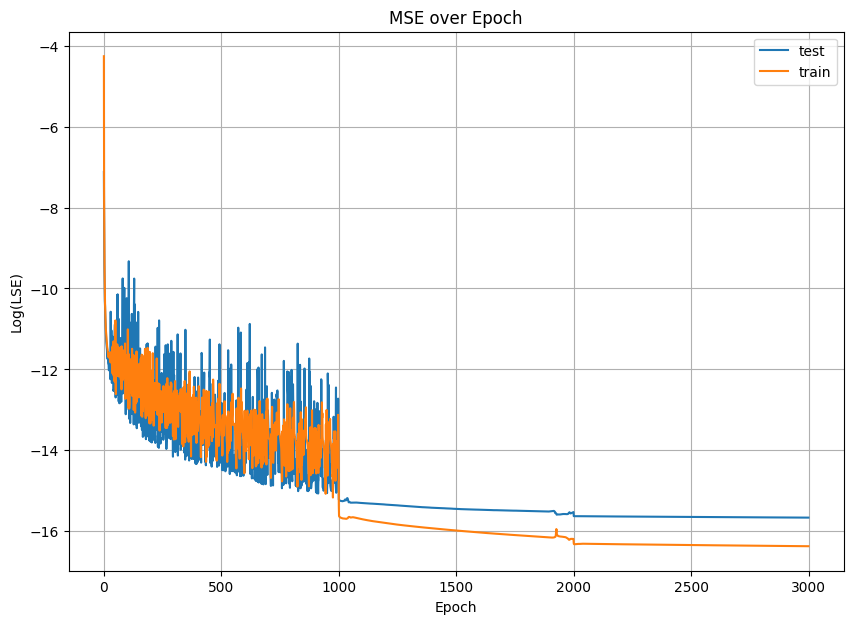

In [48]:
# Plotting log(MSE) as a function of epochs
plt.figure(figsize=(10,7))
plt.plot( np.log(test_losses), label = "test")
plt.plot( np.log(train_losses), label = "train")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Log(LSE)")
plt.title("MSE over Epoch" )
plt.grid()
print("Training WIDE {} VS in the article 8.04e-09".format(train_losses[-1]) )

In [49]:
# Loading model
device = 'cuda'
loaded_Heston_ANN = Heston_ANN().to(device)
PATH = "ANN_weights/Heston_ANN.pt"
loaded_Heston_ANN.load_state_dict(torch.load(PATH))
loaded_Heston_ANN.eval()


Heston_ANN(
  (fc1): Linear(in_features=8, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=400, bias=True)
  (fc5): Linear(in_features=400, out_features=1, bias=True)
)

In [50]:
# Loading Train / Test Data
hs_dataset = Heston_LHS_data_generator(n = 10**5)
train_size, test_size = int(hs_dataset.shape[0]*0.9), int(hs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(hs_dataset, [train_size, hs_dataset.shape[0]-train_size])
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 3*10**3,
         "lr": 1e-4,
         "gamma": .1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}
train_loader = torch.utils.data.DataLoader(train_dataset,args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])

------ INPUT ------
S/K.......... [0.61 1.39]
Tau.......... [0.11 1.39]
r............ [0.01 0.09]
Corr ........ [-0.94 -0.01]
Kappa........ [0.41 1.99]
V_bar........ [0.01 0.49]
Gamma........ [0.01 0.49]
V_0 ......... [0.06 0.49]
------ OUTPUT ------
V/K.......... [0.00 0.64]


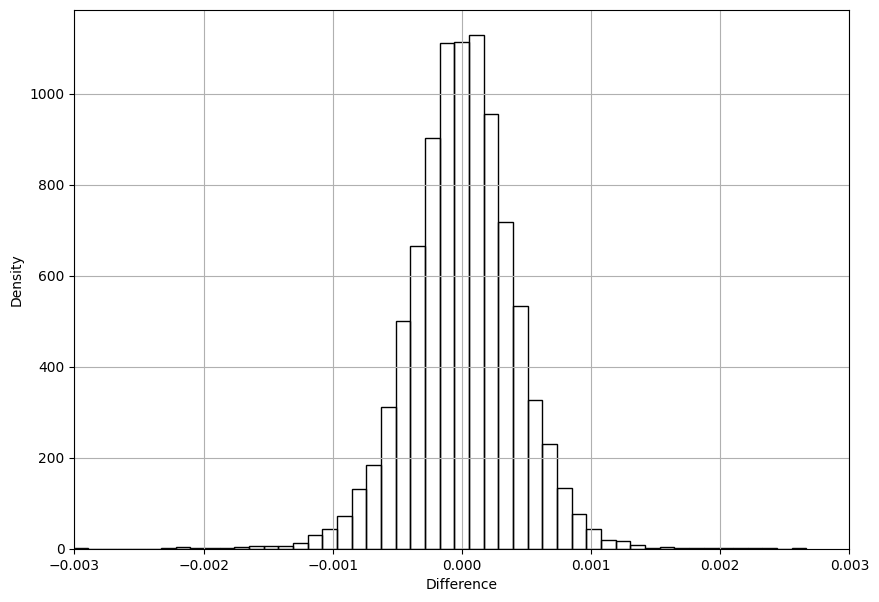

MAX  0.00266546
MIN  -0.0030121505


In [51]:
# Plotting erros histogram
errors = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_ANN(data)
    errors.append((target-output).data.cpu().numpy())
  errors = np.concatenate(errors)
plt.figure(figsize=(10,7))
plt.hist(errors,50,fill=False)
plt.grid()
plt.xlabel("Difference")
plt.ylabel("Density")
plt.xlim([-0.003, 0.003])
plt.show()
print("MAX ",errors.max())
print("MIN ",errors.min())


In [52]:
# printing train and test erros MSE, MAE, MAPE, R2.
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Train scores----------------
MSE 1.620948e-07
MAE 3.069885e-04
MAPE 1.953139e-02
R2 9.999926e-01
-----------Test scores----------------
MSE 1.664916e-07
MAE 3.105019e-04
MAPE 1.748970e-02
R2 9.999923e-01


In [53]:
np.sqrt(1.670718e-07)

0.0004087441742704108

# 5) BRENT

In [54]:
from scipy import optimize

def calcimpliedvol(dataset):
    """
    Computes the implied volatilities using the brent method.
    dataset: numpy array containing moneyness, time to maturity, risk free interest rate and V/K.
    Returns a vector of implied volatilities.
    """
    money = np.array(dataset[0])
    T = np.array(dataset[1])
    r = np.array(dataset[2])
    marketoptionPrice = np.array(dataset[3])
    def bs_price(sigma):
      d1 = ( np.log(money) + (r + 0.5 * sigma ** 2) * (T) ) / (sigma * np.sqrt(T))
      d2 = d1 - sigma*np.sqrt(T)
      value_moyeness = money * norm.cdf(d1) - np.exp(-r * (T)) * norm.cdf(d2) 
      fx = value_moyeness - marketoptionPrice
      return fx
    return optimize.brentq(bs_price,-1,1,maxiter=100)

bs_dataset = bs_LHS_data_generator(n=10**4).data
ground_truth_vol = bs_dataset[:,3]
bs_dataset = bs_dataset[:,np.array([0,1,2,4])]
vol_imp = np.apply_along_axis(calcimpliedvol, 1, bs_dataset)
print("MSE ", ((ground_truth_vol - vol_imp)**2).mean().item())

------ INPUT ------
S/K.......... [0.40 1.60]
Tau.......... [0.20 1.10]
r............ [0.02 0.10]
Sigma........ [0.01 1.00]
------ OUTPUT ------
V/K.......... [0.00 0.85]
MSE  0.00014862391368948422


# 6) Pipeline 1: COS + BRENT

In [55]:
eps = 1e-2 # is used to generate open intervals
# (S/K), (tau), (r), (rho), (kappa), (vbar), (gamma), (v0).
# CASE 1 in table 11
l_bounds = [.75+eps, .4+eps, .0+eps, -0.95+eps, .4+eps, .0+eps, .0+eps, .05+eps]
u_bounds = [1.25-eps, 1.-eps, .1-eps, 0.0-eps, 2.0-eps, .5-eps, .5-eps, .5-eps]
hs_dataset = Heston_LHS_data_generator(10**5, l_bounds = l_bounds, u_bounds=u_bounds)
hs_dataset_data = hs_dataset.data
hs_dataset_data = hs_dataset_data[:,np.array([0,1,2,8])]
implied_vol_pipe1 = np.apply_along_axis(calcimpliedvol, 1, hs_dataset_data)

------ INPUT ------
S/K.......... [0.76 1.24]
Tau.......... [0.41 0.99]
r............ [0.01 0.09]
Corr ........ [-0.94 -0.01]
Kappa........ [0.41 1.99]
V_bar........ [0.01 0.49]
Gamma........ [0.01 0.49]
V_0 ......... [0.06 0.49]
------ OUTPUT ------
V/K.......... [0.00 0.47]


# 7) Pipeline 2: Heston-ANN + IV-ANN

In [56]:
# Loading model
device = torch.device("cuda")
loaded_Heston_ANN = Heston_ANN().to(device)
PATH = "ANN_weights/Heston_ANN.pt"
loaded_Heston_ANN.load_state_dict(torch.load(PATH))
loaded_Heston_ANN.eval()

# data loader 
loader = torch.utils.data.DataLoader(hs_dataset, 4048)
# Computing prices
prices = []
with torch.no_grad():
  for data in loader:
    data, _ = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_ANN(data)
    prices.append((output).data.cpu().numpy())
  prices = np.concatenate(prices)

# Loading model 
device = torch.device("cuda")
loaded_IV_ANN = IV_ANN().to(device)
PATH = "ANN_weights/IV_SCALED_ANN.pt"
loaded_IV_ANN.load_state_dict(torch.load(PATH))
loaded_IV_ANN.eval()


# Plugging in the Heston-ANN prices
hs_dataset2 = hs_dataset.data[:,np.array([0,1,2,8])]
hs_dataset2.data[:,3] = torch.FloatTensor(prices)
loader2 = torch.utils.data.DataLoader(hs_dataset2, 4048)

# Computing IVs
implied_vol = []
indecies_list = []
with torch.no_grad():
  for idx, data in enumerate(loader2):
    data = data.to(device)
    # LOG Transformation
    data[:,3] = data[:,3] - torch.maximum(data[:,0]-torch.exp(-data[:,1]*data[:,2]),torch.zeros(data[:,0].shape).to(device))
    data[:,3] = torch.log(data[:,3])
    output = loaded_IV_ANN(data)
    implied_vol.append((output).data.cpu().numpy())
  implied_vol_pipe2 = np.concatenate(implied_vol)
  # indecies_list = np.concatenate(indecies_list).flatten()


In [57]:
# Eliminating Nan values resulting from prices lower than 1e-7
indecies = np.argwhere(np.isnan(implied_vol_pipe2))
implied_vol_pipe1 = np.delete(implied_vol_pipe1, indecies,0)
implied_vol_pipe2 = np.delete(implied_vol_pipe2, indecies,0)

# 8) Pipeline 1 VS pipeline 2

In [58]:
# CASE 1
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
outputs = implied_vol_pipe2
targets = implied_vol_pipe1
print("-----------Vol scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("RMSE {:e}".format(np.sqrt(mean_squared_error(outputs,targets))) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Vol scores----------------
MSE 2.076680e-06
RMSE 1.441069e-03
MAE 1.114881e-03
MAPE 2.357523e-03
R2 9.997799e-01


In [74]:
# CASE 2
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
outputs = implied_vol_pipe2
targets = implied_vol_pipe1
print("-----------Vol scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("RMSE {:e}".format(np.sqrt(mean_squared_error(outputs,targets))) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Vol scores----------------
MSE 4.065135e-07
RMSE 6.375841e-04
MAE 4.932424e-04
MAPE 1.574925e-03
R2 8.757847e-01


# 9) Volatility surface (COS + IV-ANN)

### Initial volatility surface

In [60]:
# Generating the surface points
r= .02
tau= 0.5
rho = -0.05
kappa= 1.5
vbar = .1
gamma = .3
v0 = 0.1
moyeness = 0.74
moyeness = np.linspace(moyeness, 1.24,11)
tau = np.linspace(tau, 1, 6)

cos_prices = []
X = []
Y = []
for m in moyeness:
  for t in tau:
    X.append(m)
    Y.append(t)
    cos_prices.append(call_option_Heston_moy(N = 160, L= 12, r= r, tau= t, kappa= kappa, gamma = gamma, vbar = vbar, v0 = v0, rho = rho, moyeness = m))

In [61]:
# Reshaping for torch tensor dataset
cos_prices = np.array(cos_prices).reshape((-1, 1))
X = np.array(X).reshape((-1, 1))
Y = np.array(Y).reshape((-1, 1))
r = np.array(r*np.ones(66)).reshape((-1, 1))

In [62]:
# Creating a torch dataset
data = np.concatenate((X, Y, r, cos_prices), axis = 1)
data = torch.FloatTensor(data)

In [63]:
# Getting the implied volatility from the dataset
with torch.no_grad():
  data = data.to(device)
  data[:,3] = data[:,3] - torch.maximum(data[:,0]-torch.exp(-data[:,1]*data[:,2]),torch.zeros(data[:,0].shape).to(device))
  data[:,3] = torch.log(data[:,3])
  output = loaded_IV_ANN(data)
  bs_IV = (output).data.cpu().numpy()

X = X.flatten()
Y = Y.flatten()
Z = bs_IV

x = np.reshape(X, (-1, 6))
y = np.reshape(Y, (-1, 6))
z = np.reshape(Z, (-1, 6))

In [64]:
from mpl_toolkits import mplot3d
from matplotlib import cm

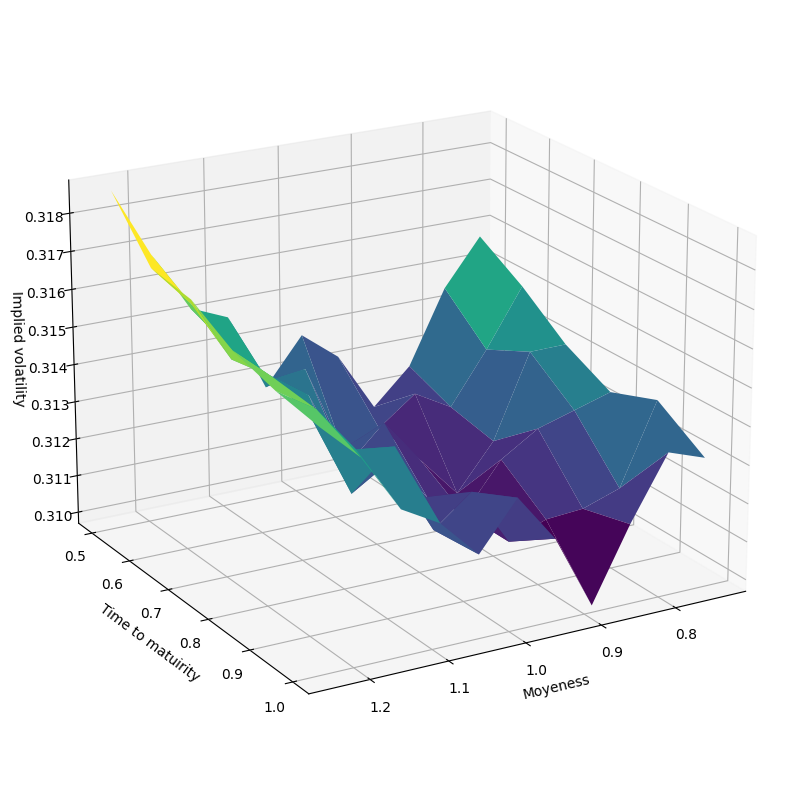

In [65]:
# Plotting the initial volatility surface
plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.view_init(elev=20, azim=60)
ax.plot_surface(x, y, z,cmap='viridis', edgecolor='none', antialiased=True)
ax.set_xlabel('Moyeness')
ax.set_ylabel('Time to matuirity')
ax.set_zlabel('Implied volatility')
plt.show()

### Smoothing the volatility surface

In [66]:
from scipy import interpolate

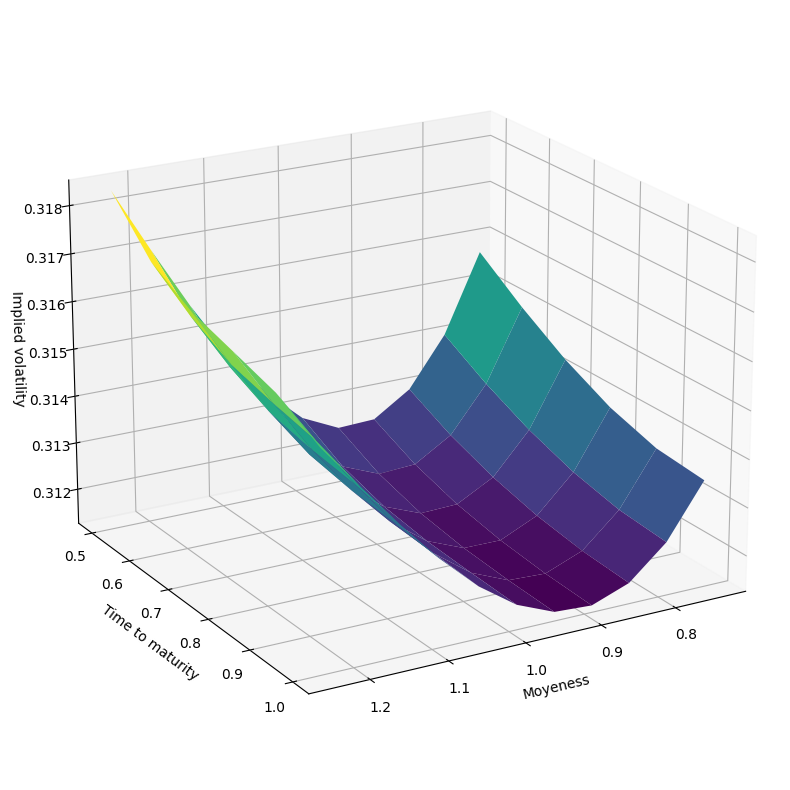

In [67]:
# Smoothing the volatility surface
xnew, ynew = x.copy(), y.copy()
tck = interpolate.bisplrep(x, y, z, s=1.0)
znew = interpolate.bisplev(xnew[:,0], ynew[0,:], tck)

plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.view_init(elev=20, azim=60)
ax.plot_surface(xnew, ynew, znew,cmap='viridis', edgecolor='none', antialiased=True)
ax.set_xlabel('Moyeness')
ax.set_ylabel('Time to maturity')
ax.set_zlabel('Implied volatility')
plt.show()

### Implied volatility difference

In [68]:
# Generating the surface points
r= .02
tau= 0.5
rho = -0.05
kappa= 1.5
vbar = .1
gamma = .3
v0 = 0.1
moyeness = 0.74
n_moneyness = 11
n_tau = 6
moyeness = np.linspace(moyeness, 1.24,n_moneyness)
tau = np.linspace(tau, 1, n_tau)

cos_prices = []
X = []
Y = []
for m in moyeness:
  for t in tau:
    X.append(m)
    Y.append(t)
    cos_prices.append(call_option_Heston_moy(N = 160, L= 12, r= r, tau= t, kappa= kappa, gamma = gamma, vbar = vbar, v0 = v0, rho = rho, moyeness = m))

In [69]:
rho = np.array(rho*np.ones(n_tau * n_moneyness)).reshape((-1, 1))
kappa = np.array(kappa*np.ones(n_tau * n_moneyness)).reshape((-1, 1))
vbar = np.array(vbar*np.ones(n_tau * n_moneyness)).reshape((-1, 1))
gamma = np.array(gamma*np.ones(n_tau * n_moneyness)).reshape((-1, 1))
v0 = np.array(v0*np.ones(n_tau * n_moneyness)).reshape((-1, 1))
# Reshaping for torch tensor dataset
cos_prices = np.array(cos_prices).reshape((-1, 1))
X = np.array(X).reshape((-1, 1))
Y = np.array(Y).reshape((-1, 1))
r = np.array(r*np.ones(n_tau * n_moneyness)).reshape((-1, 1))

In [70]:
data_ann = np.concatenate((X, Y, r, rho, kappa, vbar, gamma, v0, cos_prices), axis = 1)
data_ann = torch.FloatTensor(data_ann)
# Creating a torch dataset
data = np.concatenate((X, Y, r, cos_prices), axis = 1)
data = torch.FloatTensor(data)

In [71]:
implied_vol_pipe1 = np.apply_along_axis(calcimpliedvol, 1, data)

In [72]:
# Getting the implied volatility from the dataset
with torch.no_grad():
  data = data.to(device)
  data[:,3] = data[:,3] - torch.maximum(data[:,0]-torch.exp(-data[:,1]*data[:,2]),torch.zeros(data[:,0].shape).to(device))
  data[:,3] = torch.log(data[:,3])
  output = loaded_IV_ANN(data)
  implied_vol_pipe2 = (output).data.cpu().numpy()



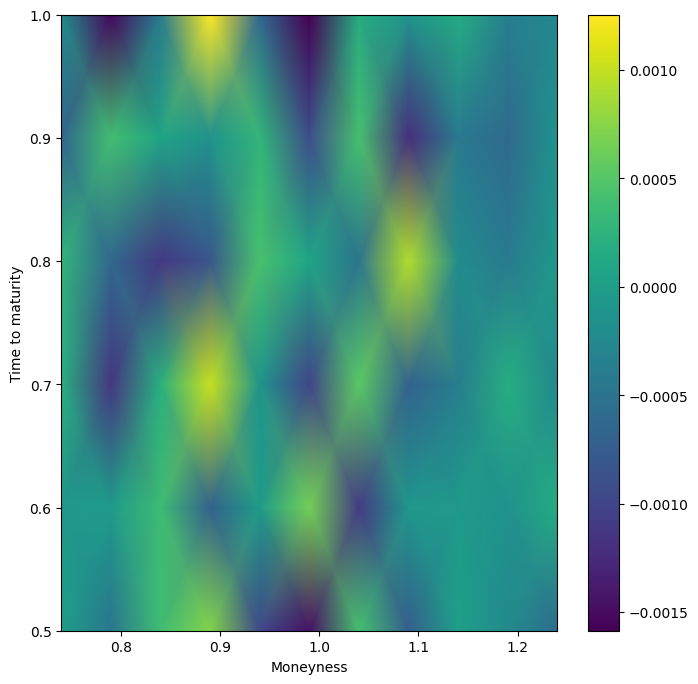

In [73]:
X = X.flatten()
Y = Y.flatten()
Z = (implied_vol_pipe1 - implied_vol_pipe2).flatten()

x = np.reshape(X, (-1, min(n_moneyness, n_tau)))
y = np.reshape(Y, (-1, min(n_moneyness, n_tau)))
z = np.reshape(Z, (-1, min(n_moneyness, n_tau)))

plt.figure(figsize=(8,8))
plt.pcolormesh(x, y, z, shading='gouraud')
plt.colorbar()
plt.xlabel("Moneyness")
plt.ylabel("Time to maturity")
plt.show()